# Part 0: importing libraries and case study data

In [62]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from matplotlib.lines import Line2D
import matplotlib.cm as cm
import matplotlib.colors as mcolors
import matplotlib.patches as mpatches
import os
from pathlib import Path
from matplotlib.patches import Wedge

In [63]:
from enum import Enum

class Market_Gate(Enum):
    DAY_AHEAD = 0
    INTRADAY_1 = 1
    INTRADAY_2 = 2 
    INTRADAY_3 = 3
    CONTINUOUS = 4
    REDISPATCH = 5
    BALANCING = 6
    


In [64]:
# Resolve data folder relative to current working directory
base_dir = Path.cwd()
if (base_dir / "Data").exists():
    data_dir = base_dir / "Data"
elif (base_dir / "Spanish_Power_System" / "Data").exists():
    data_dir = base_dir / "Spanish_Power_System" / "Data"
else:
    data_dir = base_dir / "Data"
print("Current working directory:", base_dir)
print("Using data directory:", data_dir)

# Ensure the figures output directory exists
FIGURES_DIR = Path("plotting/created_figures")
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

# Load CSV data
buses = pd.read_csv(data_dir / "Bus_Data.csv")
lines = pd.read_csv(data_dir / "lines.csv")
loads = pd.read_csv(data_dir / "load.csv")
generation = pd.read_csv(data_dir / "generations.csv")


Current working directory: c:\Users\ehsanno\DataspellProjects
Using data directory: c:\Users\ehsanno\DataspellProjects\Spanish_Power_System\Data


# Part 1: Loading the results



## 8th of July

In [65]:
# Resolve results directory
if (data_dir / "smspp_out").exists():
    smspp_dir = data_dir / "smspp_out"
elif (Path.cwd() / "smspp_out").exists():
    smspp_dir = Path.cwd() / "smspp_out"
else:
    smspp_dir = Path.cwd() / "smspp_out"

# Extracting DA results
active_power_da = pd.read_csv(smspp_dir / "nutsx" / "results_da_ahyd_pomatwo" / "ActivePower" / "ActivePowerOUT.csv")

# Extracting 1st intraday results
active_power_id1 = pd.read_csv(smspp_dir / "nutsx" / "results_id_g1_pomatwo" / "ActivePower" / "ActivePowerOUT.csv")

# Extracting 2nd intraday results
active_power_id2 = pd.read_csv(smspp_dir / "nutsx" / "results_id_g2_pomatwo" / "ActivePower" / "ActivePowerOUT.csv")

# Extracting 3rd intraday results
# In the 3rd gate, only the dispatch of the last 12 hours is changed
active_power_id3 = pd.read_csv(smspp_dir / "nutsx" / "results_ij_12_pomatwo" / "ActivePower" / "ActivePowerOUT.csv")
active_power_C9 = pd.read_csv(smspp_dir / "nutsx" / "results_ij_11_pomatwo" / "ActivePower" / "ActivePowerOUT.csv")
active_power_id3.iloc[:12] = active_power_C9.iloc[:12]

# Extracting balancing
# we assume that the redispatch results for the hour 24 is the balancing results
active_power_balancing = pd.read_csv(smspp_dir / "nutsx" / "results_srdacopf_ij_24" / "ActivePower" / "ActivePowerOUT.csv")


### continuous_market_dispatch

Creating a dataframe that contains the dispatch of the units after closing the continuous trading for each of the 24 hours of the day.

In [66]:
# Base directory where the results are stored
base_dir = smspp_dir / "nutsx"

# Initialize an empty list to hold data for each hour
hourly_data = []

for hour in range(1, 25):  # 1 to 24
    file_path = base_dir / f"results_ij_{hour}_pomatwo" / "ActivePower" / "ActivePowerOUT.csv"

    df = pd.read_csv(file_path)
    df_filtered = df[df["Timestep"] == hour - 1].copy()

    unit_columns = df_filtered.drop(columns=["Timestep"]).columns.tolist()
    unit_data = df_filtered[unit_columns]
    unit_data.insert(0, "Timestep", hour - 1)

    hourly_data.append(unit_data)

# Combine all into a single DataFrame
active_power_continuous = pd.concat(hourly_data, ignore_index=True)


### Redispatch results

To do that the same process as countinious data extraction is needed. Since the balancing results is embeded in the redispatch folders for the previous hours.

In [67]:
# Base directory where the results are stored
base_dir = smspp_dir / "nutsx"

# Initialize an empty list to hold data for each hour
hourly_data = []

for hour in range(1, 25):  # 1 to 24
    file_path = base_dir / f"results_srdacopf_ij_{hour}" / "ActivePower" / "ActivePowerOUT.csv"

    df = pd.read_csv(file_path)
    df_filtered = df[df["Timestep"] == hour - 1].copy()

    unit_columns = df_filtered.drop(columns=["Timestep"]).columns.tolist()
    unit_data = df_filtered[unit_columns]
    unit_data.insert(0, "Timestep", hour - 1)

    hourly_data.append(unit_data)

# Combine all into a single DataFrame
active_power_redispatch = pd.concat(hourly_data, ignore_index=True)


### Dispatch change
The change of the output of the generation units and imports

In [ ]:
active_power_hour_09 = pd.read_csv(smspp_dir / "nutsx/results_ij_9_pomatwo/ActivePower/ActivePowerOUT.csv")

dispatch_change_1id = active_power_id1 - active_power_da;    dispatch_change_1id['Timestep'] = active_power_id1['Timestep']

dispatch_change_2id = active_power_id2 - active_power_id1;    dispatch_change_2id['Timestep'] = active_power_id2['Timestep']

dispatch_change_3id = active_power_id3 - active_power_C9;    dispatch_change_3id['Timestep'] = active_power_id3['Timestep']

dispatch_change_continuous = active_power_continuous - active_power_id3
dispatch_change_continuous.iloc[:12] = active_power_continuous.iloc[:12] - active_power_id2.iloc[:12];     dispatch_change_continuous['Timestep'] = active_power_continuous['Timestep']

dispatch_change_redispatch = active_power_redispatch - active_power_continuous;     dispatch_change_redispatch['Timestep'] = active_power_continuous['Timestep']

dispatch_change_balancing = active_power_balancing - active_power_redispatch;    dispatch_change_balancing['Timestep'] = active_power_balancing['Timestep']


C:\Users\ehsanno\AppData\Local\Temp\ipykernel_26264\4134194625.py:10: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[ 0.          0.          0.          0.          0.          0.
  0.          0.          0.         48.58660508  0.          0.        ]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  dispatch_change_continuous.iloc[:12] = active_power_continuous.iloc[:12] - active_power_id2.iloc[:12];     dispatch_change_continuous['Timestep'] = active_power_continuous['Timestep']


: 

### Load 

In [68]:
load_da = pd.read_csv(smspp_dir / "nutsx" / "results_da_pomatwo" / "Demand" / "DemandOUT.csv")
load_id1 = pd.read_csv(smspp_dir / "nutsx" / "results_id_g1_pomatwo" / "Demand" / "DemandOUT.csv")
load_id2 = pd.read_csv(smspp_dir / "nutsx" / "results_id_g2_pomatwo" / "Demand" / "DemandOUT.csv")

load_id3 = pd.read_csv(smspp_dir / "nutsx" / "results_ij_12_pomatwo" / "Demand" / "DemandOUT.csv")
load_C9  = pd.read_csv(smspp_dir / "nutsx" / "results_ij_11_pomatwo" / "Demand" / "DemandOUT.csv")
load_id3.iloc[:12] = load_C9.iloc[:12]

# Extracting balancing
# we assume that the redispatch results for hour 24 are the balancing results
load_balancing = pd.read_csv(smspp_dir / "nutsx" / "results_srdacopf_ij_24" / "Demand" / "DemandOUT.csv")

# Market (continuous) load — one row per hour from the corresponding hourly result folder
base_dir = smspp_dir / "nutsx"
hourly_data = []
for hour in range(1, 25):  # 1 to 24
    file_path = base_dir / f"results_ij_{hour}_pomatwo" / "Demand" / "DemandOUT.csv"
    df = pd.read_csv(file_path)
    hourly_data.append(df[df['Timestep'] == hour - 1].copy())
load_continuous_market = pd.concat(hourly_data, ignore_index=True)

# Snapshot loads for hour 1 (used elsewhere in the notebook)
active_power_C1 = pd.read_csv(smspp_dir / "nutsx" / "results_ij_1_pomatwo" / "ActivePower" / "ActivePowerOUT.csv")
load_C1         = pd.read_csv(smspp_dir / "nutsx" / "results_ij_1_pomatwo" / "Demand" / "DemandOUT.csv")
active_power_R1 = pd.read_csv(smspp_dir / "nutsx" / "results_srdacopf_ij_1" / "ActivePower" / "ActivePowerOUT.csv")
load_R1         = pd.read_csv(smspp_dir / "nutsx" / "results_srdacopf_ij_1" / "Demand" / "DemandOUT.csv")

# Redispatch load — one row per hour from the corresponding hourly redispatch folder
hourly_data = []
for hour in range(1, 25):  # 1 to 24
    file_path = base_dir / f"results_srdacopf_ij_{hour}" / "Demand" / "DemandOUT.csv"
    df = pd.read_csv(file_path)
    df_filtered = df[df['Timestep'] == hour - 1].copy()
    unit_columns = df_filtered.drop(columns=['Timestep']).columns.tolist()
    unit_data = df_filtered[unit_columns]
    unit_data.insert(0, 'Timestep', hour - 1)
    hourly_data.append(unit_data)
load_redispatch = pd.concat(hourly_data, ignore_index=True)


### Difference between load and generation at each stage

In [69]:
dif_da = active_power_da.drop(columns='Timestep').sum(axis=1) - load_da.drop(columns='Timestep').sum(axis=1)

# Plotting the dispatch change across stages for ther 1st intraday gate
dif_1id = active_power_id1.drop(columns='Timestep').sum(axis=1) - load_id1.drop(columns='Timestep').sum(axis=1)

# 2nd intraday gate
dif_2id = active_power_id2.drop(columns='Timestep').sum(axis=1) - load_id2.drop(columns='Timestep').sum(axis=1)

# 3rd intraday gate
dif_3id = active_power_id3.drop(columns='Timestep').sum(axis=1) - load_id3.drop(columns='Timestep').sum(axis=1)

# continuous intraday
dif_continuous = active_power_continuous.drop(columns='Timestep').sum(axis=1) - load_continuous_market.drop(columns='Timestep').sum(axis=1)

# redispatch
dif_redispatch = active_power_redispatch.drop(columns='Timestep').sum(axis=1) - load_redispatch.drop(columns='Timestep').sum(axis=1)

# balancing
dif_balancing = active_power_balancing.drop(columns='Timestep').sum(axis=1) - load_balancing.drop(columns='Timestep').sum(axis=1)


### Load change at each stage

In [70]:
# load change per stage
load_change_1id = load_id1 - load_da;    load_change_1id['Timestep'] = load_id1['Timestep']
load_change_2id = load_id2 - load_id1;    load_change_2id['Timestep'] = load_id2['Timestep']
load_change_3id = load_id3 - load_C9;    load_change_3id['Timestep'] = load_id3['Timestep']
load_change_continuous = load_continuous_market - load_id3
load_change_continuous.iloc[:12] = load_continuous_market.iloc[:12] - load_id2.iloc[:12];     load_change_continuous['Timestep'] = load_continuous_market['Timestep']

# Create a DataFrame with total load per hour for redispatch
load_redispatch_total_df = pd.DataFrame({
    'Timestep': load_redispatch['Timestep'],
    'Node_0': load_redispatch.drop(columns='Timestep').sum(axis=1)
})


load_change_redispatch = load_redispatch_total_df.drop(columns='Timestep') - load_continuous_market.drop(columns='Timestep')
load_change_redispatch = pd.DataFrame({
    'Timestep': load_redispatch_total_df['Timestep'],
    'Node_0': load_change_redispatch.sum(axis=1)
})

load_change_balancing = load_balancing - load_redispatch;    load_change_balancing['Timestep'] = load_balancing['Timestep']

### Distributing load through the Grid

In [71]:
import pandas as pd

def create_demandout_df(hourly_total_demand: pd.DataFrame) -> pd.DataFrame:
    """
    Constructs a DataFrame matching the structure of DemandOUT.csv by multiplying
    bus demand shares with hourly total system demand.

    Parameters:
    - hourly_total_demand: DataFrame with 'Timestep' and 'Node_0' columns

    Returns:
    - demand_out_df: DataFrame with columns ['Timestep', <bus IDs>], one row per hour
    """
    # Load bus shares
    bus_share_df = pd.read_csv(data_dir / 'load.csv')
    bus_share_df.set_index("busID", inplace=True)

    # Ensure 'Timestep' is index
    hourly_total_demand = hourly_total_demand.set_index("Timestep")

    # Multiply each row of total demand with the bus share Series
    demand_out_df = pd.DataFrame(
        [bus_share_df["demand"] * total for total in hourly_total_demand["Node_0"]],
        index=hourly_total_demand.index
    )

    # Format final DataFrame
    demand_out_df.columns = bus_share_df.index
    demand_out_df.reset_index(inplace=True)

    return demand_out_df


### Aggregated generatoin per technology

In [72]:

def generation_by_technology(active_power_df, generation):
    """ 
    Create a DataFrame with generation by technology from active power data.
    """
    unit_columns = [col for col in active_power_df.columns if col.startswith("G")]
    active_power_units = active_power_df[["Timestep"] + unit_columns]

    # Melt the generation data to long format
    melted = active_power_units.melt(id_vars="Timestep", var_name="unit_id", value_name="generation_mw")

    # Merge with technology info
    merged = melted.merge(generation[["unit_id", "technology"]], on="unit_id", how="left")

    # Group by timestep and technology, sum the generation
    gen_by_tech = merged.groupby(["Timestep", "technology"])["generation_mw"].sum().reset_index()

    # Pivot to have technology as columns (optional, for plotting convenience)
    return gen_by_tech.pivot(index="Timestep", columns="technology", values="generation_mw").fillna(0)

gen_per_tech = generation_by_technology(active_power_da,generation)

## 2nd of December

In [73]:
import pandas as pd

# Extracting DA results
active_power_da_d2 = pd.read_csv(smspp_dir / "nutsx/results_d2_da_ahyd_pomatwo/ActivePower/ActivePowerOUT.csv")

# Extracting 1st intraday results
active_power_id1_d2 = pd.read_csv(smspp_dir / "nutsx/results_id_d2_g1_pomatwo/ActivePower/ActivePowerOUT.csv")

# Extracting 2nd intraday results
active_power_id2_d2 = pd.read_csv(smspp_dir / "nutsx/results_id_d2_g2_pomatwo/ActivePower/ActivePowerOUT.csv")

# Extracting 3rd intraday results
# In the 3rd gate, only the dispatch of the last 12 hours is changed
active_power_id3_d2 = pd.read_csv(smspp_dir / "nutsx/results_ij_d2_12_pomatwo/ActivePower/ActivePowerOUT.csv")
active_power_C9_d2 = pd.read_csv(smspp_dir / "nutsx/results_ij_d2_11_pomatwo/ActivePower/ActivePowerOUT.csv")
active_power_id3_d2.iloc[:12] = active_power_C9_d2.iloc[:12]

# Extracting balancign
# we assume that the redispatch results fot the hour 24 is the balancing results
active_power_balancing_d2 = pd.read_csv(smspp_dir / "nutsx/results_srdacopf_ij_d2_24/ActivePower/ActivePowerOUT.csv")

C:\Users\ehsanno\AppData\Local\Temp\ipykernel_26264\2431633031.py:16: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[379.          58.96949      0.           0.           0.
   0.         371.94081449 283.75635751 379.         379.
 379.         379.        ]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  active_power_id3_d2.iloc[:12] = active_power_C9_d2.iloc[:12]


###

### Continuous market

In [74]:
# Base directory where the results are stored
base_dir = smspp_dir / "nutsx"

# Initialize an empty list to hold data for each hour
hourly_data = []

for hour in range(1, 25):  # 1 to 24
    file_path = base_dir / f"results_ij_d2_{hour}_pomatwo" / "ActivePower" / "ActivePowerOUT.csv"

    df = pd.read_csv(file_path)
    df_filtered = df[df['Timestep'] == hour - 1].copy()

    unit_columns = df_filtered.drop(columns=['Timestep']).columns.tolist()
    unit_data = df_filtered[unit_columns]
    unit_data.insert(0, 'Timestep', hour - 1)

    hourly_data.append(unit_data)

# Combine all into a single DataFrame
active_power_continuous_d2 = pd.concat(hourly_data, ignore_index=True)


### Redispatch

In [75]:
# Base directory where the results are stored
base_dir = smspp_dir / "nutsx"

# Initialize an empty list to hold data for each hour
hourly_data = []

for hour in range(1, 25):  # 1 to 24
    file_path = base_dir / f"results_srdacopf_ij_d2_{hour}" / "ActivePower" / "ActivePowerOUT.csv"

    df = pd.read_csv(file_path)
    df_filtered = df[df['Timestep'] == hour - 1].copy()

    unit_columns = df_filtered.drop(columns=['Timestep']).columns.tolist()
    unit_data = df_filtered[unit_columns]
    unit_data.insert(0, 'Timestep', hour - 1)

    hourly_data.append(unit_data)

# Combine all into a single DataFrame
active_power_redispatch_d2 = pd.concat(hourly_data, ignore_index=True)


### Dispatch Changes

In [76]:
active_power_hour_09_d2 = pd.read_csv(smspp_dir / "nutsx/results_ij_9_pomatwo/ActivePower/ActivePowerOUT.csv")

dispatch_change_1id_d2 = active_power_id1_d2 - active_power_da_d2;    dispatch_change_1id_d2['Timestep'] = active_power_id1_d2['Timestep']
dispatch_change_2id_d2 = active_power_id2_d2 - active_power_id1_d2;    dispatch_change_2id_d2['Timestep'] = active_power_id2_d2['Timestep']
dispatch_change_3id_d2 = active_power_id3_d2 - active_power_C9_d2;    dispatch_change_3id_d2['Timestep'] = active_power_id3_d2['Timestep']
dispatch_change_continuous_d2 = active_power_continuous_d2 - active_power_id3_d2
dispatch_change_continuous_d2.iloc[:12] = active_power_continuous_d2.iloc[:12] - active_power_id2_d2.iloc[:12];     dispatch_change_continuous_d2['Timestep'] = active_power_continuous_d2['Timestep']
dispatch_change_redispatch_d2 = active_power_redispatch_d2 - active_power_continuous_d2;     dispatch_change_redispatch_d2['Timestep'] = active_power_id3_d2['Timestep']
dispatch_change_balancing_d2 = active_power_balancing_d2 - active_power_redispatch_d2;    dispatch_change_balancing_d2['Timestep'] = active_power_balancing_d2['Timestep']

### Load

In [77]:
load_da_d2 = pd.read_csv(smspp_dir / "nutsx" / "results_d2_da_pomatwo" / "Demand" / "DemandOUT.csv")
load_id1_d2 = pd.read_csv(smspp_dir / "nutsx" / "results_id_d2_g1_pomatwo" / "Demand" / "DemandOUT.csv")
load_id2_d2 = pd.read_csv(smspp_dir / "nutsx" / "results_id_d2_g2_pomatwo" / "Demand" / "DemandOUT.csv")

load_id3_d2 = pd.read_csv(smspp_dir / "nutsx" / "results_ij_d2_12_pomatwo" / "Demand" / "DemandOUT.csv")
load_C9_d2  = pd.read_csv(smspp_dir / "nutsx" / "results_ij_d2_11_pomatwo" / "Demand" / "DemandOUT.csv")
load_id3_d2.iloc[:12] = load_C9_d2.iloc[:12]

# Extracting balancing
# we assume that the redispatch results for hour 24 are the balancing results
load_balancing_d2 = pd.read_csv(smspp_dir / "nutsx" / "results_srdacopf_ij_d2_24" / "Demand" / "DemandOUT.csv")

# Market (continuous) load — one row per hour from the corresponding hourly result folder
base_dir = smspp_dir / "nutsx"
hourly_data = []
for hour in range(1, 25):  # 1 to 24
    file_path = base_dir / f"results_ij_d2_{hour}_pomatwo" / "Demand" / "DemandOUT.csv"
    df = pd.read_csv(file_path)
    hourly_data.append(df[df['Timestep'] == hour - 1].copy())
load_continuous_market_d2 = pd.concat(hourly_data, ignore_index=True)

# Snapshot loads for hour 1 (used elsewhere in the notebook)
active_power_C1_d2 = pd.read_csv(smspp_dir / "nutsx" / "results_ij_d2_1_pomatwo" / "ActivePower" / "ActivePowerOUT.csv")
load_C1_d2         = pd.read_csv(smspp_dir / "nutsx" / "results_ij_d2_1_pomatwo" / "Demand" / "DemandOUT.csv")
active_power_R1_d2 = pd.read_csv(smspp_dir / "nutsx" / "results_srdacopf_ij_d2_1" / "ActivePower" / "ActivePowerOUT.csv")
load_R1_d2         = pd.read_csv(smspp_dir / "nutsx" / "results_srdacopf_ij_d2_1" / "Demand" / "DemandOUT.csv")

# Redispatch load — one row per hour from the corresponding hourly redispatch folder
hourly_data = []
for hour in range(1, 25):  # 1 to 24
    file_path = base_dir / f"results_srdacopf_ij_d2_{hour}" / "Demand" / "DemandOUT.csv"
    df = pd.read_csv(file_path)
    df_filtered = df[df['Timestep'] == hour - 1].copy()
    unit_columns = df_filtered.drop(columns=['Timestep']).columns.tolist()
    unit_data = df_filtered[unit_columns]
    unit_data.insert(0, 'Timestep', hour - 1)
    hourly_data.append(unit_data)
load_redispatch_d2 = pd.concat(hourly_data, ignore_index=True)


### Difference between load and generation at each stage

In [78]:
dif_da_d2 = active_power_da_d2.drop(columns='Timestep').sum(axis=1) - load_da_d2.drop(columns='Timestep').sum(axis=1)

# Plotting the dispatch change across stages for ther 1st intraday gate
dif_1id_d2 = active_power_id1_d2.drop(columns='Timestep').sum(axis=1) - load_id1_d2.drop(columns='Timestep').sum(axis=1)

# 2nd intraday gate
dif_2id_d2 = active_power_id2_d2.drop(columns='Timestep').sum(axis=1) - load_id2_d2.drop(columns='Timestep').sum(axis=1)

# 3rd intraday gate
dif_3id_d2 = active_power_id3_d2.drop(columns='Timestep').sum(axis=1) - load_id3_d2.drop(columns='Timestep').sum(axis=1)

# continuous intraday
dif_continuous_d2 = active_power_continuous_d2.drop(columns='Timestep').sum(axis=1) - load_continuous_market_d2.drop(columns='Timestep').sum(axis=1)

# redispatch
dif_redispatch_d2 = active_power_redispatch_d2.drop(columns='Timestep').sum(axis=1) - load_redispatch_d2.drop(columns='Timestep').sum(axis=1)

# balancing
dif_balancing_d2 = active_power_balancing_d2.drop(columns='Timestep').sum(axis=1) - load_balancing_d2.drop(columns='Timestep').sum(axis=1)


### Load change at each stage

In [79]:
# load change per stage
load_change_1id_d2 = load_id1_d2 - load_da_d2;    load_change_1id_d2['Timestep'] = load_id1_d2['Timestep']
load_change_2id_d2 = load_id2_d2 - load_id1_d2;    load_change_2id_d2['Timestep'] = load_id2_d2['Timestep']
load_change_3id_d2 = load_id3_d2 - load_C9_d2;    load_change_3id_d2['Timestep'] = load_id3_d2['Timestep']
load_change_continuous_d2 = load_continuous_market_d2 - load_id3_d2
load_change_continuous_d2.iloc[:12] = load_continuous_market_d2.iloc[:12] - load_id2_d2.iloc[:12];     load_change_continuous_d2['Timestep'] = load_continuous_market_d2['Timestep']

# Create a DataFrame with total load per hour for redispatch
load_redispatch_total_df_d2 = pd.DataFrame({
    'Timestep': load_redispatch_d2['Timestep'],
    'Node_0': load_redispatch_d2.drop(columns='Timestep').sum(axis=1)
})


load_change_redispatch_d2 = load_redispatch_total_df_d2.drop(columns='Timestep') - load_continuous_market_d2.drop(columns='Timestep')
load_change_redispatch_d2 = pd.DataFrame({
    'Timestep': load_redispatch_total_df_d2['Timestep'],
    'Node_0': load_change_redispatch_d2.sum(axis=1)
})

load_change_balancing_d2 = load_balancing_d2 - load_redispatch_d2;    load_change_balancing_d2['Timestep'] = load_balancing_d2['Timestep']

### Aggregated generatoin per technology

In [80]:
gen_per_tech_d2 = generation_by_technology(active_power_da_d2,generation)

# Part 2: Defining Plotting functions



## Interactive map

In [81]:
"""
Plot an interactive power flow map using folium.

This function visualizes the power grid by plotting buses and transmission lines on an interactive map.
It displays line utilization, power flows, and optionally generation and load at each bus. The map is
color-coded to show line utilization and allows for interactive exploration of the network.

Parameters
----------
unit_generation_total : pandas.DataFrame, optional
    DataFrame with columns ['unit_id', 'actual_gen_mwh'] representing generation per unit.
flows_out : pandas.DataFrame, optional
    DataFrame with columns for each line (prefixed with 'L') and rows for each hour, representing power flows.
bus_demand : pandas.DataFrame, optional
    DataFrame with demand per bus, can be time series or single snapshot.
plot_load : bool, default False
    Whether to plot load at each bus.
plot_generation : bool, default False
    Whether to plot generation at each bus.
min_utilization_pct : float, default 0.0
    Minimum line utilization percentage to display.
hour : int, optional
    Hour index to plot (if time series data is provided).
max_capacity_pct : float, default 100
    Maximum percentage of line capacity to use for scaling.
save_path : str, default 'power_flow_map.html'
    Path to save the generated HTML map.
save : bool, default False
    Whether to save the map to file.
cos_phi : float, default 1
    Power factor for capacity calculation.

Returns
-------
None
    Opens the generated map in a web browser and optionally saves it to an HTML file.
"""

import pandas as pd
import numpy as np
import folium
from folium import Popup
from branca.colormap import linear, StepColormap
import webbrowser
import os

def plot_power_flow_interactive(unit_generation_total=None, flows_out=None, bus_demand=None,
                                plot_load=False, plot_generation=False,
                                min_utilization_pct=0.0, hour=None,
                                max_capacity_pct=100, save_path='power_flow_map.html', save=False, cos_phi=1,
                                pu_flag=0, base_power_mw=100):

    # Load input data
    buses = pd.read_csv(data_dir / 'Bus_Data.csv')
    lines = pd.read_csv(data_dir / 'lines.csv')
    loads = pd.read_csv(data_dir / 'load.csv')
    generation = pd.read_csv(data_dir / 'generations.csv')

    # Normalize coordinates in Bus_Data
    if 'Longitude' in buses.columns and 'Latitude' in buses.columns:
        buses.rename(columns={'Longitude': 'x', 'Latitude': 'y'}, inplace=True)
    buses['coord_key'] = list(zip(buses['x'], buses['y']))
    coord_groups = buses.groupby('coord_key')['bus_id'].apply(list)

    # Merge generation if required
    if plot_generation and unit_generation_total is not None:
        unit_bus_mapping = generation[['unit_id', 'bus_id']]
        unit_generation_total = unit_generation_total.merge(unit_bus_mapping, on='unit_id')
        unit_generation_total_grouped = unit_generation_total.groupby('bus_id')['actual_gen_mwh'].sum()

        gen_dict = {}
        for group in coord_groups:
            representative = group[0]
            gen_dict[representative] = sum(unit_generation_total_grouped.get(bus, 0) for bus in group)

        buses['actual_gen_mwh'] = buses['bus_id'].map(gen_dict).fillna(0)
    else:
        buses['actual_gen_mwh'] = 0

    # Merge demand if required
    if plot_load and bus_demand is not None:
        if 'Timestep' in bus_demand.columns:
            # Full DemandOUT DataFrame
            if hour is not None and 0 <= hour < 24:
                demand_row = bus_demand.iloc[hour].drop('Timestep')
            else:
                demand_row = bus_demand.drop(columns='Timestep').mean()
        else:
            # Already a pre-processed single-hour DataFrame
            demand_row = bus_demand.set_index('bus_id')['demand']

        demand_dict = {}
        for group in coord_groups:
            representative = group[0]
            demand_dict[representative] = sum(demand_row.get(bus, 0) for bus in group)

        buses['demand'] = buses['bus_id'].map(demand_dict).fillna(0)
    else:
        buses['demand'] = 0

    # Compute net injection
    buses['injection_mwh'] = buses['actual_gen_mwh'] - buses['demand']

    # Prepare flow data
    flows_out = flows_out.loc[:, flows_out.columns.str.startswith('L')]
    flows_out.columns = flows_out.columns.str[1:]
    flow_scale = base_power_mw if pu_flag == 1 else 1.0
    flows_out = flows_out * flow_scale

    common_lines = set(flows_out.columns).intersection(set(lines['line_id']))
    lines_filtered = lines[lines['line_id'].isin(common_lines)].copy()
    flows_out_filtered = flows_out[list(common_lines)].copy()

    # Select hour or average
    if hour is not None:
        if isinstance(hour, int) and 0 <= hour < flows_out_filtered.shape[0]:
            selected_flow = flows_out_filtered.iloc[hour].abs()
            lines_filtered['flow_mw'] = lines_filtered['line_id'].map(selected_flow)
        else:
            raise ValueError(f"Invalid hour: {hour}")
    else:
        avg_flow = flows_out_filtered.abs().mean()
        lines_filtered['flow_mw'] = lines_filtered['line_id'].map(avg_flow)

    # Compute adjusted capacity
    lines_filtered['thermal_capacity'] = (
        lines_filtered['voltage'] * 
        lines_filtered['Imax'] * 
        np.sqrt(3) * 
        # lines_filtered['circuits'] * 
        cos_phi)

    lines_filtered['adjusted_capacity'] = lines_filtered['thermal_capacity'] * (max_capacity_pct / 100)
    lines_filtered['utilization_pct'] = 100 * lines_filtered['flow_mw'] / lines_filtered['adjusted_capacity']
    lines_filtered = lines_filtered[lines_filtered['utilization_pct'] >= min_utilization_pct]

    # Set up color map
    colormap = StepColormap(
        colors=list(linear.RdYlGn_11.colors)[::-1],
        index=[0,10,20,30,40,50,60,70,80,90,100],
        vmin=0,
        vmax=100,
        caption='Line Utilization (%)'
    )

    # Create base folium map centered around average bus location
    center_lat = buses['y'].mean()
    center_lon = buses['x'].mean()
    m = folium.Map(location=[center_lat, center_lon], zoom_start=6, tiles='cartodb positron')

    min_width, max_width = 0.5, 5
    flow_min, flow_max = lines_filtered['flow_mw'].min(), lines_filtered['flow_mw'].max()

    # Add lines
    for _, row in lines_filtered.iterrows():
        bus0 = buses[buses['bus_id'] == row['bus0']].iloc[0]
        bus1 = buses[buses['bus_id'] == row['bus1']].iloc[0]

        coords = [(bus0['y'], bus0['x']), (bus1['y'], bus1['x'])]
        utilization = min(100, row['utilization_pct'])
        line_color = colormap(utilization)
        line_weight = min_width + (max_width - min_width) * ((row['flow_mw'] - flow_min) / (flow_max - flow_min))

        popup_content = f"""<b>Line ID:</b> {row['line_id']}<br>
                            <b>Flow:</b> {row['flow_mw']:.1f} MW<br>
                            <b>Capacity:</b> {row['adjusted_capacity']:.1f} MW<br>
                            <b>Utilization:</b> {utilization:.1f}%"""

        folium.PolyLine(locations=coords,
                        color=line_color,
                        weight=line_weight*1.5,
                        popup=Popup(popup_content, max_width=300)).add_to(m)

    # Add buses
    injection_threshold = 1e-2
    max_injection = buses['injection_mwh'].abs().max()

    for _, row in buses.iterrows():
        injection = row['injection_mwh']
        if abs(injection) < injection_threshold or max_injection == 0:
            size = 1
            color = 'dimgray'
            weight = 1.3
            popup_text = f"Bus ID: {row['bus_id']}<br>Injection: {injection:.4f} MWh"
        else:
            size = 3 + 20 * abs(injection) / max_injection
            color = 'blue' if injection >= 0 else 'orange'
            weight = 2
            popup_text = f"Bus ID: {row['bus_id']}<br>Injection: {injection:.1f} MWh"

        folium.CircleMarker(
            location=[row['y'], row['x']],
            radius=size,
            color=color,
            fill=True,
            fill_opacity=0.7,
            popup=popup_text,
            weight=weight
        ).add_to(m)

    # Add legend
    colormap.caption = 'Line Utilization (%)'
    m.add_child(colormap)

    if not save:
        save_path = 'power_flow_map.html'

    m.save(save_path)
    webbrowser.open('file://' + os.path.realpath(save_path))
    print(f"Interactive map saved to: {save_path}")


## Map showing the flow

In [82]:
def plot_power_flow(unit_generation_total=None, flows_out=None, bus_demand=None,
                    plot_high=True, plot_medium=True, plot_low=True,
                    plot_load=False, plot_generation=False,
                    min_utilization_pct=0.0, hour=0, save=False,
                    max_capacity_pct=100, cos_phi = 1, pu_flag=0, base_power_mw=100):
    buses = pd.read_csv(data_dir / 'Bus_Data.csv')
    lines = pd.read_csv(data_dir / 'lines.csv')
    loads = pd.read_csv(data_dir / 'load.csv')
    generation = pd.read_csv(data_dir / 'generations.csv')

    voltage_levels = {
        '380 kV': 380,
        '220 kV': 200,
        '130 kV': 130
    }

    entsoe_voltage_colors = {
        '380 kV': 'tab:blue',
        '220 kV': 'tab:orange',
        'low': 'tab:green',
        'outside': 'tab:purple'
    }

    # Map actual generation to bus ids if generation plotting is requested
    if plot_generation and unit_generation_total is not None:
        unit_bus_mapping = generation[['unit_id', 'bus_id']]
        unit_generation_total = unit_generation_total.merge(unit_bus_mapping, on='unit_id')
        bus_actual_generation = unit_generation_total.groupby('bus_id')['actual_gen_mwh'].sum().reset_index()
        buses = buses.merge(bus_actual_generation, on='bus_id', how='left').fillna(0)
    else:
        buses['actual_gen_mwh'] = 0

    # Merge demand if load plotting is requested
    if plot_load and bus_demand is not None:
        buses = buses.merge(bus_demand, on='bus_id', how='left').fillna(0)
    else:
        buses['demand'] = 0
        print("No load data provided, using zero demand for all buses.")

    # Calculate net injection: generation - demand
    buses['injection_mwh'] = buses['actual_gen_mwh'] - buses['demand']

    # Process flows
    flows_out = flows_out.loc[:, flows_out.columns.str.startswith('L')]
    flows_out.columns = flows_out.columns.str[1:]
    flow_scale = base_power_mw if pu_flag == 1 else 1.0
    flows_out = flows_out * flow_scale

    common_lines = set(flows_out.columns).intersection(set(lines['line_id']))
    lines_filtered = lines[lines['line_id'].isin(common_lines)].copy()
    flows_out_filtered = flows_out[list(common_lines)].copy()

    if hour != -1:
        if isinstance(hour, int) and 0 <= hour < flows_out_filtered.shape[0]:
            selected_flow = flows_out_filtered.iloc[hour].abs()
            lines_filtered['flow_mw'] = lines_filtered['line_id'].map(selected_flow)
        else:
            raise ValueError(f"Invalid hour: {hour}. Must be between 0 and {flows_out_filtered.shape[0]-1}")
    else:
        avg_flow = flows_out_filtered.abs().mean()
        lines_filtered['flow_mw'] = lines_filtered['line_id'].map(avg_flow)

    # Calculate thermal capacity
    # Calculate thermal capacity
    lines_filtered['thermal_capacity'] = (
    lines_filtered['voltage'] * 
    lines_filtered['Imax'] * 
    np.sqrt(3) * 
    # lines_filtered['circuits'] *      # Commented since the circuits nimbers have been taken into account in the Imax of the lines_merged_all_voltages.csv file
    cos_phi)
    
    # Apply max usable capacity percentage (e.g., N-1 reserve)
    lines_filtered['adjusted_capacity'] = lines_filtered['thermal_capacity'] * (max_capacity_pct / 100)
    

    # Compute utilization based on adjusted capacity
    lines_filtered['utilization_pct'] = (lines_filtered['flow_mw'] / lines_filtered['adjusted_capacity']) * 100

    # Filter by min utilization percentage
    lines_filtered = lines_filtered[lines_filtered['utilization_pct'] >= min_utilization_pct]

    # Set up color gradient based on utilization
    norm = mcolors.Normalize(vmin=0, vmax=100)
    cmap = plt.get_cmap('RdYlGn_r')

    fig, ax = plt.subplots(figsize=(20, 30), subplot_kw={'projection': ccrs.PlateCarree()})
    fig.patch.set_alpha(0)
    ax.add_feature(cfeature.LAND, edgecolor='black', facecolor='whitesmoke')
    ax.add_feature(cfeature.COASTLINE)
    ax.add_feature(cfeature.BORDERS, linestyle=':', edgecolor='gray')
    ax.coastlines(resolution='10m', color='gray', linewidth=0.01)
    ax.set_facecolor('none')
    ax.set_extent([-10, 5, 35, 45], crs=ccrs.PlateCarree())


    # Normalize linewidths
    min_width, max_width = 0.5, 5
    flow_min, flow_max = lines_filtered['flow_mw'].min(), lines_filtered['flow_mw'].max()

    for _, line in lines_filtered.iterrows():
        bus0 = buses[buses['bus_id'] == line['bus0']]
        bus1 = buses[buses['bus_id'] == line['bus1']]

        flow_color = cmap(norm(line['utilization_pct']+0.02))  # +0.01 to avoid zero color
        linestyle = '-' if line['dc'] == 'f' else '--'
        linewidth = min_width + (max_width - min_width) * ((line['flow_mw']) / (flow_max))

        ax.plot([bus0["x"].values[0], bus1["x"].values[0]],
                [bus0["y"].values[0], bus1["y"].values[0]],
                color=flow_color, linewidth=linewidth, linestyle=linestyle,
                transform=ccrs.PlateCarree())

    max_injection = buses['injection_mwh'].abs().max()
    buses['size'] = np.abs(2000 * (buses['injection_mwh'] / max_injection)) + 1
    buses['color'] = np.where(buses['injection_mwh'] >= 0, 'tab:blue', 'tab:orange')

    ax.scatter(buses.x, buses.y, s=buses['size'], color=buses['color'], edgecolor="black", alpha=0.6,
               transform=ccrs.PlateCarree(), zorder=5)

    legend_elements = [
        Line2D([0], [0], color=cmap(norm(0)), lw=4, label='0% Utilization'),
        Line2D([0], [0], color=cmap(norm(50)), lw=4, label='50% Utilization'),
        Line2D([0], [0], color=cmap(norm(100)), lw=4, label='100% Utilization'),
        Line2D([0], [0], color='black', lw=0.5, label='Low Flow (thin line)'),
        Line2D([0], [0], color='black', lw=5, label='High Flow (thick line)')
    ]

    ax.legend(handles=legend_elements, loc="lower right", frameon=True,
              borderpad=1.5, handletextpad=2.0, labelspacing=1.5, fontsize=20)

    if save:
        filename = f'plotting/created_figures/power_flow_hour_{hour}.pdf' if hour is not None else 'power_flow.pdf'
        plt.savefig(filename, format='pdf')

    plt.show()

## Overused Lines on Map

In [83]:
def plot_line_overuse_hours(unit_generation_total, flows_out, bus_demand=None,
                             show_generation=False, show_load=False,
                             min_utilization_pct=0, save=False, upper_limit=8, cos_phi=1,
                             fig_size=(20, 30), ANNOTATION=False,
                             show_zoom=False,
                             shade_spain_split=True,
                             color_NE="#EDF5F1", color_SW="#F0E4EF",
                             fill_alpha=0.28,
                             pu_flag=0, base_power_mw=100):
    import pandas as pd
    import numpy as np
    import matplotlib.pyplot as plt
    import matplotlib.colors as mcolors
    from matplotlib.colors import LinearSegmentedColormap
    from matplotlib.lines import Line2D
    from matplotlib.patches import Rectangle
    from mpl_toolkits.axes_grid1.inset_locator import inset_axes
    from cartopy.mpl.geoaxes import GeoAxes
    import cartopy.crs as ccrs
    import cartopy.feature as cfeature
    from cartopy.io import shapereader as shpreader
    from shapely.geometry import LineString
    from shapely.ops import split, unary_union
    from shapely.geometry import LineString, MultiLineString, JOIN_STYLE

    
    # === Load inputs ===
    buses = pd.read_csv(data_dir / 'Bus_Data.csv')
    lines = pd.read_csv(data_dir / 'lines.csv')

    # === Optional generation overlay ===
    if show_generation and unit_generation_total is not None:
        unit_bus_mapping = pd.read_csv(data_dir / 'generations.csv')[['unit_id', 'bus_id']]
        unit_generation_total = unit_generation_total.merge(unit_bus_mapping, on='unit_id')
        bus_actual_generation = unit_generation_total.groupby('bus_id')['actual_gen_mwh'].sum().reset_index()
        buses = buses.merge(bus_actual_generation, on='bus_id', how='left').fillna(0)
    else:
        buses['actual_gen_mwh'] = 0

    # === Optional demand overlay ===
    if show_load and bus_demand is not None:
        buses = buses.merge(bus_demand, on='bus_id', how='left').fillna(0)
    else:
        buses['demand'] = 0

    buses['injection_mwh'] = buses['actual_gen_mwh'] - buses['demand']

    # === Prepare flows: keep only line columns (start with 'L'), strip the leading 'L' ===
    flows_out = flows_out.loc[:, flows_out.columns.str.startswith('L')].copy()
    flows_out.columns = flows_out.columns.str[1:]  # drop leading 'L' to match line_id
    flow_scale = base_power_mw if pu_flag == 1 else 1.0
    flows_out = flows_out * flow_scale

    # === Align with available lines ===
    common_lines = set(flows_out.columns).intersection(set(lines['line_id']))
    if not common_lines:
        print("No overlapping lines between flows_out and network definition.")
        return
    lines_filtered = lines[lines['line_id'].isin(common_lines)].copy()
    flows_out_filtered = flows_out[list(common_lines)].copy()

    # === Thermal capacity (3*V*Imax*sqrt(3)*cos_phi for 3-phase) ===
    lines_filtered['thermal_capacity'] = (
        lines_filtered['voltage'] * lines_filtered['Imax'] * np.sqrt(3) * cos_phi
    )

    # Avoid divide-by-zero if any capacity is zero or missing
    cap = lines_filtered.set_index('line_id')['thermal_capacity'].replace(0, np.nan)
    utilization_pct = 100 * flows_out_filtered.abs().div(cap)

    # === Count overuse hours and cap at upper_limit ===
    overuse_hours = (utilization_pct > min_utilization_pct).sum()
    lines_filtered['overuse_hours'] = lines_filtered['line_id'].map(overuse_hours).fillna(0).astype(int)
    lines_filtered['capped_overuse'] = lines_filtered['overuse_hours'].clip(upper=upper_limit)

    # Average absolute flow (for linewidth scaling)
    avg_flow = flows_out_filtered.abs().mean()
    lines_filtered['avg_flow'] = lines_filtered['line_id'].map(avg_flow).fillna(0)

    # === Palette: Blue → Cyan → Green → Yellow → Orange → Red
    color_list = [
        '#c5cae9', '#bbdefb', '#4db6ac', '#81c784',
        '#9e9d24', '#f9a825', '#ef6c00', '#b71c1c'
    ]
    cmap = LinearSegmentedColormap.from_list('blue2red8', color_list, N=256)
    zero_color = '#d0d0d0'
    norm = mcolors.Normalize(vmin=1, vmax=upper_limit)

    # === Figure / main map ===
    fig, ax = plt.subplots(figsize=fig_size, subplot_kw={'projection': ccrs.PlateCarree()})
    fig.patch.set_alpha(0)
    ax.add_feature(cfeature.LAND, edgecolor='gray', facecolor='whitesmoke')
    ax.add_feature(cfeature.COASTLINE, edgecolor='k')
    ax.add_feature(cfeature.BORDERS, linestyle=':', edgecolor='darkgray')
    ax.set_facecolor('none')
    ax.set_extent([-10, 5, 35, 45], crs=ccrs.PlateCarree())
    
    
    
    ax.set_extent([-10, 5, 35, 45], crs=ccrs.PlateCarree())

    # === Shade Spain NE vs SW, split by a line through 4 buses ===
    if shade_spain_split:
        # 1) Spain geometry, keep only the largest polygon (mainland)
        shpfile = shpreader.natural_earth(resolution="10m", category="cultural",
                                        name="admin_0_countries")
        recs = shpreader.Reader(shpfile).records()
        spain_parts = [r.geometry for r in recs if r.attributes.get("ADM0_A3") == "ESP"]
        if spain_parts:
            spain = unary_union(spain_parts)
            mainland = max(spain.geoms, key=lambda g: g.area) if spain.geom_type == "MultiPolygon" else spain

            # 2) dividing polyline through your buses (extended a bit)
            split_ids = ["ES00354", "ES00014", "ES00021", "ES00067"]
            pts = []
            for bid in split_ids:
                row = buses.loc[buses["bus_id"] == bid]
                if row.empty:
                    print(f"[warn] Bus {bid} not found; shading skipped.")
                    pts = []
                    break
                pts.append((float(row["x"].values[0]), float(row["y"].values[0])))

            if len(pts) >= 2:
                def extend_polyline(points, L=5.0):
                    import numpy as np
                    p = points[:]
                    dx1, dy1 = p[1][0]-p[0][0], p[1][1]-p[0][1]
                    n1 = np.hypot(dx1, dy1) or 1.0
                    p0 = (p[0][0] - L*dx1/n1, p[0][1] - L*dy1/n1)
                    dx2, dy2 = p[-1][0]-p[-2][0], p[-1][1]-p[-2][1]
                    n2 = np.hypot(dx2, dy2) or 1.0
                    pN = (p[-1][0] + L*dx2/n2, p[-1][1] + L*dy2/n2)
                    return [p0] + p[1:-1] + [pN]

                split_line = LineString(extend_polyline(pts, L=5.0))

                # 3) split mainland only
                pieces = split(mainland, split_line)
                if len(pieces.geoms) >= 2:
                    # take the two largest (the two mainland halves)
                    parts = sorted(pieces.geoms, key=lambda g: g.area, reverse=True)[:2]

                    # classify NE vs SW by centroid (bias latitude strongly)
                    import numpy as np
                    scores = [2.5*g.representative_point().y + 0.3*g.representative_point().x for g in parts]
                    ne_idx = int(np.argmax(scores))
                    ne_poly, sw_poly = parts[ne_idx], parts[1-ne_idx]

                    ax.add_geometries([ne_poly], crs=ccrs.PlateCarree(),
                                    facecolor=color_NE, edgecolor="none", alpha=fill_alpha, zorder=0)
                    ax.add_geometries([sw_poly], crs=ccrs.PlateCarree(),
                                    facecolor=color_SW, edgecolor="none", alpha=fill_alpha, zorder=0)

                    # --- parameters you can tweak ---
                    border_offset_deg = 0.02      # lateral offset (degrees). ~6–8 km in Spain; tweak as needed
                    dash_pattern = (3, 1)         # dash length, gap (points)
                    ne_line_color = "#54735F"     # green for NE
                    sw_line_color = "#A65B8C"     # red for SW
                    line_width = 2.0

                    # Base dividing polyline (use your bus order, not the extended one)
                    base_ls = LineString(pts)

                    # Parallel offsets on both sides
                    left_geom  = base_ls.parallel_offset(border_offset_deg,  side="left",
                                                        join_style=JOIN_STYLE.round)
                    right_geom = base_ls.parallel_offset(border_offset_deg,  side="right",
                                                        join_style=JOIN_STYLE.round)

                    def largest_linestring(g):
                        if isinstance(g, LineString):
                            return g
                        if isinstance(g, MultiLineString) and len(g.geoms):
                            return max(g.geoms, key=lambda ls: ls.length)
                        return None

                    left_ls  = largest_linestring(left_geom)
                    right_ls = largest_linestring(right_geom)

                    if left_ls is not None and right_ls is not None:
                        # Decide which offset is on the NE vs SW side using a midpoint test
                        mid_left  = left_ls.interpolate(0.5, normalized=True)
                        mid_right = right_ls.interpolate(0.5, normalized=True)

                        # one of these should fall inside the NE piece
                        left_is_ne  = ne_poly.contains(mid_left)
                        right_is_ne = ne_poly.contains(mid_right)

                        if left_is_ne and not right_is_ne:
                            ne_ls, sw_ls = left_ls, right_ls
                        elif right_is_ne and not left_is_ne:
                            ne_ls, sw_ls = right_ls, left_ls
                        else:
                            # Fallback: pick by which midpoint is closer to the NE part
                            dL = ne_poly.exterior.distance(mid_left)
                            dR = ne_poly.exterior.distance(mid_right)
                            ne_ls, sw_ls = (left_ls, right_ls) if dL <= dR else (right_ls, left_ls)

                        # Plot NE (green) and SW (red) dashed offsets
                        for ls, color in [(ne_ls, ne_line_color), (sw_ls, sw_line_color)]:
                            x, y = ls.xy
                            ax.plot(x, y,
                                    color=color, linewidth=line_width,
                                    linestyle=(0, dash_pattern),
                                    transform=ccrs.PlateCarree(), zorder=7)
                    else:
                        print("[warn] Could not form parallel offsets for double border; keeping single divider.")
                        # optional: fall back to the single dashed center line
                        ax.plot([p[0] for p in pts], [p[1] for p in pts],
                                transform=ccrs.PlateCarree(), color="k",
                                linestyle="--", linewidth=1.6, zorder=7)
                else:
                    print("[warn] Split returned <2 parts; shading skipped.")
        else:
            print("[warn] Spain geometry not found; shading skipped.")

    # Line width scales with avg flow across ALL lines (since we plot them all)
    min_width, max_width = 0.5, 5
    flow_min = lines_filtered['avg_flow'].min()
    flow_max = lines_filtered['avg_flow'].max()

    # --- helper to draw the network on any GeoAxes ---
    def draw_network_on(ax_like):
        # lines
        for _, line in lines_filtered.iterrows():
            bus0 = buses[buses['bus_id'] == line['bus0']]
            bus1 = buses[buses['bus_id'] == line['bus1']]
            if bus0.empty or bus1.empty:
                continue

            color = zero_color if line['overuse_hours'] == 0 else cmap(norm(line['capped_overuse']))

            if flow_max == flow_min:
                linewidth = min_width
            else:
                linewidth = min_width + (max_width - min_width) * (
                    (line['avg_flow'] - flow_min) / (flow_max - flow_min)
                )

            linestyle = '-' if line.get('dc', 'f') == 'f' else '--'

            x0, y0 = bus0["x"].values[0], bus0["y"].values[0]
            x1, y1 = bus1["x"].values[0], bus1["y"].values[0]

            ax_like.plot([x0, x1], [y0, y1],
                         color=color, linewidth=linewidth, linestyle=linestyle,
                         transform=ccrs.PlateCarree())

            # annotation
            if (line['overuse_hours'] >= 1) and ANNOTATION:
                xm, ym = (x0 + x1) / 2.0, (y0 + y1) / 2.0
                dx, dy = (y1 - y0), -(x1 - x0)
                L = np.hypot(dx, dy)
                if L > 0:
                    dx, dy = (dx / L) * 0.15, (dy / L) * 0.15
                else:
                    dx = dy = 0.0
                ax_like.text(xm + dx, ym + dy,
                             f"{int(line['overuse_hours'])}",
                             fontsize=14, weight='regular', color='black',
                             bbox=dict(boxstyle="round,pad=0.1", fc="white", ec="none", alpha=0.75),
                             transform=ccrs.PlateCarree(), zorder=7)

        # buses
        max_injection = buses['injection_mwh'].abs().max()
        if max_injection == 0 or np.isnan(max_injection):
            sizes = np.full(len(buses), 2.0)
        else:
            sizes = np.abs(2000 * (buses['injection_mwh'] / max_injection)) + 1
        colors = np.where(buses['injection_mwh'] >= 0, 'tab:blue', 'tab:orange')

        ax_like.scatter(buses.x, buses.y, s=sizes, color=colors, edgecolor="black",
                        alpha=0.6, linewidths=0.1, transform=ccrs.PlateCarree(), zorder=5)

    # draw on main
    draw_network_on(ax)

    # === Colorbar (only for ≥1; zero is gray and not part of the bar) ===
    sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])
    cbar = plt.colorbar(sm, ax=ax, orientation='horizontal', pad=0.02, aspect=40)
    cbar.set_label(f'Number of Hours Line Overused', fontsize=20)
    cbar.ax.tick_params(labelsize=16)

    # === Legend ===
    legend_elements = [
        Line2D([0], [0], color=zero_color, lw=2, label='No Congestion'),
        Line2D([0], [0], color='black', lw=0.5, label='Low Flow (thin line)'),
        Line2D([0], [0], color='black', lw=5,   label='High Flow (thick line)')
    ]
    ax.legend(handles=legend_elements, loc="lower left", frameon=True,
              borderpad=1.5, handletextpad=2.0, labelspacing=1.5, fontsize=18)

    # === Optional zoomed inset (lower-right) ===
    if show_zoom:
        # your coordinates (lat, lon) -> extent is [lon_min, lon_max, lat_min, lat_max]
        lat_max, lon_right = 40.715680, -3.326443
        lat_max2, lon_left  = 40.715680, -5.809641
        lat_min, lon_left2  = 39.622386, -5.809641
        lat_min2, lon_right2= 39.622386, -3.326443
        lon_min = min(lon_left, lon_left2)
        lon_max = max(lon_right, lon_right2)
        lat_min = min(lat_min, lat_min2)
        lat_max = max(lat_max, lat_max2)
        
        # desired margins (as fraction of the main axes, 0..1)
        right_pad  = 0.01   # gap to right edge
        bottom_pad = -0.03   # gap to bottom edge
        w, h = 0.35, 0.35   # inset size as fraction of the main axes

        # inset sized to ~35% of the axes in lower-right
        axins = inset_axes(
            ax,
            width="100%", height="100%",
            bbox_to_anchor=(1 - w - right_pad,  # left
                            bottom_pad,         # bottom
                            w, h),              # width, height
            bbox_transform=ax.transAxes,
            borderpad=0,                        # we control gaps manually
            axes_class=GeoAxes,
            axes_kwargs=dict(map_projection=ccrs.PlateCarree())
        )
        
            # dashed black border for inset
        for spine in axins.spines.values():
            spine.set_edgecolor('black')
            spine.set_linestyle('-.')
            spine.set_linewidth(2.5)
        
        # basic features on inset
        axins.add_feature(cfeature.LAND, edgecolor='black', facecolor='whitesmoke')
        axins.add_feature(cfeature.COASTLINE, linewidth=0.5)
        axins.add_feature(cfeature.BORDERS, linestyle='-', edgecolor='black', linewidth=0.4)
        axins.set_extent([lon_min, lon_max, lat_min, lat_max], crs=ccrs.PlateCarree())

        # draw network inside inset
        draw_network_on(axins)

        # draw a dashed rectangle on main map to indicate zoomed area
        rect = Rectangle(
            (lon_min, lat_min),
            width=(lon_max - lon_min), height=(lat_max - lat_min),
            linewidth=1.5, edgecolor='k', facecolor='none', linestyle='-.',
            transform=ccrs.PlateCarree(), zorder=10
        )
        ax.add_patch(rect)

    if save:
        plt.savefig('plotting/created_figures/line_overuse_spectrum.pdf', format='pdf', bbox_inches='tight', dpi=300)

    plt.show()


## Dispatch per technology



There are two functions in the notebook: one for copper plate models and the other for nodal models.

The key difference is that, in the copper plate model, the positive and negative changes in unit outputs cancel each other out in the plot, since the system is considered as a single node with no network constraints.

In contrast, this cancellation does not occur in the nodal model. That’s because we want to observe the net power injection at each bus, so the spatial distribution of changes matters.




#### For Nodal Model

In [84]:
"""
Plot a stacked bar chart of electricity generation by technology from plant-level data.

This function visualizes the generation mix over time, grouping units by technology and optionally including load changes (such as load shedding or addition). It supports custom color mapping for each technology and can save the resulting plot as a PDF.

Parameters
----------
active_power_df : pandas.DataFrame
    DataFrame containing time series of active power output for each unit (columns are unit IDs, rows are timesteps).
generation_df : pandas.DataFrame
    DataFrame with columns ['unit_id', 'technology'] mapping each unit to its technology type.
title : str, optional
    Title for the plot.
save : bool, default False
    Whether to save the plot as a PDF file.
load_change_df : pandas.DataFrame, optional
    DataFrame containing load change (e.g., load shedding) per timestep. If provided, included as a separate bar.

Returns
-------
None
    Displays the stacked bar chart and optionally saves it to a file.
"""

def plot_generation_barchart_nodal_model(active_power_df, generation_df, title='', SAVE=False, load_change_df=None, SHOW_VALUES=False):
    import pandas as pd
    import matplotlib.pyplot as plt

    # Define meaningful colors for each technology
    tech_colors = {
        'Biomass': '#adad1f',
        'Coal': '#993300',
        'Combined_cycle': '#4d4d4d',
        'Gas_turbine': '#8c8c8c',
        'ICCC': '#bfbfbf',
        'Nuclear': '#ad70c2',
        'Wind': '#009973',
        'PV': '#f09942',
        'Solar Thermal': '#ffcc00',
        'Steam_turbine': '#708090',
        'pumped_storage': '#00BFFF',
        'reservoir': '#5299e0',
        'run_of_river': '#5F9EA0',
        'Import': '#800080',
        'Load_change': '#FF6347'  # Tomato red for load shedding/addition
    }

    # Select generator and import columns
    relevant_columns = [col for col in active_power_df.columns if col.startswith("G") or col.startswith("I")]
    active_power_relevant = active_power_df[["Timestep"] + relevant_columns]

    # Melt to long format
    melted = active_power_relevant.melt(id_vars="Timestep", var_name="unit_id", value_name="generation_mw")

    # Assign technology labels (G from generation_df, I as Import)
    melted["technology"] = melted["unit_id"].apply(
        lambda x: "Import" if x.startswith("I") else None
    )
    tech_info = generation_df[["unit_id", "technology"]]
    melted = melted.merge(tech_info, on="unit_id", how="left", suffixes=('', '_from_df'))
    melted["technology"] = melted["technology"].combine_first(melted["technology_from_df"])
    melted.drop(columns=["technology_from_df"], inplace=True)

    # Normalize Wind labels
    melted["technology"] = melted["technology"].replace({"Offshore floating": "Wind", "Onshore": "Wind"})

    # ✅ Add Load Change (optional)
    if load_change_df is not None:
        load_melted = load_change_df.copy()
        load_melted["Load_change"] = -load_melted.drop(columns=["Timestep"]).sum(axis=1)
        load_melted = load_melted[["Timestep", "Load_change"]]
        load_melted["unit_id"] = "Load_change_virtual"
        load_melted["generation_mw"] = load_melted["Load_change"]
        load_melted["technology"] = "Load_change"
        melted = pd.concat([
            melted,
            load_melted[["Timestep", "unit_id", "generation_mw", "technology"]]
        ], ignore_index=True)

    # Separate positive and negative
    melted["generation_pos"] = melted["generation_mw"].clip(lower=0)
    melted["generation_neg"] = melted["generation_mw"].clip(upper=0)

    # Group by timestep and technology
    pos_by_tech = melted.groupby(["Timestep", "technology"])["generation_pos"].sum().unstack(fill_value=0)
    neg_by_tech = melted.groupby(["Timestep", "technology"])["generation_neg"].sum().unstack(fill_value=0)

    # Combine and order
    all_techs = sorted(set(pos_by_tech.columns).union(set(neg_by_tech.columns)))
    pos_by_tech = pos_by_tech.reindex(columns=all_techs, fill_value=0)
    neg_by_tech = neg_by_tech.reindex(columns=all_techs, fill_value=0)

    # Plotting
    fig, ax = plt.subplots(figsize=(18, 7))
    bottom_pos = None
    bottom_neg = None

    for tech in all_techs:
        color = tech_colors.get(tech, "#333333")
        ax.bar(pos_by_tech.index, pos_by_tech[tech], bottom=bottom_pos, color=color,
               label=tech if tech not in ax.get_legend_handles_labels()[1] else None)
        bottom_pos = pos_by_tech[tech] if bottom_pos is None else bottom_pos + pos_by_tech[tech]

    for tech in all_techs:
        color = tech_colors.get(tech, "#333333")
        ax.bar(neg_by_tech.index, neg_by_tech[tech], bottom=bottom_neg, color=color, label=None)
        bottom_neg = neg_by_tech[tech] if bottom_neg is None else bottom_neg + neg_by_tech[tech]

    if len(title) == 0:
        title = 'Electricity Generation, Import and Load Changes'

    ax.tick_params(axis='x', labelsize=14)
    ax.tick_params(axis='y', labelsize=14)
    ax.set_title(title, fontsize=16)
    ax.set_xlabel("Hour of Day", fontsize=14)
    ax.set_ylabel("Power (MW)", fontsize=14)
    ax.grid(True, axis='y')
    ax.legend(title="Technology", bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=14, frameon=False)
    plt.xticks(rotation=0)
    plt.tight_layout()
    
    y_min = bottom_neg.min()
    y_max = bottom_pos.max()

    y_margin = max(20, 0.05 * max(abs(y_min), y_max))  # At least 20 MW or 5%
    ax.set_ylim(y_min - y_margin, y_max + y_margin)
    
        # Annotate total positive and negative values
    if SHOW_VALUES:
        for idx in pos_by_tech.index:
            total_pos = pos_by_tech.loc[idx].sum()
            if total_pos > 0:
                ax.text(idx, total_pos + 5, f"{total_pos:.0f}", ha='center', va='bottom', fontsize=10, color='black')

        for idx in neg_by_tech.index:
            total_neg = neg_by_tech.loc[idx].sum()
            if total_neg < 0:
                ax.text(idx, total_neg - 5, f"{total_neg:.0f}", ha='center', va='top', fontsize=10, color='black')

    # Save the plot if requested
    if SAVE:
        
        plt.savefig(f'plotting/created_figures/{title}.pdf', format='pdf')

    plt.show()


In [85]:
def plot_generation_barchart_nodal_multi(
    active_power_dfs,
    generation_df,
    titles=None,
    load_change_dfs=None,
    SHOW_VALUES=False,
    MERGE_HYDRO_TECHS=False,
    SAVE=False,
    save_file_title='',
    figsize=(18, 7),
    sharey=True,
    legend_spacing=0.08,
    gate=None  # optional: filter hours (see _hours_for_gate below)
):
    """
    Plot 1–4 stacked-bar subplots of aggregated generation by technology (incl. imports and optional load change)
    for nodal-model outputs. Positives and negatives do NOT cancel: they are stacked independently above/below zero.
    Shares a single legend and supports shared y-limits and negative-region shading.
    """
    import pandas as pd
    import numpy as np
    import matplotlib.pyplot as plt

    # ---- style (best-effort) ----
    try:
        plt.style.use("seaborn-v0_8-whitegrid")
    except OSError:
        try:
            plt.style.use("seaborn-whitegrid")
        except OSError:
            pass

    # ---- small helper: map gate -> hours (0..23) ----
    def _hours_for_gate(g):
        """
        Return an iterable of timesteps to include.
        By default returns range(24). If you use custom gates, adapt here.
        Examples you could support:
          - g is None or 'all' -> 0..23
          - g is an int -> {g} (single hour)
          - g is (start, end) inclusive range
          - g is iterable of ints
        """
        if g is None or str(g).lower() == "all":
            return list(range(24))
        if isinstance(g, int):
            return [g]
        if isinstance(g, (list, tuple, set)):
            return list(g)
        # fallback
        return list(range(24))

    # ---- validate inputs ----
    if isinstance(active_power_dfs, (pd.DataFrame,)):
        active_power_dfs = [active_power_dfs]
    if not isinstance(active_power_dfs, (list, tuple)) or not (1 <= len(active_power_dfs) <= 4):
        raise ValueError("active_power_dfs must be a DataFrame or a list/tuple of 1 to 4 DataFrames.")
    n = len(active_power_dfs)

    if titles is None:
        titles = [f"Nodal Generation (Panel {i+1})" for i in range(n)]
    elif isinstance(titles, str):
        titles = [titles] * n
    elif isinstance(titles, (list, tuple)) and len(titles) == n:
        titles = list(titles)
    else:
        raise ValueError("titles must be None, a string, or a list/tuple matching dataframes length.")

    if load_change_dfs is None:
        load_change_dfs = [None] * n
    elif isinstance(load_change_dfs, pd.DataFrame):
        load_change_dfs = [load_change_dfs] * n
    elif isinstance(load_change_dfs, (list, tuple)) and len(load_change_dfs) == n:
        load_change_dfs = list(load_change_dfs)
    else:
        raise ValueError("load_change_dfs must be None, a single DataFrame, or list matching dataframes length.")

    # ---- colors ----
    base_tech_colors = {
        'Biomass': '#adad1f',
        'Coal': '#993300',
        'Combined_cycle': '#4d4d4d',
        'Gas_turbine': '#8c8c8c',
        'ICCC': '#bfbfbf',
        'Nuclear': '#ad70c2',
        'Wind': '#009973',
        'Solar': '#f09942',
        'Steam_turbine': '#708090',
        'pumped_storage': '#00BFFF',
        'reservoir': '#5299e0',
        'run_of_river': '#5F9EA0',
        'Import': '#800080',
        'Load_change': '#FF6347'
    }
    tech_colors = dict(base_tech_colors)

    # ---- helper: prepare one panel (sum positives/negatives separately per tech & hour) ----
    def _prep_net_by_tech(active_power_df, load_change_df, gate):
        hour_filter = _hours_for_gate(gate)
        df = active_power_df[active_power_df['Timestep'].isin(hour_filter)].copy()

        # pick generation + import columns
        unit_cols = [c for c in df.columns if c.startswith("G") or c.startswith("I")]
        df_units = df[["Timestep"] + unit_cols]

        # long format & attach technology
        melted = df_units.melt(id_vars="Timestep", var_name="unit_id", value_name="generation_mw")

        # Imports: units whose id starts with 'I' -> technology 'Import'
        melted["technology"] = np.where(melted["unit_id"].str.startswith("I"), "Import", None)

        tech_info = generation_df[["unit_id", "technology"]]
        merged = melted.merge(tech_info, on="unit_id", how="left", suffixes=('', '_from_df'))
        merged["technology"] = merged["technology"].combine_first(merged["technology_from_df"])
        merged.drop(columns=["technology_from_df"], inplace=True)

        # Normalize a few tech labels
        merged["technology"] = merged["technology"].replace({
            "Offshore floating": "Wind",
            "Onshore": "Wind",
            "PV": "Solar",
            "Solar Thermal": "Solar"
        })

        # Optional: add (negative) load change as its own "technology"
        if load_change_df is not None:
            lcd = load_change_df[load_change_df['Timestep'].isin(hour_filter)].copy()
            lcd["Load_change"] = -lcd.drop(columns=["Timestep"]).sum(axis=1)
            load_long = lcd[["Timestep", "Load_change"]].copy()
            load_long["unit_id"] = "Load_change_virtual"
            load_long["generation_mw"] = load_long["Load_change"]
            load_long["technology"] = "Load_change"
            merged = pd.concat(
                [merged, load_long[["Timestep", "unit_id", "generation_mw", "technology"]]],
                ignore_index=True
            )

        if MERGE_HYDRO_TECHS:
            merged["technology"] = merged["technology"].replace({
                "pumped_storage": "Hydropower",
                "run_of_river": "Hydropower",
                "reservoir": "Hydropower"
            })

        # Sum positives and negatives separately (no cancellation)
        g = merged.groupby(["Timestep", "technology"])["generation_mw"]
        pos = g.apply(lambda s: s.clip(lower=0).sum()).unstack("technology", fill_value=0)
        neg = g.apply(lambda s: s.clip(upper=0).sum()).unstack("technology", fill_value=0)  # ≤ 0

        # Return with flat column names to avoid MultiIndex gotchas
        pos.columns = [f"pos__{c}" for c in pos.columns]
        neg.columns = [f"neg__{c}" for c in neg.columns]
        wide = pd.concat([pos, neg], axis=1).sort_index(axis=1)

        # ensure hourly index sorted
        wide = wide.sort_index()
        return wide

    # ---- prepare all panels & global ranges ----
    panels = []
    all_techs = set()
    global_y_min, global_y_max = 0.0, 0.0

    for df_ap, df_lc in zip(active_power_dfs, load_change_dfs):
        nb = _prep_net_by_tech(df_ap, df_lc, gate)
        panels.append(nb)

        # collect technology names (strip pos__/neg__ prefixes)
        techs = {c.split("__", 1)[1] for c in nb.columns}
        all_techs |= techs

        pos_totals = nb.filter(like="pos__").sum(axis=1)
        neg_totals = nb.filter(like="neg__").sum(axis=1)  # already ≤ 0
        if len(pos_totals):
            global_y_max = max(global_y_max, float(pos_totals.max()))
        if len(neg_totals):
            global_y_min = min(global_y_min, float(neg_totals.min()))

    if MERGE_HYDRO_TECHS:
        tech_colors.update({'Hydropower': '#5FA8D3'})
        for k in ['pumped_storage', 'reservoir', 'run_of_river']:
            tech_colors.pop(k, None)

    all_techs = sorted(all_techs)

    # ---- layout ----
    layouts = {1: (1, 1), 2: (1, 2), 3: (2, 2), 4: (2, 2)}
    nrows, ncols = layouts[n]
    fig, axes = plt.subplots(
        nrows=nrows, ncols=ncols, figsize=figsize, squeeze=False,
        gridspec_kw={'hspace': 0.36, 'wspace': 0.18}
    )
    ax_list = axes.ravel()
    for k in range(len(ax_list)):
        if k >= n:
            ax_list[k].axis('off')

    # ---- plot bars ----
    handles_labels_done = False
    for ax, nb, ttl in zip(ax_list[:n], panels, titles):
        # ensure all pos/neg columns exist for consistent stacking
        for tech in all_techs:
            for side in ("pos__", "neg__"):
                col = f"{side}{tech}"
                if col not in nb.columns:
                    nb[col] = 0.0

        # consistent hour order on x
        nb = nb.sort_index()

        bottom_pos = pd.Series(0.0, index=nb.index)
        bottom_neg = pd.Series(0.0, index=nb.index)

        for tech in all_techs:
            color = tech_colors.get(tech, "#333333")
            pos_series = nb[f"pos__{tech}"]  # ≥ 0
            neg_series = nb[f"neg__{tech}"]  # ≤ 0

            lbl = tech if not handles_labels_done else None
            ax.bar(nb.index, pos_series, bottom=bottom_pos, color=color, label=lbl)
            ax.bar(nb.index, neg_series, bottom=bottom_neg, color=color)

            bottom_pos = bottom_pos + pos_series
            bottom_neg = bottom_neg + neg_series

        # axes cosmetics
        ax.set_title(ttl if ttl else 'Electricity Generation, Import and Load Changes', fontsize=16)
        ax.set_xlabel("Hour of Day", fontsize=13)
        ax.set_ylabel("Generation (MW)", fontsize=13, labelpad=10)
        ax.grid(True, axis='y', alpha=0.35)
        ax.tick_params(axis='x', labelsize=12)
        ax.tick_params(axis='y', labelsize=12)
        ax.set_xticks(sorted(nb.index))
        ax.xaxis.grid(False, which='both')  # no vertical gridlines

        # collect legend once
        if not handles_labels_done:
            handles, labels = ax.get_legend_handles_labels()
            handles_labels_done = True

        # optional annotations
        if SHOW_VALUES:
            pos_totals = nb.filter(like="pos__").sum(axis=1)
            neg_totals = nb.filter(like="neg__").sum(axis=1)
            for idx in nb.index:
                if pos_totals.loc[idx] > 0:
                    ax.text(idx, bottom_pos.loc[idx] + 5, f"{pos_totals.loc[idx]:.0f}",
                            ha='center', va='bottom', fontsize=9, color='black')
                if neg_totals.loc[idx] < 0:
                    spacing = max(300, 0.03 * abs(neg_totals.loc[idx]))
                    ax.text(idx, bottom_neg.loc[idx] - spacing, f"{neg_totals.loc[idx]:.0f}",
                            ha='center', va='top', fontsize=9, color='black')

    # ---- shared y-lims (optional) & shading ----
    if sharey:
        y_span = max(abs(global_y_min), global_y_max)
        y_margin = max(20.0, 0.05 * y_span)
        final_ymin = global_y_min - y_margin
        final_ymax = global_y_max + y_margin
        for ax in ax_list[:n]:
            ax.set_ylim(final_ymin, final_ymax)

    for ax in ax_list[:n]:
        ymin, _ = ax.get_ylim()
        if ymin < 0:
            ax.axhspan(ymin, 0, facecolor='black', alpha=0.08, zorder=5)

    # ---- layout tight, then shared legend below ----
    plt.tight_layout(pad=0.6, h_pad=0.9, w_pad=0.6)

    if handles_labels_done:
        ncol = min(len(labels), 6)
        leg = fig.legend(
            handles, labels,
            loc='lower center', ncol=ncol,
            fontsize=12, title_fontsize=12,
            frameon=True, fancybox=True, framealpha=0.95,
            bbox_to_anchor=(0.5, 0.0)
        )
        fig.canvas.draw()
        bb = leg.get_window_extent(fig.canvas.get_renderer()).transformed(fig.transFigure.inverted())
        leg_h = bb.height
        fig.subplots_adjust(bottom=leg_h + legend_spacing)

    # ---- save/show ----
    if SAVE:
        if not save_file_title:
            save_file_title = "Nodal_Generation_by_Technology_multi"
        fig.savefig(f'plotting/created_figures/{save_file_title}.pdf', format='pdf', bbox_inches='tight')

    plt.show()


#### For Copper Plate Models

Creating subplots

In [86]:
def plot_generation_barchart_copperplate_stacked_area(
    active_power_dfs,
    generation_df,
    titles=None,
    load_change_dfs=None,
    SHOW_VALUES=False,
    MERGE_HYDRO_TECHS=False,
    market_gates=None,
    SAVE=False,
    save_file_title='',
    figsize=(18, 7),
    sharey=True,
    legend_spacing=0.08
):
    import pandas as pd
    import numpy as np
    import matplotlib.pyplot as plt

    try:
        plt.style.use("seaborn-v0_8-whitegrid")
    except OSError:
        try:
            plt.style.use("seaborn-whitegrid")
        except OSError:
            pass

    if not isinstance(active_power_dfs, (list, tuple)) or not (1 <= len(active_power_dfs) <= 4):
        raise ValueError("active_power_dfs must be a list/tuple of 1 to 4 dataframes.")
    n = len(active_power_dfs)

    if titles is None:
        titles = [f"Aggregated Generation (Panel {i+1})" for i in range(n)]
    elif isinstance(titles, str):
        titles = [titles] * n
    elif isinstance(titles, (list, tuple)) and len(titles) == n:
        titles = list(titles)
    else:
        raise ValueError("titles must be None, a string, or a list/tuple matching dataframes length.")

    if load_change_dfs is None:
        load_change_dfs = [None] * n
    elif isinstance(load_change_dfs, pd.DataFrame):
        load_change_dfs = [load_change_dfs] * n
    elif isinstance(load_change_dfs, (list, tuple)) and len(load_change_dfs) == n:
        load_change_dfs = list(load_change_dfs)
    else:
        raise ValueError("load_change_dfs must be None, a single DataFrame, or list matching dataframes length.")

    if market_gates is None:
        market_gates = [None] * n
    elif not isinstance(market_gates, (list, tuple)):
        market_gates = [market_gates] * n
    elif len(market_gates) != n:
        raise ValueError("market_gates must be None, a single value, or list matching dataframes length.")

    def _hours_for_gate(gate):
        if gate is None:
            return list(range(0, 24))
        if gate == Market_Gate.INTRADAY_1 or gate == Market_Gate.INTRADAY_2:
            return list(range(0, 8))
        elif gate == Market_Gate.INTRADAY_3:
            return list(range(12, 20))
        else:
            return list(range(0, 24))

    base_tech_colors = {
        'Biomass': '#adad1f',
        'Coal': '#993300',
        'Combined_cycle': '#4d4d4d',
        'Gas_turbine': '#8c8c8c',
        'ICCC': '#bfbfbf',
        'Nuclear': '#ad70c2',
        'Wind': '#009973',
        'Solar': '#f09942',
        'Steam_turbine': '#708090',
        'pumped_storage': '#00BFFF',
        'reservoir': '#5299e0',
        'run_of_river': '#5F9EA0',
        'Import': '#800080',
        'Load_change': '#FF6347'
    }
    tech_colors = dict(base_tech_colors)

    def _prep_net_by_tech(active_power_df, load_change_df, gate):
        hour_filter = _hours_for_gate(gate)
        df = active_power_df[active_power_df['Timestep'].isin(hour_filter)].copy()

        unit_cols = [c for c in df.columns if c.startswith("G") or c.startswith("I")]
        df_units = df[["Timestep"] + unit_cols]

        melted = df_units.melt(id_vars="Timestep", var_name="unit_id", value_name="generation_mw")
        melted["technology"] = np.where(melted["unit_id"].str.startswith("I"), "Import", None)

        tech_info = generation_df[["unit_id", "technology"]]
        merged = melted.merge(tech_info, on="unit_id", how="left", suffixes=('', '_from_df'))
        merged["technology"] = merged["technology"].combine_first(merged["technology_from_df"])
        merged.drop(columns=["technology_from_df"], inplace=True)

        merged["technology"] = merged["technology"].replace({
            "Offshore floating": "Wind",
            "Onshore": "Wind",
            "PV": "Solar",
            "Solar Thermal": "Solar"
        })

        if load_change_df is not None:
            lcd = load_change_df[load_change_df['Timestep'].isin(hour_filter)].copy()
            lcd["Load_change"] = -lcd.drop(columns=["Timestep"]).sum(axis=1)
            load_long = lcd[["Timestep", "Load_change"]].copy()
            load_long["unit_id"] = "Load_change_virtual"
            load_long["generation_mw"] = load_long["Load_change"]
            load_long["technology"] = "Load_change"
            merged = pd.concat(
                [merged, load_long[["Timestep", "unit_id", "generation_mw", "technology"]]],
                ignore_index=True
            )

        if MERGE_HYDRO_TECHS:
            merged["technology"] = merged["technology"].replace({
                "pumped_storage": "Hydropower",
                "run_of_river": "Hydropower",
                "reservoir": "Hydropower"
            })

        return merged.groupby(["Timestep", "technology"])["generation_mw"].sum().unstack(fill_value=0)

    panels = []
    global_techs = set()
    global_y_min, global_y_max = 0, 0

    for df_ap, df_lc, gate in zip(active_power_dfs, load_change_dfs, market_gates):
        nb = _prep_net_by_tech(df_ap, df_lc, gate)
        panels.append(nb)
        global_techs |= set(nb.columns)

        pos_totals = nb.clip(lower=0).sum(axis=1)
        neg_totals = nb.clip(upper=0).sum(axis=1)
        if len(pos_totals):
            global_y_max = max(global_y_max, pos_totals.max())
        if len(neg_totals):
            global_y_min = min(global_y_min, neg_totals.min())

    if MERGE_HYDRO_TECHS:
        tech_colors.update({'Hydropower': '#5FA8D3'})
        for k in ['pumped_storage', 'reservoir', 'run_of_river']:
            tech_colors.pop(k, None)

    all_techs = sorted(global_techs)

    layouts = {1: (1, 1), 2: (1, 2), 3: (2, 2), 4: (2, 2)}
    nrows, ncols = layouts[n]
    fig, axes = plt.subplots(
        nrows=nrows, ncols=ncols, figsize=figsize, squeeze=False,
        gridspec_kw={'hspace': 0.36, 'wspace': 0.18}
    )
    ax_list = axes.ravel()
    for k in range(len(ax_list)):
        if k >= n:
            ax_list[k].axis('off')

    # FIXED LEGEND ACCUMULATION
    handles_dict = {}

    for ax, nb, ttl in zip(ax_list[:n], panels, titles):
        nb = nb.reindex(columns=all_techs, fill_value=0)
        x = np.array(sorted(nb.index))
        nb = nb.loc[x]

        pos_df = nb.clip(lower=0)
        neg_mag = (-nb.clip(upper=0)).clip(lower=0)

        pos_cum = pos_df.cumsum(axis=1)
        pos_prev = pos_cum.shift(axis=1, fill_value=0)

        neg_cum = neg_mag.cumsum(axis=1)
        neg_prev = neg_cum.shift(axis=1, fill_value=0)

        for tech in all_techs:
            if (pos_df[tech] != 0).any():
                color = tech_colors.get(tech, "#333333")
                if tech not in handles_dict:
                    h = ax.fill_between(
                        x, pos_prev[tech].values, pos_cum[tech].values,
                        facecolor=color, alpha=0.9, label=tech
                    )
                    handles_dict[tech] = h
                else:
                    ax.fill_between(
                        x, pos_prev[tech].values, pos_cum[tech].values,
                        facecolor=color, alpha=0.9, label="_nolegend_"
                    )

        for tech in all_techs:
            if (neg_mag[tech] != 0).any():
                color = tech_colors.get(tech, "#333333")
                if tech not in handles_dict:
                    h = ax.fill_between(
                        x, -neg_cum[tech].values, -neg_prev[tech].values,
                        facecolor=color, alpha=0.9, label=tech
                    )
                    handles_dict[tech] = h
                else:
                    ax.fill_between(
                        x, -neg_cum[tech].values, -neg_prev[tech].values,
                        facecolor=color, alpha=0.9, label="_nolegend_"
                    )

        ax.set_title(ttl, fontsize=16)
        ax.set_xlabel("Hour of Day", fontsize=13)
        ax.set_ylabel("Net Generation (MW)", fontsize=13, labelpad=10)
        ax.grid(True, axis='y', alpha=0.35)
        ax.tick_params(axis='x', labelsize=12)
        ax.tick_params(axis='y', labelsize=12)
        ax.set_xticks(x)
        ax.grid(True, axis='x', alpha=0.25)

        if SHOW_VALUES:
            pos_totals = nb.clip(lower=0).sum(axis=1)
            neg_totals = nb.clip(upper=0).sum(axis=1)
            for xi in x:
                if pos_totals.loc[xi] > 0:
                    ax.text(xi, pos_totals.loc[xi] + 5, f"{pos_totals.loc[xi]:.0f}",
                            ha='center', va='bottom', fontsize=9, color='black')
                if neg_totals.loc[xi] < 0:
                    spacing = max(300, 0.03 * abs(neg_totals.loc[xi]))
                    ax.text(xi, neg_totals.loc[xi] - spacing, f"{neg_totals.loc[xi]:.0f}",
                            ha='center', va='top', fontsize=9, color='black')

    if sharey:
        y_margin = max(20, 0.05 * max(abs(global_y_min), global_y_max))
        final_ymin = global_y_min - y_margin
        final_ymax = global_y_max + y_margin
        for ax in ax_list[:n]:
            ax.set_ylim(final_ymin, final_ymax)

    for ax in ax_list[:n]:
        ymin, _ = ax.get_ylim()
        if ymin < 0:
            ax.axhspan(ymin, 0, facecolor='black', alpha=0.00, zorder=5)

    # Legend
    plt.tight_layout(pad=0.6, h_pad=0.9, w_pad=0.6)
    if handles_dict:
        labels = sorted(handles_dict.keys())
        handles = [handles_dict[l] for l in labels]
        ncol = min(len(labels), 6)
        leg = fig.legend(
            handles, labels,
            loc='lower center', ncol=ncol,
            fontsize=12, title_fontsize=12,
            frameon=True, fancybox=True, framealpha=0.95,
            bbox_to_anchor=(0.5, 0.0)
        )
        fig.canvas.draw()
        bb = leg.get_window_extent(fig.canvas.get_renderer()).transformed(fig.transFigure.inverted())
        leg_h = bb.height
        fig.subplots_adjust(bottom=leg_h + legend_spacing)

    if SAVE:
        if not save_file_title:
            save_file_title = "Generation_by_Technology_multi_area"
        fig.savefig(f'plotting/created_figures/{save_file_title}.pdf', format='pdf', bbox_inches='tight')

    plt.show()
    
        # --- 🆕 Combine plotted data into a single DataFrame and return ---
    # Create a combined dataframe with panel identifier
    combined_df = []
    for i, df in enumerate(panels):
        df_copy = df.copy()
        df_copy['Panel'] = titles[i]
        combined_df.append(df_copy.reset_index())

    combined_df = pd.concat(combined_df, ignore_index=True)
    combined_df = combined_df[['Panel', 'Timestep'] + [c for c in combined_df.columns if c not in ['Panel', 'Timestep']]]

    return combined_df


In [87]:
def plot_generation_barchart_copperplate_stacked_area(
    active_power_dfs,
    generation_df,
    titles=None,
    load_change_dfs=None,
    SHOW_VALUES=False,
    MERGE_HYDRO_TECHS=False,
    market_gates=None,
    SAVE=False,
    save_file_title='',
    figsize=(18, 7),
    sharey=True,
    legend_spacing=0.08
):
    """
    Plot 1–4 stacked-area subplots of aggregated generation by technology (incl. imports and optional load change),
    with a single, shared legend, per-subplot market gates, and negative-region shading.
    """
    import pandas as pd
    import numpy as np
    import matplotlib.pyplot as plt

    # ---- optional style (safe fallback) ----
    try:
        plt.style.use("seaborn-v0_8-whitegrid")
    except OSError:
        try:
            plt.style.use("seaborn-whitegrid")
        except OSError:
            pass

    # ---- validate inputs ----
    if not isinstance(active_power_dfs, (list, tuple)) or not (1 <= len(active_power_dfs) <= 4):
        raise ValueError("active_power_dfs must be a list/tuple of 1 to 4 dataframes.")
    n = len(active_power_dfs)

    if titles is None:
        titles = [f"Aggregated Generation (Panel {i+1})" for i in range(n)]
    elif isinstance(titles, str):
        titles = [titles] * n
    elif isinstance(titles, (list, tuple)) and len(titles) == n:
        titles = list(titles)
    else:
        raise ValueError("titles must be None, a string, or a list/tuple matching dataframes length.")

    if load_change_dfs is None:
        load_change_dfs = [None] * n
    elif isinstance(load_change_dfs, pd.DataFrame):
        load_change_dfs = [load_change_dfs] * n
    elif isinstance(load_change_dfs, (list, tuple)) and len(load_change_dfs) == n:
        load_change_dfs = list(load_change_dfs)
    else:
        raise ValueError("load_change_dfs must be None, a single DataFrame, or list matching dataframes length.")

    if market_gates is None:
        market_gates = [None] * n
    elif not isinstance(market_gates, (list, tuple)):
        market_gates = [market_gates] * n
    elif len(market_gates) != n:
        raise ValueError("market_gates must be None, a single value, or list matching dataframes length.")

    # ---- helper: hour filter per market gate ----
    def _hours_for_gate(gate):
        if gate is None:
            return list(range(0, 24))
        if gate == Market_Gate.INTRADAY_1 or gate == Market_Gate.INTRADAY_2:
            return list(range(0, 8))
        elif gate == Market_Gate.INTRADAY_3:
            return list(range(12, 20))
        else:
            return list(range(0, 24))

    # ---- colors ----
    base_tech_colors = {
        'Biomass': '#adad1f',
        'Coal': '#993300',
        'Combined_cycle': '#4d4d4d',
        'Gas_turbine': '#8c8c8c',
        'ICCC': '#bfbfbf',
        'Nuclear': '#ad70c2',
        'Wind': '#009973',
        'Solar': '#f09942',
        'Steam_turbine': '#708090',
        'pumped_storage': '#00BFFF',
        'reservoir': '#5299e0',
        'run_of_river': '#5F9EA0',
        'Import': '#800080',
        'Load_change': '#FF6347'
    }
    tech_colors = dict(base_tech_colors)

    # ---- preprocess one panel ----
    def _prep_net_by_tech(active_power_df, load_change_df, gate):
        hour_filter = _hours_for_gate(gate)
        df = active_power_df[active_power_df['Timestep'].isin(hour_filter)].copy()

        unit_cols = [c for c in df.columns if c.startswith("G") or c.startswith("I")]
        df_units = df[["Timestep"] + unit_cols]

        melted = df_units.melt(id_vars="Timestep", var_name="unit_id", value_name="generation_mw")
        melted["technology"] = np.where(melted["unit_id"].str.startswith("I"), "Import", None)

        tech_info = generation_df[["unit_id", "technology"]]
        merged = melted.merge(tech_info, on="unit_id", how="left", suffixes=('', '_from_df'))
        merged["technology"] = merged["technology"].combine_first(merged["technology_from_df"])
        merged.drop(columns=["technology_from_df"], inplace=True)

        merged["technology"] = merged["technology"].replace({
            "Offshore floating": "Wind",
            "Onshore": "Wind",
            "PV": "Solar",
            "Solar Thermal": "Solar"
        })

        if load_change_df is not None:
            lcd = load_change_df[load_change_df['Timestep'].isin(hour_filter)].copy()
            lcd["Load_change"] = -lcd.drop(columns=["Timestep"]).sum(axis=1)
            load_long = lcd[["Timestep", "Load_change"]].copy()
            load_long["unit_id"] = "Load_change_virtual"
            load_long["generation_mw"] = load_long["Load_change"]
            load_long["technology"] = "Load_change"
            merged = pd.concat(
                [merged, load_long[["Timestep", "unit_id", "generation_mw", "technology"]]],
                ignore_index=True
            )

        if MERGE_HYDRO_TECHS:
            merged["technology"] = merged["technology"].replace({
                "pumped_storage": "Hydropower",
                "run_of_river": "Hydropower",
                "reservoir": "Hydropower"
            })

        return merged.groupby(["Timestep", "technology"])["generation_mw"].sum().unstack(fill_value=0)

    # ---- prepare all panels & global ranges ----
    panels = []
    global_techs = set()
    global_y_min, global_y_max = 0, 0

    for df_ap, df_lc, gate in zip(active_power_dfs, load_change_dfs, market_gates):
        nb = _prep_net_by_tech(df_ap, df_lc, gate)
        panels.append(nb)
        global_techs |= set(nb.columns)

        pos_totals = nb.clip(lower=0).sum(axis=1)
        neg_totals = nb.clip(upper=0).sum(axis=1)
        if len(pos_totals):
            global_y_max = max(global_y_max, pos_totals.max())
        if len(neg_totals):
            global_y_min = min(global_y_min, neg_totals.min())

    if MERGE_HYDRO_TECHS:
        tech_colors.update({'Hydropower': '#5FA8D3'})
        for k in ['pumped_storage', 'reservoir', 'run_of_river']:
            tech_colors.pop(k, None)

    all_techs = sorted(global_techs)

    # ---- layout ----
    layouts = {1: (1, 1), 2: (1, 2), 3: (2, 2), 4: (2, 2)}
    nrows, ncols = layouts[n]
    fig, axes = plt.subplots(
        nrows=nrows, ncols=ncols, figsize=figsize, squeeze=False,
        gridspec_kw={'hspace': 0.36, 'wspace': 0.18}
    )
    ax_list = axes.ravel()
    for k in range(len(ax_list)):
        if k >= n:
            ax_list[k].axis('off')

    # ---- plot stacked AREAS using fill_between (supports negatives cleanly) ----
    handles_labels_done = False
    for ax, nb, ttl in zip(ax_list[:n], panels, titles):
        nb = nb.reindex(columns=all_techs, fill_value=0)

        x = np.array(sorted(nb.index))
        nb = nb.loc[x]  # ensure order matches x

        # Split into positive/negative parts
        pos_df = nb.clip(lower=0)
        neg_mag = (-nb.clip(upper=0)).clip(lower=0)  # magnitudes of negatives

        # Cumulative stacks (left-to-right in all_techs order)
        pos_cum = pos_df.cumsum(axis=1)
        pos_prev = pos_cum.shift(axis=1, fill_value=0)

        neg_cum = neg_mag.cumsum(axis=1)
        neg_prev = neg_cum.shift(axis=1, fill_value=0)

        # Plot positive stacks
        for tech in all_techs:
            if (pos_df[tech] != 0).any():
                color = tech_colors.get(tech, "#333333")
                label = tech if not handles_labels_done else "_nolegend_"
                ax.fill_between(
                    x,
                    pos_prev[tech].values,
                    pos_cum[tech].values,
                    facecolor=color,
                    alpha=0.9,
                    label=label
                )

        # Plot negative stacks (below zero)
        for tech in all_techs:
            if (neg_mag[tech] != 0).any():
                color = tech_colors.get(tech, "#333333")
                label = tech if not handles_labels_done else "_nolegend_"
                ax.fill_between(
                    x,
                    -neg_cum[tech].values,
                    -neg_prev[tech].values,
                    facecolor=color,
                    alpha=0.9,
                    label=label
                )

        # cosmetics
        ax.set_title(ttl, fontsize=16)
        ax.set_xlabel("Hour of Day", fontsize=13)
        ax.set_ylabel("Net Generation (MW)", fontsize=13, labelpad=10)
        ax.grid(True, axis='y', alpha=0.35)
        ax.tick_params(axis='x', labelsize=12)
        ax.tick_params(axis='y', labelsize=12)
        ax.set_xticks(x)
        ax.grid(True, axis='x', alpha=0.25)

        if not handles_labels_done:
            handles, labels = ax.get_legend_handles_labels()
            handles_labels_done = True

        # optional annotations
        if SHOW_VALUES:
            pos_totals = nb.clip(lower=0).sum(axis=1)
            neg_totals = nb.clip(upper=0).sum(axis=1)
            top = pos_totals
            bot = neg_totals
            for xi in x:
                if top.loc[xi] > 0:
                    ax.text(xi, top.loc[xi] + 5, f"{top.loc[xi]:.0f}",
                            ha='center', va='bottom', fontsize=9, color='black')
                if bot.loc[xi] < 0:
                    spacing = max(300, 0.03 * abs(bot.loc[xi]))
                    ax.text(xi, bot.loc[xi] - spacing, f"{bot.loc[xi]:.0f}",
                            ha='center', va='top', fontsize=9, color='black')

    # ---- shared y-lims ----
    if sharey:
        y_margin = max(20, 0.05 * max(abs(global_y_min), global_y_max))
        final_ymin = global_y_min - y_margin
        final_ymax = global_y_max + y_margin
        for ax in ax_list[:n]:
            ax.set_ylim(final_ymin, final_ymax)

    # shade negative region
    for ax in ax_list[:n]:
        ymin, _ = ax.get_ylim()
        if ymin < 0:
            ax.axhspan(ymin, 0, facecolor='black', alpha=0.00, zorder=5)

    # # ---- layout & shared legend ----
    # plt.tight_layout(pad=0.6, h_pad=0.9, w_pad=0.6)
    # if handles_labels_done:
    #     # deduplicate labels (because we plotted twice for +/-)
    #     uniq = {}
    #     for h, l in zip(handles, labels):
    #         if l != "_nolegend_" and l not in uniq:
    #             uniq[l] = h
    #     labels = list(uniq.keys())
    #     handles = [uniq[l] for l in labels]

    #     ncol = min(len(labels), 6)
    #     leg = fig.legend(
    #         handles, labels,
    #         loc='lower center', ncol=ncol,
    #         fontsize=12, title_fontsize=12,
    #         frameon=True, fancybox=True, framealpha=0.95,
    #         bbox_to_anchor=(0.5, 0.0)
    #     )
    #     fig.canvas.draw()
    #     bb = leg.get_window_extent(fig.canvas.get_renderer()).transformed(fig.transFigure.inverted())
    #     leg_h = bb.height
    #     fig.subplots_adjust(bottom=leg_h + legend_spacing)
        
        
    # ---- tighten subplot grid (no legend yet) ----
    plt.tight_layout(pad=0.6, h_pad=0.9, w_pad=0.6)

    # ---- shared legend BELOW; reserve exactly the space it needs ----
    if handles_labels_done:
        ncol = min(len(labels), 6)
        leg = fig.legend(
            handles, labels,
            loc='lower center', ncol=ncol,
            fontsize=12, title_fontsize=12,
            frameon=True, fancybox=True, framealpha=0.95,
            bbox_to_anchor=(0.5, 0.0)
        )
        fig.canvas.draw()  # needed to measure legend bbox
        bb = leg.get_window_extent(fig.canvas.get_renderer()).transformed(fig.transFigure.inverted())
        leg_h = bb.height
        fig.subplots_adjust(bottom=leg_h + legend_spacing)

    # ---- save/show ----
    if SAVE:
        if not save_file_title:
            save_file_title = "Generation_by_Technology_multi_area"
        fig.savefig(f'plotting/created_figures/{save_file_title}.pdf', format='pdf', bbox_inches='tight')

    plt.show()


In [88]:
def plot_generation_barchart_copperplate_multi(
    active_power_dfs,
    generation_df,
    titles=None,
    load_change_dfs=None,
    SHOW_VALUES=False,
    MERGE_HYDRO_TECHS=False,
    market_gates=None,
    SAVE=False,
    save_file_title='',
    figsize=(18, 7),
    sharey=True,
    legend_spacing=0.08
):
    """
    Plot 1–4 stacked-bar subplots of aggregated generation by technology (incl. imports and optional load change)
    with a single, shared legend, per-subplot market gates, and negative-region shading.
    """
    import pandas as pd
    import numpy as np
    import matplotlib.pyplot as plt
    import math

    # ---- optional style (safe fallback) ----
    try:
        plt.style.use("seaborn-v0_8-whitegrid")
    except OSError:
        try:
            plt.style.use("seaborn-whitegrid")
        except OSError:
            pass  # keep default

    # ---- validate inputs ----
    if not isinstance(active_power_dfs, (list, tuple)) or not (1 <= len(active_power_dfs) <= 4):
        raise ValueError("active_power_dfs must be a list/tuple of 1 to 4 dataframes.")
    n = len(active_power_dfs)

    if titles is None:
        titles = [f"Aggregated Generation (Panel {i+1})" for i in range(n)]
    elif isinstance(titles, str):
        titles = [titles] * n
    elif isinstance(titles, (list, tuple)) and len(titles) == n:
        titles = list(titles)
    else:
        raise ValueError("titles must be None, a string, or a list/tuple matching dataframes length.")

    if load_change_dfs is None:
        load_change_dfs = [None] * n
    elif isinstance(load_change_dfs, pd.DataFrame):
        load_change_dfs = [load_change_dfs] * n
    elif isinstance(load_change_dfs, (list, tuple)) and len(load_change_dfs) == n:
        load_change_dfs = list(load_change_dfs)
    else:
        raise ValueError("load_change_dfs must be None, a single DataFrame, or list matching dataframes length.")

    if market_gates is None:
        market_gates = [None] * n
    elif not isinstance(market_gates, (list, tuple)):
        market_gates = [market_gates] * n
    elif len(market_gates) != n:
        raise ValueError("market_gates must be None, a single value, or list matching dataframes length.")

    # ---- helper: hour filter per market gate ----
    def _hours_for_gate(gate):
        if gate is None:
            return list(range(0, 24))
        if gate == Market_Gate.INTRADAY_1 or gate == Market_Gate.INTRADAY_2:
            return list(range(0, 8))
        elif gate == Market_Gate.INTRADAY_3:
            return list(range(12, 20))
        else:
            return list(range(0, 24))

    # ---- colors ----
    base_tech_colors = {
        'Biomass': '#adad1f',
        'Coal': '#993300',
        'Combined_cycle': '#4d4d4d',
        'Gas_turbine': '#8c8c8c',
        'ICCC': '#bfbfbf',
        'Nuclear': '#ad70c2',
        'Wind': '#009973',
        'Solar': '#f09942',
        'Steam_turbine': '#708090',
        'pumped_storage': '#00BFFF',
        'reservoir': '#5299e0',
        'run_of_river': '#5F9EA0',
        'Import': '#800080',
        'Load_change': '#FF6347'
    }
    tech_colors = dict(base_tech_colors)

    # ---- preprocess one panel ----
    def _prep_net_by_tech(active_power_df, load_change_df, gate):
        hour_filter = _hours_for_gate(gate)
        df = active_power_df[active_power_df['Timestep'].isin(hour_filter)].copy()

        unit_cols = [c for c in df.columns if c.startswith("G") or c.startswith("I")]
        df_units = df[["Timestep"] + unit_cols]

        melted = df_units.melt(id_vars="Timestep", var_name="unit_id", value_name="generation_mw")
        melted["technology"] = np.where(melted["unit_id"].str.startswith("I"), "Import", None)

        tech_info = generation_df[["unit_id", "technology"]]
        merged = melted.merge(tech_info, on="unit_id", how="left", suffixes=('', '_from_df'))
        merged["technology"] = merged["technology"].combine_first(merged["technology_from_df"])
        merged.drop(columns=["technology_from_df"], inplace=True)

        merged["technology"] = merged["technology"].replace({
            "Offshore floating": "Wind",
            "Onshore": "Wind",
            "PV": "Solar",
            "Solar Thermal": "Solar"
        })

        if load_change_df is not None:
            lcd = load_change_df[load_change_df['Timestep'].isin(hour_filter)].copy()
            lcd["Load_change"] = -lcd.drop(columns=["Timestep"]).sum(axis=1)
            load_long = lcd[["Timestep", "Load_change"]].copy()
            load_long["unit_id"] = "Load_change_virtual"
            load_long["generation_mw"] = load_long["Load_change"]
            load_long["technology"] = "Load_change"
            merged = pd.concat(
                [merged, load_long[["Timestep", "unit_id", "generation_mw", "technology"]]],
                ignore_index=True
            )

        if MERGE_HYDRO_TECHS:
            merged["technology"] = merged["technology"].replace({
                "pumped_storage": "Hydropower",
                "run_of_river": "Hydropower",
                "reservoir": "Hydropower"
            })

        return merged.groupby(["Timestep", "technology"])["generation_mw"].sum().unstack(fill_value=0)

    # ---- prepare all panels & global ranges ----
    panels = []
    global_techs = set()
    global_y_min, global_y_max = 0, 0

    for df_ap, df_lc, gate in zip(active_power_dfs, load_change_dfs, market_gates):
        nb = _prep_net_by_tech(df_ap, df_lc, gate)
        panels.append(nb)
        global_techs |= set(nb.columns)

        pos_totals = nb.clip(lower=0).sum(axis=1)
        neg_totals = nb.clip(upper=0).sum(axis=1)
        if len(pos_totals):
            global_y_max = max(global_y_max, pos_totals.max())
        if len(neg_totals):
            global_y_min = min(global_y_min, neg_totals.min())

    if MERGE_HYDRO_TECHS:
        tech_colors.update({'Hydropower': '#5FA8D3'})
        for k in ['pumped_storage', 'reservoir', 'run_of_river']:
            tech_colors.pop(k, None)

    all_techs = sorted(global_techs)

    # ---- layout ----
    layouts = {1: (1, 1), 2: (1, 2), 3: (2, 2), 4: (2, 2)}
    nrows, ncols = layouts[n]
    fig, axes = plt.subplots(
        nrows=nrows, ncols=ncols, figsize=figsize, squeeze=False,
        gridspec_kw={'hspace': 0.36, 'wspace': 0.18}
    )
    ax_list = axes.ravel()
    for k in range(len(ax_list)):
        if k >= n:
            ax_list[k].axis('off')

    # ---- plot bars ----
    handles_labels_done = False
    for i, (ax, nb, ttl) in enumerate(zip(ax_list[:n], panels, titles)):
        nb = nb.reindex(columns=all_techs, fill_value=0)

        bottom_pos = pd.Series(0, index=nb.index)
        bottom_neg = pd.Series(0, index=nb.index)

        for tech in all_techs:
            tech_data = nb[tech]
            color = tech_colors.get(tech, "#333333")
            pos_part = tech_data.where(tech_data >= 0, 0)
            neg_part = tech_data.where(tech_data < 0, 0)
            lbl = tech if not handles_labels_done else None

            ax.bar(nb.index, pos_part, bottom=bottom_pos, color=color, label=lbl)
            ax.bar(nb.index, neg_part, bottom=bottom_neg, color=color)

            bottom_pos += pos_part
            bottom_neg += neg_part

        # cosmetics
        # ax.axhline(0, color='black', linewidth=1.0, linestyle='--', alpha=0.6)
        ax.set_title(ttl, fontsize=16)
        ax.set_xlabel("Hour of Day", fontsize=13)
        ax.set_ylabel("Net Generation (MW)", fontsize=13, labelpad=10)
        ax.grid(True, axis='y', alpha=0.35)
        ax.tick_params(axis='x', labelsize=12)
        ax.tick_params(axis='y', labelsize=12)
        ax.set_xticks(sorted(nb.index))
        # ensure NO vertical gridlines (major or minor)
        ax.xaxis.grid(False, which='both')

        if not handles_labels_done:
            handles, labels = ax.get_legend_handles_labels()
            handles_labels_done = True

        # optional annotations
        if SHOW_VALUES:
            pos_totals = nb.clip(lower=0).sum(axis=1)
            neg_totals = nb.clip(upper=0).sum(axis=1)
            for idx in nb.index:
                if pos_totals.loc[idx] > 0:
                    ax.text(idx, bottom_pos.loc[idx] + 5, f"{pos_totals.loc[idx]:.0f}",
                            ha='center', va='bottom', fontsize=9, color='black')
                if neg_totals.loc[idx] < 0:
                    spacing = max(300, 0.03 * abs(neg_totals.loc[idx]))
                    ax.text(idx, bottom_neg.loc[idx] - spacing, f"{neg_totals.loc[idx]:.0f}",
                            ha='center', va='top', fontsize=9, color='black')

    # ---- set shared y-lims (if requested) and shade negatives using FINAL limits ----
    if sharey:
        y_margin = max(20, 0.05 * max(abs(global_y_min), global_y_max))
        final_ymin = global_y_min - y_margin
        final_ymax = global_y_max + y_margin
        for ax in ax_list[:n]:
            ax.set_ylim(final_ymin, final_ymax)

    # shade negative region to the bottom of the actual axis
    for ax in ax_list[:n]:
        ymin, _ = ax.get_ylim()
        if ymin < 0:
            ax.axhspan(ymin, 0, facecolor='black', alpha=0.08, zorder=5)

    # ---- tighten subplot grid (no legend yet) ----
    plt.tight_layout(pad=0.6, h_pad=0.9, w_pad=0.6)

    # ---- shared legend BELOW; reserve exactly the space it needs ----
    if handles_labels_done:
        ncol = min(len(labels), 6)
        leg = fig.legend(
            handles, labels,
            loc='lower center', ncol=ncol,
            fontsize=12, title_fontsize=12,
            frameon=True, fancybox=True, framealpha=0.95,
            bbox_to_anchor=(0.5, 0.0)
        )
        fig.canvas.draw()  # needed to measure legend bbox
        bb = leg.get_window_extent(fig.canvas.get_renderer()).transformed(fig.transFigure.inverted())
        leg_h = bb.height
        fig.subplots_adjust(bottom=leg_h + legend_spacing)

    # ---- save/show ----
    if SAVE:
        if not save_file_title:
            save_file_title = "Generation_by_Technology_multi"
        fig.savefig(f'plotting/created_figures/{save_file_title}.pdf', format='pdf', bbox_inches='tight')

    plt.show()


In [89]:
def plot_generation_barchart_copperplate_model(active_power_df, generation_df, title='', load_change_df=None,
                                               SHOW_VALUES=False, MERGE_HYDRO_TECHS=False, market_gate=None, SAVE=False):
    import pandas as pd
    import matplotlib.pyplot as plt
    from enum import Enum

    # Apply timestep filter based on market gate
    if market_gate is not None:
        if market_gate == Market_Gate.INTRADAY_1 or market_gate == Market_Gate.INTRADAY_2:
            hour_filter = list(range(0, 8))  # hours 0 to 7 inclusive
        elif market_gate == Market_Gate.INTRADAY_3:
            hour_filter = list(range(12, 20))  # hours 12 to 19 inclusive
        else:
            hour_filter = list(range(0, 24))  # default: all hours
        active_power_df = active_power_df[active_power_df['Timestep'].isin(hour_filter)]
        if load_change_df is not None:
            load_change_df = load_change_df[load_change_df['Timestep'].isin(hour_filter)]

    # Technology colors
    tech_colors = {
        'Biomass': '#adad1f',
        'Coal': '#993300',
        'Combined_cycle': '#4d4d4d',
        'Gas_turbine': '#8c8c8c',
        'ICCC': '#bfbfbf',
        'Nuclear': '#ad70c2',
        'Wind': '#009973',
        'Solar': '#f09942',
        'Steam_turbine': '#708090',
        'pumped_storage': '#00BFFF',
        'reservoir': '#5299e0',
        'run_of_river': '#5F9EA0',
        'Import': '#800080',
        'Load_change': '#FF6347'
    }

    # Filter generation and import columns
    unit_columns = [col for col in active_power_df.columns if col.startswith("G") or col.startswith("I")]
    active_power_units = active_power_df[["Timestep"] + unit_columns]

    # Melt
    melted = active_power_units.melt(id_vars="Timestep", var_name="unit_id", value_name="generation_mw")
    melted["technology"] = melted["unit_id"].apply(lambda x: "Import" if x.startswith("I") else None)

    # Merge with tech info
    tech_info = generation_df[["unit_id", "technology"]]
    melted = melted.merge(tech_info, on="unit_id", how="left", suffixes=('', '_from_df'))
    melted["technology"] = melted["technology"].combine_first(melted["technology_from_df"])
    melted.drop(columns=["technology_from_df"], inplace=True)

    # Normalize
    melted["technology"] = melted["technology"].replace({
        "Offshore floating": "Wind",
        "Onshore": "Wind",
        "PV": "Solar",
        'Solar Thermal': "Solar"
    })

    if MERGE_HYDRO_TECHS:
        melted["technology"] = melted["technology"].replace({
            "pumped_storage": "Hydropower",
            "run_of_river": "Hydropower",
            "reservoir": "Hydropower"
        })
        tech_colors.update({'Hydropower': '#5FA8D3'})
        for key in ['pumped_storage', 'reservoir', 'run_of_river']:
            tech_colors.pop(key, None)

    # Add Load Change
    if load_change_df is not None:
        load_copy = load_change_df.copy()
        load_copy["Load_change"] = -load_copy.drop(columns=["Timestep"]).sum(axis=1)
        load_long = load_copy[["Timestep", "Load_change"]]
        load_long["unit_id"] = "Load_change_virtual"
        load_long["generation_mw"] = load_long["Load_change"]
        load_long["technology"] = "Load_change"
        melted = pd.concat([melted, load_long[["Timestep", "unit_id", "generation_mw", "technology"]]], ignore_index=True)

    # Group and pivot
    net_by_tech = melted.groupby(["Timestep", "technology"])["generation_mw"].sum().unstack(fill_value=0)

    # Sort techs
    all_techs = sorted(net_by_tech.columns)
    net_by_tech = net_by_tech.reindex(columns=all_techs)

    # Plotting
    fig, ax = plt.subplots(figsize=(18, 7))
    bottom_pos = pd.Series(0, index=net_by_tech.index)
    bottom_neg = pd.Series(0, index=net_by_tech.index)

    for tech in all_techs:
        tech_data = net_by_tech[tech]
        color = tech_colors.get(tech, "#333333")
        pos_part = tech_data.where(tech_data >= 0, 0)
        neg_part = tech_data.where(tech_data < 0, 0)

        ax.bar(net_by_tech.index, pos_part, bottom=bottom_pos, color=color,
               label=tech if tech not in ax.get_legend_handles_labels()[1] else None)
        ax.bar(net_by_tech.index, neg_part, bottom=bottom_neg, color=color, label=None)

        bottom_pos += pos_part
        bottom_neg += neg_part

    if not title:
        title = 'Aggregated Generation Including Imports and Load Change'

    ax.tick_params(axis='x', labelsize=14)
    ax.tick_params(axis='y', labelsize=14)
    ax.set_title(title, fontsize=16)
    ax.set_xlabel("Hour of Day", fontsize=14)
    ax.set_ylabel("Net Generation (MW)", fontsize=14)
    ax.grid(True, axis='y')
    ax.legend(title="Technology", bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=14)
    plt.xticks(rotation=0)
    plt.tight_layout()
    y_min = bottom_neg.min()
    y_max = bottom_pos.max()
    y_margin = max(20, 0.05 * max(abs(y_min), y_max))
    ax.set_ylim(y_min - y_margin, y_max + y_margin)

    if SHOW_VALUES:
        pos_totals = net_by_tech.clip(lower=0).sum(axis=1)
        neg_totals = net_by_tech.clip(upper=0).sum(axis=1)
        for idx in net_by_tech.index:
            if pos_totals.loc[idx] > 0:
                ax.text(idx, bottom_pos.loc[idx] + 5, f"{pos_totals.loc[idx]:.0f}",
                        ha='center', va='bottom', fontsize=10, color='black')
            if neg_totals.loc[idx] < 0:
                spacing = max(300, 0.03 * abs(neg_totals.loc[idx]))
                ax.text(idx, bottom_neg.loc[idx] - spacing, f"{neg_totals.loc[idx]:.0f}",
                        ha='center', va='top', fontsize=10, color='black')

    if SAVE:    
        plt.savefig(f'plotting/created_figures/{title}.pdf', format='pdf')

    plt.show()
    



# Part 3: Plotting the results

This section visualizes the simulation outputs for two representative days — **8th of July** (summer, high renewables) and **2nd of December** (winter, low solar) — across all market stages modeled in Plan4Res:

| Stage | Abbreviation | Description |
|---|---|---|
| Day-Ahead | DA | Dispatch committed in the day-ahead market based on load and renewable forecasts |
| 2nd Intraday Gate | 2IG | First intraday re-scheduling, several hours ahead of delivery |
| 3rd Intraday Gate | 3IG | Second intraday re-scheduling, closer to real-time |
| Continuous Intraday | CIG | Continuous bilateral trading up to gate closure |
| Redispatch | RD | Network-constrained re-dispatch to relieve transmission congestion |
| Balancing | BAL | Final real-time correction to match actual supply and demand |

Figures in this section cover: the spatial grid map of the network, hourly dispatch stacked by technology, changes in dispatch between consecutive stages, and the generation–load imbalance over the day.

### Grid map

The map below shows the Spanish high-voltage transmission network used in the model. Buses are plotted at their geographic coordinates and colored by voltage level (380 kV, 220 kV, 130 kV). Pie charts at each bus indicate installed generation capacity by fuel type.

> **How to use:** Call `plot_bus_generation(unit_generation_total)` with the hourly generation DataFrame to overlay actual dispatch on the network topology.

In [90]:
def plot_bus_generation(unit_generation_total,
                        plot_high=True, plot_medium=True, plot_low=True):
    buses = pd.read_csv(data_dir / 'Bus_Data.csv')
    lines = pd.read_csv(data_dir / 'lines.csv')
    loads = pd.read_csv(data_dir / 'load.csv')
    generation = pd.read_csv(data_dir / 'generations.csv')
    
    voltage_levels = {
        '380 kV': 380,
        '220 kV': 200,
        '130 kV': 130
    }

    entsoe_voltage_colors = {
        '380 kV': 'tab:blue',
        '220 kV': 'tab:orange',
        'low': 'tab:green',
        'outside': 'tab:purple'
    }


    # Map actual generation to bus ids
    unit_bus_mapping = pd.read_csv(data_dir / 'generations.csv')[['unit_id', 'bus_id']]
    unit_generation_total = unit_generation_total.merge(unit_bus_mapping, on='unit_id')

    # Calculate total actual generation per bus
    bus_actual_generation = unit_generation_total.groupby('bus_id')['actual_gen_mwh'].sum().reset_index()

    # Merge actual generation with buses dataframe
    buses = buses.merge(bus_actual_generation, on='bus_id', how='left').fillna(0)

    # Plot setup
    fig, ax = plt.subplots(figsize=(25, 40), subplot_kw={'projection': ccrs.PlateCarree()})
    fig.patch.set_alpha(0)
    ax.add_feature(cfeature.LAND, edgecolor='black', facecolor='whitesmoke')
    ax.add_feature(cfeature.COASTLINE)
    ax.add_feature(cfeature.BORDERS, linestyle=':', edgecolor='gray')
    ax.coastlines(resolution='10m', color='gray', linewidth=0.01)
    ax.set_facecolor('none')
    ax.set_extent([-10, 5, 35, 45], crs=ccrs.PlateCarree())

    # Plot transmission lines
    for _, line in lines.iterrows():
        bus0 = buses[buses['bus_id'] == line['bus0']]
        bus1 = buses[buses['bus_id'] == line['bus1']]

        voltage_level = line['voltage']
        if voltage_level >= voltage_levels['380 kV'] and plot_high:
            color, weight = entsoe_voltage_colors['380 kV'], 1.5
        elif voltage_levels['220 kV'] <= voltage_level < voltage_levels['380 kV'] and plot_medium:
            color, weight = entsoe_voltage_colors['220 kV'], 1
        elif voltage_level < voltage_levels['220 kV'] and plot_low:
            color, weight = entsoe_voltage_colors['low'], 0.75
        else:
            continue

        linestyle = '-' if line['dc'] == 'f' else '--'

        ax.plot([bus0["x"].values[0], bus1["x"].values[0]], [bus0["y"].values[0], bus1["y"].values[0]],
                color=color, linewidth=weight, linestyle=linestyle, transform=ccrs.PlateCarree())

    # Normalize actual generation for circle sizes (adjust scaling as needed)
    max_generation = buses['actual_gen_mwh'].max()
    buses['size'] = np.abs(2000 * (buses['actual_gen_mwh'] / max_generation)) + 1  # Minimum size 10, scale as desired

    # Plot buses as circles proportional to actual generation
    for _, bus in buses.iterrows():
        voltage_level = bus['voltage']
        if voltage_level >= voltage_levels['380 kV'] and plot_high:
            color = entsoe_voltage_colors['380 kV']
        elif voltage_levels['220 kV'] <= voltage_level < voltage_levels['380 kV'] and plot_medium:
            color = entsoe_voltage_colors['220 kV']
        elif voltage_level < voltage_levels['220 kV'] and plot_low:
            color = entsoe_voltage_colors['low']
        else:
            continue

        ax.scatter(bus.x, bus.y, s=bus['size'], color=color, edgecolor="black", alpha=0.6, transform=ccrs.PlateCarree(), zorder=5)

    # Legend for line voltages
    legend_handles = [
        Line2D([0], [0], color='tab:blue', linewidth=2, linestyle="-", label=f">= {voltage_levels['380 kV']} kV AC"),
        Line2D([0], [0], color='tab:orange', linewidth=2, linestyle="-", label=f"{voltage_levels['220 kV']} - {voltage_levels['380 kV']} kV AC"),
        Line2D([0], [0], color='tab:green', linewidth=2, linestyle="-", label=f"{voltage_levels['130 kV']} - {voltage_levels['220 kV']} kV AC"),
    ]

    ax.legend(handles=legend_handles, title="Transmission Lines", title_fontsize=22, loc="lower right", frameon=True,
              borderpad=1.5, handletextpad=2.0, labelspacing=1.5, fontsize=20)

    plt.show()

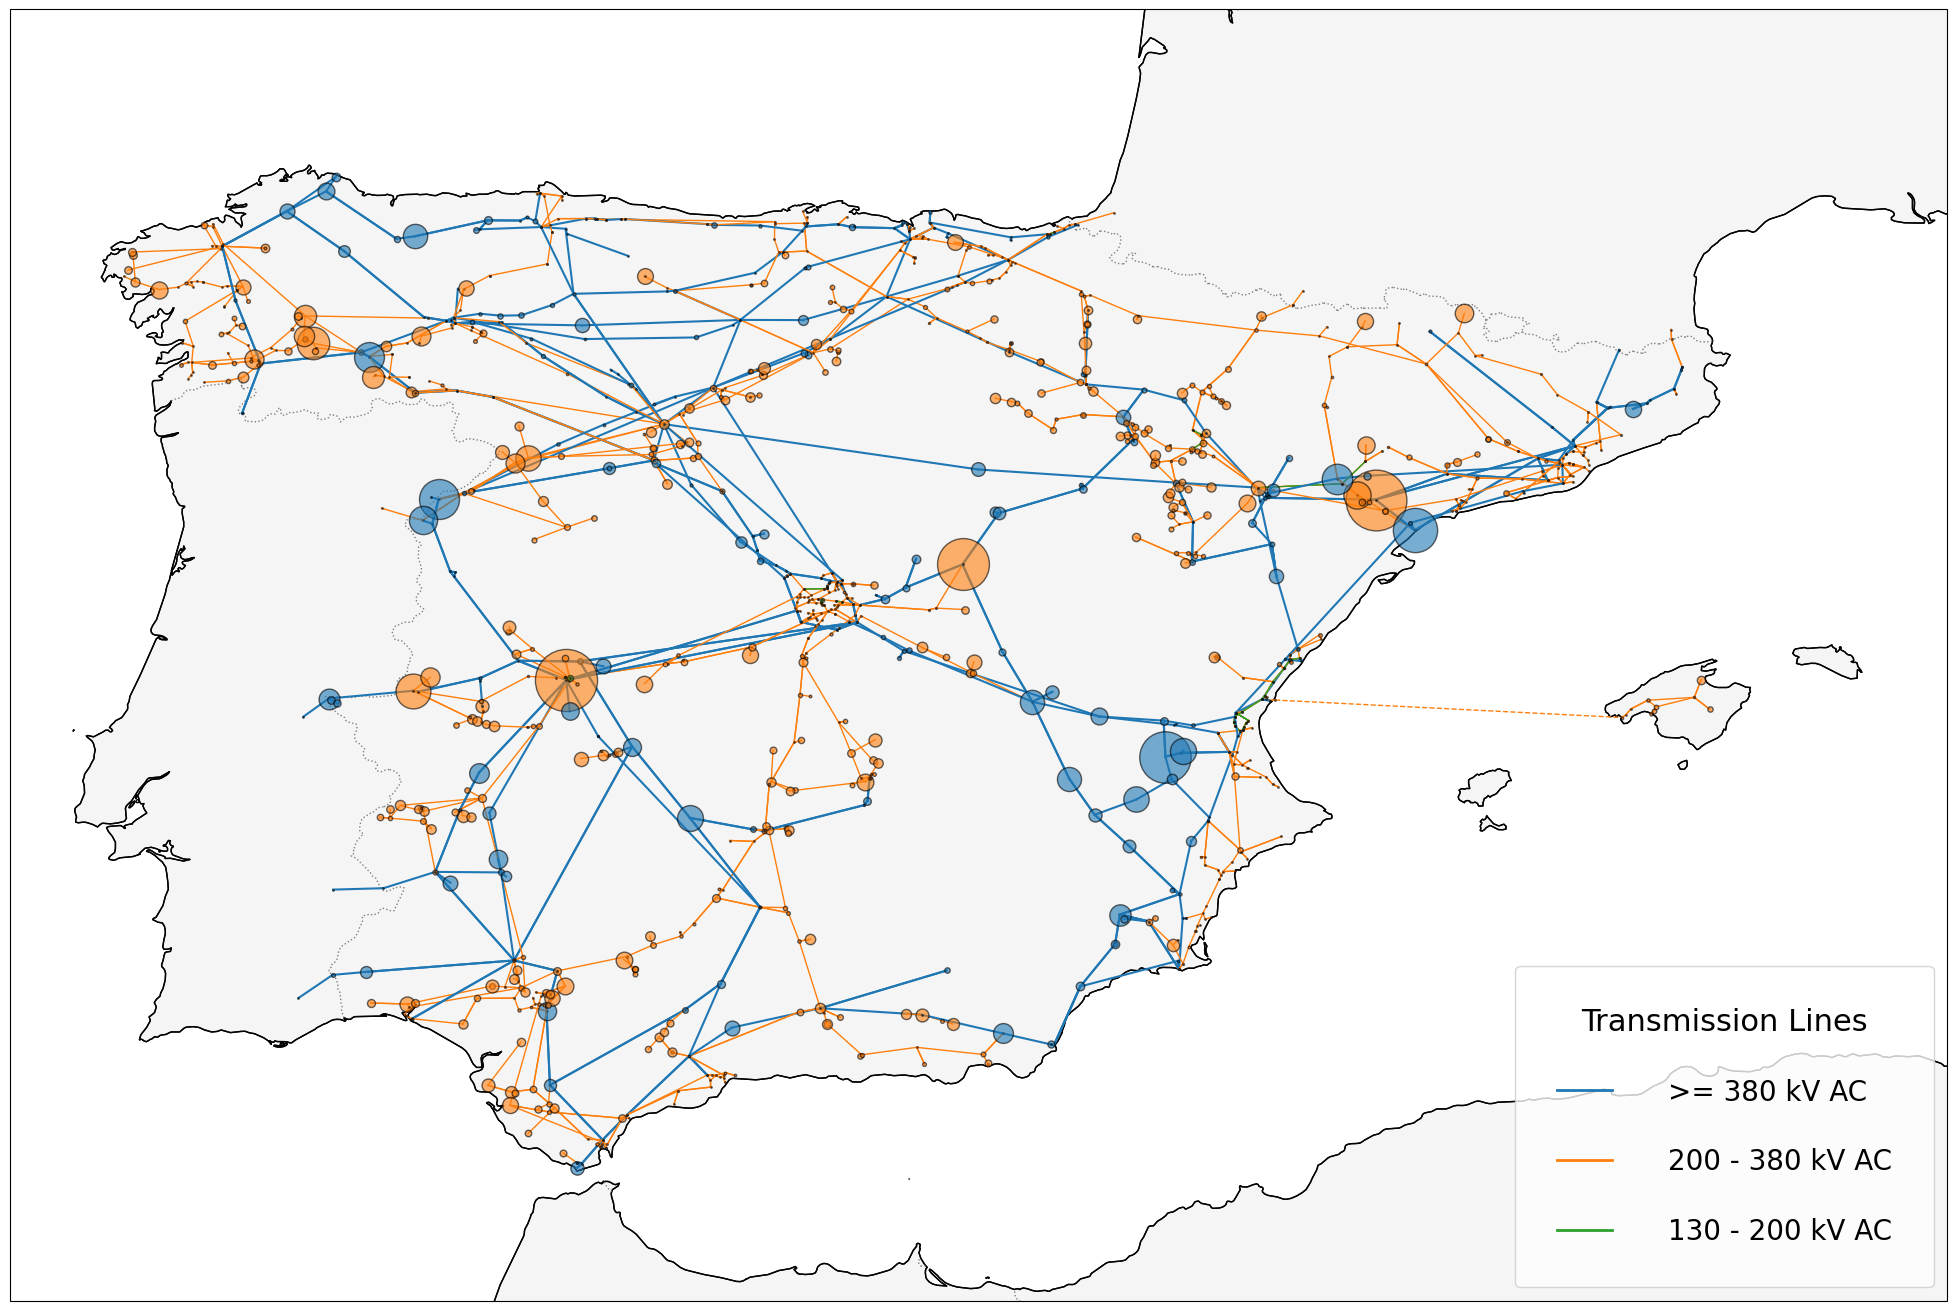

In [91]:
hourly_gen = pd.read_csv(smspp_dir / 'nutsx/results_srdacopf_ij_12/ActivePower/ActivePowerOUT.csv')
# Sum actual generation per unit over all timesteps (daily total)
unit_generation_total = hourly_gen.drop(columns='Timestep').sum().reset_index()
unit_generation_total.columns = ['unit_id', 'actual_gen_mwh']

plot_bus_generation(unit_generation_total)

## Dispatch at each stage

Each subplot shows hourly electricity generation stacked by technology (MW) alongside total system load (black line) for a full 24-hour period. Positive bars represent generation or scheduled imports; the black line is total system demand. Any gap between stacked generation and the load line reflects net scheduled exports or model imbalance.

Results are shown side-by-side for the **8th of July** (left) and the **2nd of December** (right) to highlight seasonal differences in the generation mix.

### Day-Ahead (DA)

The day-ahead dispatch represents the unit commitment and schedule agreed in the day-ahead market, before any intraday revisions or real-time corrections. This is the baseline against which all subsequent stage changes are measured.

C:\Users\ehsanno\AppData\Local\Temp\ipykernel_26264\3441761648.py:288: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(pad=0.6, h_pad=0.9, w_pad=0.6)


FileNotFoundError: [Errno 2] No such file or directory: 'plotting\\created_figures\\da.pdf'

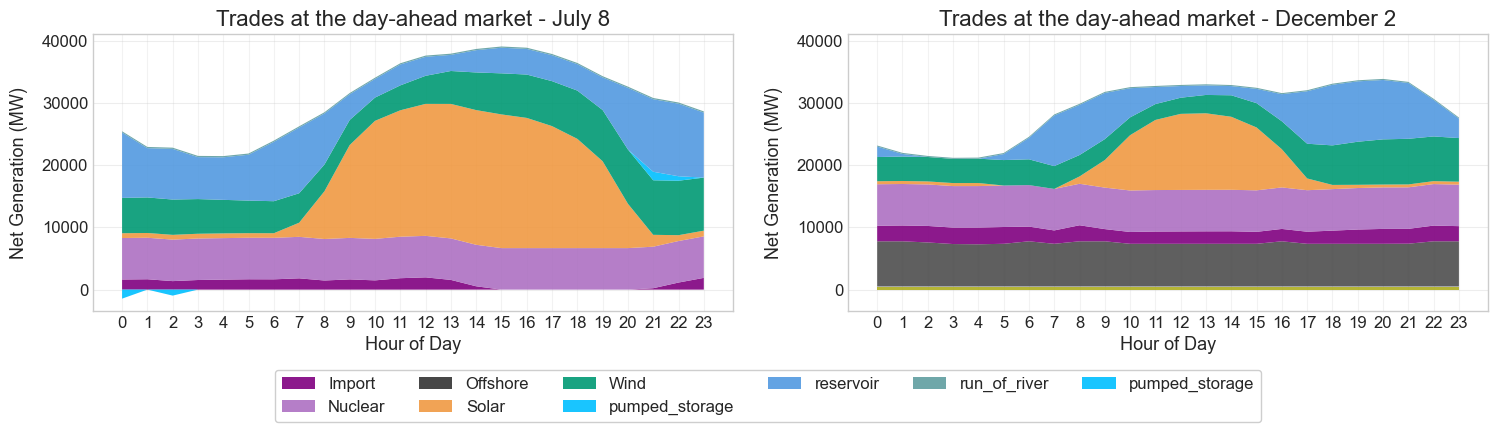

In [92]:

result = plot_generation_barchart_copperplate_stacked_area(active_power_dfs=[active_power_da,active_power_da_d2], generation_df= generation,
                                           titles=['Trades at the day-ahead market - July 8','Trades at the day-ahead market - December 2'],
                                           SHOW_VALUES=False,MERGE_HYDRO_TECHS=False, market_gates=[Market_Gate.CONTINUOUS,Market_Gate.CONTINUOUS], SAVE=True, save_file_title='da',
                                           figsize=(18, 4.5), sharey=True, legend_spacing=0.15)


### Intraday Gates (2nd and 3rd)

The 2nd and 3rd intraday gates allow market participants to revise their day-ahead positions as updated wind, solar, and load forecasts become available. Each subplot shows the updated total dispatch profile and demand for the respective gate. Differences from the DA schedule reflect voluntary re-trading in response to forecast revisions.

In [ ]:
plot_generation_barchart_copperplate_model(active_power_id2, generation, title='2nd ID Generation with Load Change', load_change_df=load_change_2id)
plot_generation_barchart_copperplate_model(active_power_id3, generation, title='3rd ID Generation with Load Change', load_change_df=load_change_3id)
plot_generation_barchart_copperplate_model(active_power_continuous, generation, title='continuous Generation with Load Change', load_change_df=load_change_balancing)

: 

: 

### Redispatch

Redispatch is a network-constrained re-scheduling step performed by the system operator to relieve transmission congestion identified after intraday trading. Generation units in congested export zones are curtailed while units in import zones are ramped up — keeping total generation roughly constant while resolving grid bottlenecks.

In [ ]:
plot_generation_barchart_copperplate_model(active_power_redispatch, generation, title='Redispatch Generation with Load Change', load_change_df=load_change_redispatch)

: 

: 

### Balancing Dispatch

Balancing is the final real-time correction stage where the system operator adjusts generation to match actual demand and compensate for remaining forecast errors. This dispatch profile represents the closest approximation to the physical generation that will occur at real-time gate closure.

In [ ]:
plot_generation_barchart_copperplate_model(active_power_balancing, generation, title='balancing Generation with Load Change', load_change_df=load_change_balancing)

: 

: 

## Hourly dispatch change at each gate

These figures show the **incremental change** in generation and load relative to the *previous* market stage, for each hour of the day.

- **Positive bars**: technologies or imports that were ramped **up** compared to the previous stage.
- **Negative bars**: technologies or exports that were **curtailed** or reduced.
- The **black markers** (load line) show the net demand adjustment at that stage.

This decomposition reveals which technologies absorb the most re-scheduling across gates and how the system adapts between the day-ahead schedule and real-time operation. Large changes indicate significant forecast errors or binding congestion corrections.

### Intraday Gates (2IG and 3IG)

Dispatch changes at the 2nd and 3rd intraday gates relative to the day-ahead schedule. These are market-driven adjustments: positive values indicate units that sold additional energy in the intraday market; negative values indicate units that reduced their day-ahead position. Large revisions typically signal substantial renewable forecast updates.

In [ ]:
plot_generation_barchart_copperplate_multi(active_power_dfs=[dispatch_change_2id,dispatch_change_3id,dispatch_change_2id_d2,dispatch_change_3id_d2], generation_df= generation, load_change_dfs=[load_change_2id,load_change_3id,load_change_2id_d2,load_change_3id_d2],
                                           titles=['Trades at the second intraday gate - July 8','Trades at the third intraday gate - July 8','Trades at the second intraday gate - December 2','Trades at the third intraday gate - December 2'],
                                           SHOW_VALUES=False,MERGE_HYDRO_TECHS=True, market_gates=[Market_Gate.INTRADAY_2,Market_Gate.INTRADAY_3,Market_Gate.INTRADAY_2,Market_Gate.INTRADAY_3], SAVE=True, save_file_title='generation_change_id_2_3',
                                           figsize=(18, 8), sharey=True)

: 

: 

In [ ]:

plot_generation_barchart_copperplate_multi(active_power_dfs=[dispatch_change_2id,dispatch_change_3id,dispatch_change_2id_d2,dispatch_change_3id_d2], generation_df= generation, load_change_dfs=[load_change_2id,load_change_3id,load_change_2id_d2,load_change_3id_d2],
                                           titles=['Trades at the second intraday gate - July 8','Trades at the third intraday gate - July 8','Trades at the second intraday gate - December 2','Trades at the third intraday gate - December 2'],
                                           SHOW_VALUES=False,MERGE_HYDRO_TECHS=True, market_gates=[Market_Gate.INTRADAY_2,Market_Gate.INTRADAY_3,Market_Gate.INTRADAY_2,Market_Gate.INTRADAY_3], SAVE=True, save_file_title='generation_change_id_2_3',
                                           figsize=(18, 8), sharey=True)

plot_generation_barchart_copperplate_multi(active_power_dfs=[dispatch_change_continuous,dispatch_change_continuous_d2], generation_df= generation, load_change_dfs=[load_change_continuous,load_change_continuous_d2],
                                           titles=['Trades at the continuous intraday gate - July 8','Trades at the continuous intraday gate - December 2'],
                                           SHOW_VALUES=False,MERGE_HYDRO_TECHS=True, market_gates=[Market_Gate.CONTINUOUS,Market_Gate.CONTINUOUS], SAVE=True, save_file_title='generation_change_ci',
                                           figsize=(18, 4.5), sharey=True, legend_spacing=0.15)

: 

: 

### Redispatch

Dispatch changes resulting from the redispatch stage relative to continuous intraday. Unlike intraday changes (which are market-driven), these adjustments are mandated by the system operator to resolve network congestion. The geographic pattern — which nodes increase vs. decrease — reveals the location of binding transmission constraints in the network.

In [ ]:
plot_generation_barchart_nodal_multi(active_power_dfs=[dispatch_change_redispatch,dispatch_change_redispatch_d2], generation_df= generation, load_change_dfs=[load_change_redispatch,load_change_redispatch_d2],
                                           titles=['Dispatch change in the redispatch - 8th of July','Dispatch change in the redispatch - 2nd of December'],
                                           SHOW_VALUES=False,MERGE_HYDRO_TECHS=False, SAVE=True, save_file_title='generation_change_re',
                                           figsize=(18, 4.5), sharey=True, legend_spacing=0.15)


: 

: 

### Balancing

Final real-time dispatch corrections at the balancing stage relative to redispatch. These residual changes capture last-minute forecast errors and system needs not covered by earlier market stages. Smaller magnitudes compared to earlier stages indicate that the sequential market design is progressively reducing the need for real-time intervention.

In [ ]:
plot_generation_barchart_nodal_multi(active_power_dfs=[dispatch_change_balancing,dispatch_change_balancing_d2], generation_df= generation, load_change_dfs=[load_change_balancing,load_change_balancing_d2],
                                           titles=['Dispatch change in the balancing - 8th of July','Dispatch change in the balancing - 2nd of December'],
                                           SHOW_VALUES=False,MERGE_HYDRO_TECHS=False, SAVE=True, save_file_title='generation_change_bal',
                                           figsize=(18, 4.5), sharey=True, legend_spacing=0.15)


: 

: 

## Generation–Load Imbalance Across Stages

The plots below show the hourly difference between total scheduled generation and total system load (Generation − Load, MW) at each market stage. In this copper-plate model (no explicit network constraints in the market stages), this difference represents the scheduled net cross-border exchange: positive = net export hour; negative = net import hour.

Across successive stages the absolute imbalance should remain roughly consistent (reflecting Spain's scheduled cross-border position), with any stage-to-stage drift indicating load forecast revisions or changes in import/export contracts.

### 8th of July (Summer Day)

Summer conditions with high solar PV output, elevated wind generation, and moderate demand. The imbalance profile reflects Spain's typical summer pattern of midday renewable surplus and the resulting net export position during peak solar hours.

In [ ]:
plt.plot(load_change_1id['Timestep'], dif_da, label='Day-Ahead (DA)', marker='o')
plt.plot(load_change_2id['Timestep'], dif_2id, label='2nd Intraday Gate (2IG)', marker='s')
plt.plot(load_change_3id['Timestep'], dif_3id, label='3rd Intraday Gate (3IG)', marker='^')
plt.plot(load_change_continuous['Timestep'], dif_continuous, label='Continuous Intraday (CIG)', marker='d')
plt.plot(load_change_redispatch['Timestep'], dif_redispatch, label='Redispatch (RD)', marker='x')
plt.plot(load_change_balancing['Timestep'], dif_balancing, label='Balancing (BAL)', marker='v')

plt.style.use('ggplot')
plt.title('Generation − Load Imbalance Across Market Stages — 8th of July')
plt.xlabel('Hour of Day')
plt.ylabel('Generation − Load (MW)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

: 

: 

### 2nd of December (Winter Day)

Winter conditions with low solar irradiation, higher heating demand, and a different renewable mix. Thermal and hydro generation carry a greater share of the load, and the net export/import balance differs markedly from the summer case.

In [ ]:
plt.plot(load_change_1id_d2['Timestep'], dif_da_d2, label='Day-Ahead (DA)', marker='o')
plt.plot(load_change_2id_d2['Timestep'], dif_2id_d2, label='2nd Intraday Gate (2IG)', marker='s')
plt.plot(load_change_3id_d2['Timestep'], dif_3id_d2, label='3rd Intraday Gate (3IG)', marker='^')
plt.plot(load_change_continuous_d2['Timestep'], dif_continuous_d2, label='Continuous Intraday (CIG)', marker='d')
plt.plot(load_change_redispatch_d2['Timestep'], dif_redispatch_d2, label='Redispatch (RD)', marker='x')
plt.plot(load_change_balancing_d2['Timestep'], dif_balancing_d2, label='Balancing (BAL)', marker='v')

plt.style.use('ggplot')
plt.title('Generation − Load Imbalance Across Market Stages — 2nd of December')
plt.xlabel('Hour of Day')
plt.ylabel('Generation − Load (MW)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

: 

: 

# Part 4: OPF after DA
This part is about plotting the results of running redispatch right after DA market, neglecting the intraday trading.


## Loading the data

In [ ]:
# dispatch result of the redispatch performed after DA
active_power_da_redispatch = pd.read_csv(smspp_dir / "nutsx/results_srdacopf/ActivePower/ActivePowerOUT.csv")

# load result of the redispatch performed after DA
load_da_redispatch = pd.read_csv(smspp_dir / "nutsx/results_srdacopf/Demand/DemandOUT.csv")

# dispatch difference between DA and redispatch
dispatch_change_da_redispatch =  active_power_da_redispatch - active_power_da;      dispatch_change_da_redispatch['Timestep'] = active_power_da['Timestep']

# load difference between DA and redispatch
load_change_da_redispatch = load_da_redispatch.drop(columns='Timestep') - load_da.drop(columns='Timestep')
load_change_da_redispatch = pd.DataFrame({
    'Timestep': load_da_redispatch['Timestep'],
    'Node_0': load_change_da_redispatch.sum(axis=1)
})
# Difference between load and generation in the redispatch after DA
dif_da_redispatch = active_power_da_redispatch.drop(columns='Timestep').sum(axis=1) - load_da_redispatch.drop(columns='Timestep').sum(axis=1)

: 

: 

### Hourly dispatch change

In [ ]:
plot_generation_barchart_copperplate_model(dispatch_change_da_redispatch, generation, load_change_df=load_change_da_redispatch,  title='Dispatch change in the redispatch after DA - 8th of July')

: 

: 

### Difference between load and generation in the redispatch after DA

In [ ]:
plt.plot(range(0, 24), dif_da_redispatch, label='Redispatch after DA (RD)', marker='s')
plt.plot(range(0, 24), dif_da, label='Day-Ahead (DA)', marker='o')

plt.title('Generation − Load Imbalance: DA vs. Redispatch After DA — 8th of July')
plt.xlabel('Hour of Day')
plt.ylabel('Generation − Load (MW)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

: 

: 

# Part 5: Plotting maps




## Interactive map




The interactive map is designed for analyzing redispatch results. For the other gates, flow data is not available, so the map cannot be generated for those cases.

You can create the map under various conditions:

* Select July or December days only if you midify the Part 1: loading the results section to load the December results,

* Choose between AC or DC cases (note: DC results are only available for the run performed right after DA, not after intraday),

* Decide whether you want to visualize the actual injection at the buses (DISPATCH_CHANGE = False),

* Or the change in bus injections compared to the previous gate (DISPATCH_CHANGE = True).


In [ ]:

hour = 13 #from 1 to 24
max_capacity_pct = 70   # Maximum allowed percentage of line capacity to be used
min_utilization_pct = 0.0

SBASE = 100  # MVA – system base for per-unit transmission flow values (update here if Sbase ever changes)

DEC                 = True    # Set to True if you want to plot the results of 2nd of December
DC                  = False    # Set to True if you want to plot the results of DC model
APPARENT_FLOW       = True     # Set to True if you want to consider the apparent flow (complex power flow)
DISPATCH_CHANGE     = True     # Set to True if you want to plot the dispatch CHANGES results. Otherwise, it will plot the dispatch results itself
PLOT_LOAD           = True     # Set to True if DISPATCH_CHANGE is True or you want to plot the load at each bus.
PLOT_GENERATION     = True     # Set it True if you want to see the generation valuse beside the line flows
SAVE_PLOT           = False     # Set it True if you want to save the plot as an HTML file
REDISPATCH_AFTER_DA = False     # Set it True if you want to plot the redispatch results perforemed after DA



DC = REDISPATCH_AFTER_DA and DC  # If REDISPATCH_AFTER_DA is True, then DC can be True. DC redispatch has been run only after DA, not after intraday gates.
# Set cos_phi based on apparent flow
if APPARENT_FLOW:
    cos_phi = 1.0
else:
    cos_phi = 0.95

if DEC:
    Dec_term = '_d2'
else:
    Dec_term= ''

if DC:
    AC_DC_term = 'dc'
else:
    AC_DC_term= 'ac'

if REDISPATCH_AFTER_DA:
    folder_name = smspp_dir / f'nutsx/results_srd{AC_DC_term}opf{Dec_term}'
    load_perv_stage = pd.read_csv(smspp_dir / f'nutsx/results{Dec_term}_da_pomatwo/Demand/DemandOUT.csv')
    load_perv_stage_distributed = create_demandout_df(load_perv_stage)
    active_power_da = pd.read_csv(smspp_dir / f'nutsx/results{Dec_term}_da_pomatwo/ActivePower/ActivePowerOUT.csv')
else:
    folder_name = smspp_dir / f'nutsx/results_srdacopf_ij{Dec_term}_{hour}'
    load_perv_stage = load_continuous_market.copy()  # Use continuous market load as perv stage
    load_perv_stage_distributed = create_demandout_df(load_perv_stage)
    active_power_da = active_power_continuous.copy()  # Use continuous market active power as perv stage


# Save file title based on the parameters
if DISPATCH_CHANGE:
    save_file_title = f'{AC_DC_term.upper()}_flow_hour_{hour-1}_dispatch_change.html'
else:
    save_file_title = f'{AC_DC_term.upper()}_flow_hour_{hour-1}_redispatch_results.html'




load_redispatch = pd.read_csv(f'{folder_name}/Demand/DemandOUT.csv')

active_power = pd.read_csv(f'{folder_name}/ActivePower/ActivePowerOUT.csv')

# Transmission lines flows – values are in per-unit (Sbase = SBASE MVA)
if APPARENT_FLOW:
    # Load real and reactive power flow
    flows_real = pd.read_csv(f'{folder_name}/Flows/FlowsOUT.csv')
    flows_imag = pd.read_csv(f'{folder_name}/Flows/FlowsImagOUT.csv')

    # Compute apparent power flow (element-wise); result still in per-unit
    flows = pd.DataFrame(np.sqrt(flows_real**2 + flows_imag**2), columns=flows_real.columns)
else:
    flows = pd.read_csv(smspp_dir / f'nutsx/results_srd{AC_DC_term}opf{Dec_term}/Flows/FlowsOUT.csv')


if DISPATCH_CHANGE:
    dispatch_change = active_power - active_power_da;   dispatch_change['Timestep'] = active_power['Timestep']
    load_change = load_redispatch - load_perv_stage_distributed;    load_change['Timestep'] = load_redispatch['Timestep']

    unit_generation_total = dispatch_change.drop(columns='Timestep').iloc[hour-1].reset_index()
    hourly_load = load_change.drop(columns='Timestep').iloc[hour-1].reset_index()

else:
    unit_generation_total = active_power.drop(columns='Timestep').iloc[hour-1].reset_index()
    hourly_load = load_redispatch.drop(columns='Timestep').iloc[hour-1].reset_index()

unit_generation_total.columns = ['unit_id', 'actual_gen_mwh']
hourly_load.columns = ['bus_id', 'demand']


flows_out_dc_d2 = pd.read_csv(smspp_dir / f'nutsx/results_srddcopf_d2/Flows/FlowsOUT.csv')

# plot_power_flow(unit_generation_total=unit_generation_total, flows_out=flows, plot_load=PLOT_LOAD,
#                 bus_demand=hourly_load, plot_generation=PLOT_GENERATION, hour=hour-1,
#                 max_capacity_pct=max_capacity_pct, min_utilization_pct=min_utilization_pct,
#                 save=SAVE_PLOT, cos_phi=cos_phi, pu_flag=1, base_power_mw=SBASE)

plot_power_flow_interactive(unit_generation_total=unit_generation_total, flows_out=flows, plot_load=PLOT_LOAD, bus_demand=hourly_load,
                            plot_generation=PLOT_GENERATION, hour=hour-1, save_path=save_file_title,
                            max_capacity_pct=max_capacity_pct, save=SAVE_PLOT, cos_phi=cos_phi,
                            pu_flag=1, base_power_mw=SBASE)


: 

: 

## Overused lines

In [ ]:
Dec = False
hour = 12 # From 1 to 24
apparent_flow = True
min_utilization_pct=68
upper_limit= 8
SBASE = 100  # MVA – system base for per-unit transmission flow values (update here if Sbase ever changes)

if Dec:
    Dec_term = '_d2'
else:
    Dec_term= ''

hourly_gen = pd.read_csv(smspp_dir / f'nutsx/results_srdacopf_ij{Dec_term}_{hour}/ActivePower/ActivePowerOUT.csv')
hourly_load = pd.read_csv(smspp_dir / f'nutsx/results_srdacopf_ij{Dec_term}_{hour}/Demand/DemandOUT.csv')
# Sum actual generation per unit over all timesteps (daily total)
# unit_generation_total = hourly_gen.drop(columns='Timestep').sum().reset_index()
unit_generation_total = hourly_gen.drop(columns='Timestep').iloc[hour-1].reset_index()
unit_generation_total.columns = ['unit_id', 'actual_gen_mwh']

hourly_load = hourly_load.drop(columns='Timestep').iloc[hour-1].reset_index()
hourly_load.columns = ['bus_id', 'demand']

if apparent_flow:
    # Load real and reactive power flow (values in per-unit, Sbase = SBASE MVA)
    flows_real = pd.read_csv(smspp_dir / f'nutsx/results_srdacopf_ij{Dec_term}_{hour}/Flows/FlowsOUT.csv')
    flows_imag = pd.read_csv(smspp_dir / f'nutsx/results_srdacopf_ij{Dec_term}_{hour}/Flows/FlowsImagOUT.csv')

    # Compute apparent power flow (element-wise); result still in per-unit
    flows = pd.DataFrame(np.sqrt(flows_real**2 + flows_imag**2), columns=flows_real.columns)
else:
    flows = pd.read_csv(smspp_dir / f'nutsx/results_srdacopf_ij{Dec_term}_{hour}/Flows/FlowsOUT.csv')


plot_line_overuse_hours(unit_generation_total, flows, hourly_load,
                        save=False,
                        min_utilization_pct=min_utilization_pct, upper_limit=upper_limit, cos_phi=0.99,
                        ANNOTATION=False,
                        show_zoom=True,
                        shade_spain_split=True,
                        pu_flag=1, base_power_mw=SBASE
                        )


: 

: 

: 

: 

## Two devided Areas

devided areas with installed vapacity and load

In [ ]:
def plot_line_overuse_hours(
    unit_generation_total, flows_out, bus_demand=None,
    show_generation=False, show_load=False,
    min_utilization_pct=0, save=False, upper_limit=8, cos_phi=1,
    fig_size=(20, 30), ANNOTATION=False,
    show_zoom=False,
    shade_spain_split=True,
    color_NE="#EDF5F1", color_SW="#F0E4EF",
    fill_alpha=0.28,
    pu_flag=0, base_power_mw=100,
    # === NEW INPUTS FOR PIE CHARTS ===
    show_area_pies=True,
    gen_units_df=None,
    bus_peak_df=None,
    cap_col="capacity_mw",
    peak_col="peak_load_mw",
    pie_size=0.16,          # side length as fraction of axes (0..1)
    pie_wedge_colors=("tab:blue", "tab:orange", "tab:green")  # (dispatchable, undispatchable, load)
):
    import pandas as pd
    import numpy as np
    import matplotlib.pyplot as plt
    import matplotlib.colors as mcolors
    from matplotlib.colors import LinearSegmentedColormap
    from matplotlib.lines import Line2D
    from matplotlib.patches import Rectangle, Patch
    from mpl_toolkits.axes_grid1.inset_locator import inset_axes
    from cartopy.mpl.geoaxes import GeoAxes
    import cartopy.crs as ccrs
    import cartopy.feature as cfeature
    from cartopy.io import shapereader as shpreader
    from shapely.geometry import LineString, MultiLineString, JOIN_STYLE, Point
    from shapely.ops import split, unary_union

    # === Load inputs ===
    buses = pd.read_csv(data_dir / 'Bus_Data.csv')
    lines = pd.read_csv(data_dir / 'lines.csv')

    # Optional overlays (unchanged) ...
    if show_generation and unit_generation_total is not None:
        unit_bus_mapping = pd.read_csv(data_dir / 'generations.csv')[['unit_id', 'bus_id']]
        unit_generation_total = unit_generation_total.merge(unit_bus_mapping, on='unit_id')
        bus_actual_generation = unit_generation_total.groupby('bus_id')['actual_gen_mwh'].sum().reset_index()
        buses = buses.merge(bus_actual_generation, on='bus_id', how='left').fillna(0)
    else:
        buses['actual_gen_mwh'] = 0

    if show_load and bus_demand is not None:
        buses = buses.merge(bus_demand, on='bus_id', how='left').fillna(0)
    else:
        buses['demand'] = 0

    buses['injection_mwh'] = buses['actual_gen_mwh'] - buses['demand']

    # === Prepare flows ===
    flows_out = flows_out.loc[:, flows_out.columns.str.startswith('L')].copy()
    flows_out.columns = flows_out.columns.str[1:]
    flow_scale = base_power_mw if pu_flag == 1 else 1.0
    flows_out = flows_out * flow_scale
    common_lines = set(flows_out.columns).intersection(set(lines['line_id']))
    if not common_lines:
        print("No overlapping lines between flows_out and network definition.")
        return
    lines_filtered = lines[lines['line_id'].isin(common_lines)].copy()
    flows_out_filtered = flows_out[list(common_lines)].copy()

    # === Thermal capacity ===
    lines_filtered['thermal_capacity'] = (
        lines_filtered['voltage'] * lines_filtered['Imax'] * np.sqrt(3) * cos_phi
    )
    cap = lines_filtered.set_index('line_id')['thermal_capacity'].replace(0, np.nan)
    utilization_pct = 100 * flows_out_filtered.abs().div(cap)

    overuse_hours = (utilization_pct > min_utilization_pct).sum()
    lines_filtered['overuse_hours'] = lines_filtered['line_id'].map(overuse_hours).fillna(0).astype(int)
    lines_filtered['capped_overuse'] = lines_filtered['overuse_hours'].clip(upper=upper_limit)
    avg_flow = flows_out_filtered.abs().mean()
    lines_filtered['avg_flow'] = lines_filtered['line_id'].map(avg_flow).fillna(0)

    # === Colors etc. ===
    color_list = [
        '#c5cae9', '#bbdefb', '#4db6ac', '#81c784',
        '#9e9d24', '#f9a825', '#ef6c00', '#b71c1c'
    ]
    cmap = LinearSegmentedColormap.from_list('blue2red8', color_list, N=256)
    zero_color = '#d0d0d0'
    norm = mcolors.Normalize(vmin=1, vmax=upper_limit)

    # === Figure / main map ===
    fig, ax = plt.subplots(figsize=fig_size, subplot_kw={'projection': ccrs.PlateCarree()})
    fig.patch.set_alpha(0)
    ax.add_feature(cfeature.LAND, edgecolor='gray', facecolor='whitesmoke')
    ax.add_feature(cfeature.COASTLINE, edgecolor='k')
    ax.add_feature(cfeature.BORDERS, linestyle=':', edgecolor='darkgray')
    ax.set_facecolor('none')
    ax.set_extent([-10, 5, 35, 45], crs=ccrs.PlateCarree())
    ax.set_extent([-10, 5, 35, 45], crs=ccrs.PlateCarree())

    # Keep handles to area polygons if we can compute them
    ne_poly = sw_poly = None

    # === Shade Spain NE vs SW, split by a line through 4 buses ===
    if shade_spain_split or show_area_pies:
        shpfile = shpreader.natural_earth(resolution="10m", category="cultural", name="admin_0_countries")
        recs = shpreader.Reader(shpfile).records()
        spain_parts = [r.geometry for r in recs if r.attributes.get("ADM0_A3") == "ESP"]
        if spain_parts:
            spain = unary_union(spain_parts)
            mainland = max(spain.geoms, key=lambda g: g.area) if spain.geom_type == "MultiPolygon" else spain

            split_ids = ["ES00354", "ES00014", "ES00021", "ES00067"]
            pts = []
            for bid in split_ids:
                row = buses.loc[buses["bus_id"] == bid]
                if row.empty:
                    print(f"[warn] Bus {bid} not found; shading/pies skipped.")
                    pts = []
                    break
                pts.append((float(row["x"].values[0]), float(row["y"].values[0])))

            if len(pts) >= 2:
                def extend_polyline(points, L=5.0):
                    p = points[:]
                    dx1, dy1 = p[1][0]-p[0][0], p[1][1]-p[0][1]
                    n1 = np.hypot(dx1, dy1) or 1.0
                    p0 = (p[0][0] - L*dx1/n1, p[0][1] - L*dy1/n1)
                    dx2, dy2 = p[-1][0]-p[-2][0], p[-1][1]-p[-2][1]
                    n2 = np.hypot(dx2, dy2) or 1.0
                    pN = (p[-1][0] + L*dx2/n2, p[-1][1] + L*dy2/n2)
                    return [p0] + p[1:-1] + [pN]

                split_line = LineString(extend_polyline(pts, L=5.0))
                pieces = split(mainland, split_line)

                if len(pieces.geoms) >= 2:
                    parts = sorted(pieces.geoms, key=lambda g: g.area, reverse=True)[:2]
                    scores = [2.5*g.representative_point().y + 0.3*g.representative_point().x for g in parts]
                    ne_idx = int(np.argmax(scores))
                    ne_poly, sw_poly = parts[ne_idx], parts[1-ne_idx]

                    if shade_spain_split:
                        ax.add_geometries([ne_poly], crs=ccrs.PlateCarree(),
                                          facecolor=color_NE, edgecolor="none", alpha=fill_alpha, zorder=0)
                        ax.add_geometries([sw_poly], crs=ccrs.PlateCarree(),
                                          facecolor=color_SW, edgecolor="none", alpha=fill_alpha, zorder=0)

                        # offset dashed borders (unchanged from your code) ...
                        border_offset_deg = 0.02
                        dash_pattern = (3, 1)
                        ne_line_color = "#54735F"
                        sw_line_color = "#A65B8C"
                        line_width = 2.0
                        base_ls = LineString(pts)
                        left_geom  = base_ls.parallel_offset(border_offset_deg,  side="left",
                                                             join_style=JOIN_STYLE.round)
                        right_geom = base_ls.parallel_offset(border_offset_deg, side="right",
                                                             join_style=JOIN_STYLE.round)

                        def largest_linestring(g):
                            if isinstance(g, LineString): return g
                            if isinstance(g, MultiLineString) and len(g.geoms): return max(g.geoms, key=lambda ls: ls.length)
                            return None
                        left_ls  = largest_linestring(left_geom)
                        right_ls = largest_linestring(right_geom)
                        if left_ls is not None and right_ls is not None:
                            mid_left  = left_ls.interpolate(0.5, normalized=True)
                            mid_right = right_ls.interpolate(0.5, normalized=True)
                            left_is_ne  = ne_poly.contains(mid_left)
                            right_is_ne = ne_poly.contains(mid_right)
                            if left_is_ne and not right_is_ne:
                                ne_ls, sw_ls = left_ls, right_ls
                            elif right_is_ne and not left_is_ne:
                                ne_ls, sw_ls = right_ls, left_ls
                            else:
                                dL = ne_poly.exterior.distance(mid_left)
                                dR = ne_poly.exterior.distance(mid_right)
                                ne_ls, sw_ls = (left_ls, right_ls) if dL <= dR else (right_ls, left_ls)
                            for ls, color in [(ne_ls, ne_line_color), (sw_ls, sw_line_color)]:
                                x, y = ls.xy
                                ax.plot(x, y, color=color, linewidth=line_width,
                                        linestyle=(0, dash_pattern),
                                        transform=ccrs.PlateCarree(), zorder=7)
                else:
                    print("[warn] Split returned <2 parts; shading/pies skipped.")
            else:
                print("[warn] Not enough points for split; shading/pies skipped.")
        else:
            print("[warn] Spain geometry not found; shading/pies skipped.")

    # === Draw network (unchanged) ===
    min_width, max_width = 0.5, 5
    flow_min = lines_filtered['avg_flow'].min()
    flow_max = lines_filtered['avg_flow'].max()

    def draw_network_on(ax_like):
        for _, line in lines_filtered.iterrows():
            bus0 = buses[buses['bus_id'] == line['bus0']]
            bus1 = buses[buses['bus_id'] == line['bus1']]
            if bus0.empty or bus1.empty: continue

            color = zero_color if line['overuse_hours'] == 0 else cmap(norm(line['capped_overuse']))
            linewidth = min_width if flow_max == flow_min else \
                min_width + (max_width - min_width) * ((line['avg_flow'] - flow_min) / (flow_max - flow_min))
            linestyle = '-' if line.get('dc', 'f') == 'f' else '--'
            x0, y0 = bus0["x"].values[0], bus0["y"].values[0]
            x1, y1 = bus1["x"].values[0], bus1["y"].values[0]
            ax_like.plot([x0, x1], [y0, y1], color=color, linewidth=linewidth,
                         linestyle=linestyle, transform=ccrs.PlateCarree())
            if (line['overuse_hours'] >= 1) and ANNOTATION:
                xm, ym = (x0 + x1) / 2.0, (y0 + y1) / 2.0
                dx, dy = (y1 - y0), -(x1 - x0)
                L = np.hypot(dx, dy)
                if L > 0: dx, dy = (dx / L) * 0.15, (dy / L) * 0.15
                else: dx = dy = 0.0
                ax_like.text(xm + dx, ym + dy, f"{int(line['overuse_hours'])}",
                             fontsize=14, weight='regular', color='black',
                             bbox=dict(boxstyle="round,pad=0.1", fc="white", ec="none", alpha=0.75),
                             transform=ccrs.PlateCarree(), zorder=7)
        # buses
        max_injection = buses['injection_mwh'].abs().max()
        sizes = np.full(len(buses), 2.0) if (max_injection == 0 or np.isnan(max_injection)) \
            else np.abs(2000 * (buses['injection_mwh'] / max_injection)) + 1
        colors = np.where(buses['injection_mwh'] >= 0, 'tab:blue', 'tab:orange')
        ax_like.scatter(buses.x, buses.y, s=sizes, color=colors, edgecolor="black",
                        alpha=0.6, linewidths=0.1, transform=ccrs.PlateCarree(), zorder=5)

    draw_network_on(ax)

    # === Colorbar & legend (unchanged) ===
    sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])
    cbar = plt.colorbar(sm, ax=ax, orientation='horizontal', pad=0.02, aspect=40)
    cbar.set_label('Number of Hours Line Overused', fontsize=20)
    cbar.ax.tick_params(labelsize=16)

    legend_elements = [
        Line2D([0], [0], color=zero_color, lw=2, label='No Congestion'),
        Line2D([0], [0], color='black', lw=0.5, label='Low Flow (thin line)'),
        Line2D([0], [0], color='black', lw=5,   label='High Flow (thick line)')
    ]

    # === NEW: Area pies ===
    if show_area_pies and (ne_poly is not None) and (sw_poly is not None) \
       and (gen_units_df is not None) and (bus_peak_df is not None):

        # Build a bus_id -> area map using polygon containment
        bus_pts = buses[['bus_id', 'x', 'y']].copy()
        def which_area(row):
            p = Point(row['x'], row['y'])
            if ne_poly.contains(p): return "NE"
            if sw_poly.contains(p): return "SW"
            return None
        bus_pts['area'] = bus_pts.apply(which_area, axis=1)
        area_map = bus_pts.set_index('bus_id')['area']

        # === Aggregate capacities by area (dispatchable vs undispatchable) ===
        gdf = gen_units_df[['bus_id', 'primary_fuel', cap_col]].copy()
        gdf = gdf.merge(area_map.rename('area'), left_on='bus_id', right_index=True, how='left')
        gdf = gdf.dropna(subset=['area'])
        undisp_mask = gdf['primary_fuel'].str.lower().isin(['wind', 'solar'])

        agg_cap = gdf.groupby('area').apply(
            lambda df: pd.Series({
                'cap_dispatchable': df.loc[~undisp_mask.loc[df.index], cap_col].sum(),
                'cap_undispatchable': df.loc[ undisp_mask.loc[df.index], cap_col].sum()
            })
        ).fillna(0.0)

        # === Aggregate peak load by area ===
        ldf = bus_peak_df[['bus_id', peak_col]].copy()
        ldf = ldf.merge(area_map.rename('area'), left_on='bus_id', right_index=True, how='left')
        ldf = ldf.dropna(subset=['area'])
        agg_load = ldf.groupby('area')[peak_col].sum().rename('peak_load').to_frame()

        # Merge to one table with both areas present
        areas = pd.Index(['NE', 'SW'], name='area')
        summary = (agg_cap.join(agg_load, how='outer').reindex(areas)).fillna(0.0)

        # Helper: place an inset pie centered at a data (lon,lat) location
        def add_pie_at_data_center(ax_main, center_lon, center_lat, sizes, colors, labels, box_size):
            # convert data->axes fraction to position the inset
            disp = ax_main.transData.transform((center_lon, center_lat))
            inv = ax_main.transAxes.inverted().transform(disp)
            ax_in = inset_axes(
                ax_main, width="100%", height="100%",
                bbox_to_anchor=(inv[0] - box_size/2, inv[1] - box_size/2, box_size, box_size),
                bbox_transform=ax_main.transAxes,
                borderpad=0
            )
            # pie
            # avoid zero-sum warning by short-circuit
            total = float(np.sum(sizes))
            if total <= 0:
                ax_in.axis('off')
                return
            wedges, _ = ax_in.pie(
                sizes, colors=colors, startangle=90, counterclock=False,
                wedgeprops=dict(linewidth=0.6, edgecolor='black', alpha=0.9)
            )
            ax_in.set_aspect('equal')
            ax_in.set_xticks([]); ax_in.set_yticks([])
            # optional labels inside could be added here
            return ax_in

        # Locations: representative points of the polygons
        ne_pt = ne_poly.representative_point()
        sw_pt = sw_poly.representative_point()
        ne_lon, ne_lat = float(ne_pt.x), float(ne_pt.y)
        sw_lon, sw_lat = float(sw_pt.x), float(sw_pt.y)

        # Build sizes per area: [dispatchable, undispatchable, load]
        ne_sizes = [
            summary.loc['NE', 'cap_dispatchable'],
            summary.loc['NE', 'cap_undispatchable'],
            summary.loc['NE', 'peak_load']
        ]
        sw_sizes = [
            summary.loc['SW', 'cap_dispatchable'],
            summary.loc['SW', 'cap_undispatchable'],
            summary.loc['SW', 'peak_load']
        ]
        labels = ["Dispatchable cap", "Undispatchable cap (wind+solar)", "Peak load"]
        colors = list(pie_wedge_colors)

        # Draw the pies
        add_pie_at_data_center(ax, ne_lon, ne_lat, ne_sizes, colors, labels, pie_size)
        add_pie_at_data_center(ax, sw_lon, sw_lat, sw_sizes, colors, labels, pie_size)

        # Extend legend with pie meaning
        legend_elements.extend([
            Patch(facecolor=colors[0], edgecolor='black', label=labels[0]),
            Patch(facecolor=colors[1], edgecolor='black', label=labels[1]),
            Patch(facecolor=colors[2], edgecolor='black', label=labels[2]),
        ])
    elif show_area_pies:
        print("[warn] Area pies requested but split polygons or input data are missing; pies skipped.")

    ax.legend(handles=legend_elements, loc="lower left", frameon=True,
              borderpad=1.5, handletextpad=2.0, labelspacing=1.2, fontsize=14)

    # === Optional zoomed inset (unchanged) ===
    if show_zoom:
        lat_max, lon_right = 40.715680, -3.326443
        lat_max2, lon_left  = 40.715680, -5.809641
        lat_min, lon_left2  = 39.622386, -5.809641
        lat_min2, lon_right2= 39.622386, -3.326443
        lon_min = min(lon_left, lon_left2)
        lon_max = max(lon_right, lon_right2)
        lat_min = min(lat_min, lat_min2)
        lat_max = max(lat_max, lat_max2)
        right_pad, bottom_pad, w, h = 0.01, -0.03, 0.35, 0.35
        axins = inset_axes(
            ax, width="100%", height="100%",
            bbox_to_anchor=(1 - w - right_pad, bottom_pad, w, h),
            bbox_transform=ax.transAxes,
            borderpad=0, axes_class=GeoAxes,
            axes_kwargs=dict(map_projection=ccrs.PlateCarree())
        )
        for spine in axins.spines.values():
            spine.set_edgecolor('black'); spine.set_linestyle('-.'); spine.set_linewidth(2.5)
        axins.add_feature(cfeature.LAND, edgecolor='black', facecolor='whitesmoke')
        axins.add_feature(cfeature.COASTLINE, linewidth=0.5)
        axins.add_feature(cfeature.BORDERS, linestyle='-', edgecolor='black', linewidth=0.4)
        axins.set_extent([lon_min, lon_max, lat_min, lat_max], crs=ccrs.PlateCarree())
        draw_network_on(axins)
        rect = Rectangle((lon_min, lat_min), width=(lon_max - lon_min), height=(lat_max - lat_min),
                         linewidth=1.5, edgecolor='k', facecolor='none', linestyle='-.',
                         transform=ccrs.PlateCarree(), zorder=10)
        ax.add_patch(rect)

    if save:
        plt.savefig('plotting/created_figures/line_overuse_spectrum.pdf', format='pdf',
                    bbox_inches='tight', dpi=300)
    plt.show()


: 

: 

In [ ]:
# gen_units_df must have: bus_id, primary_fuel, capacity_mw
# bus_peak_df   must have: bus_id, peak_load_mw

SBASE = 100  # MVA – system base for per-unit transmission flow values (update here if Sbase ever changes)
peak = 38880
buses['peak_load_mw'] = peak * (loads['demand'])

plot_line_overuse_hours(
    unit_generation_total=unit_generation_total,
    flows_out=flows,
    show_area_pies=True,
    gen_units_df=generation,
    bus_peak_df=buses,
    peak_col="peak_load_mw",
    pie_wedge_colors=("#4C78A8", "#F58518", "#54A24B"),
    min_utilization_pct=min_utilization_pct, upper_limit=upper_limit, cos_phi=0.99,
    ANNOTATION=False,
    show_zoom=True,
    shade_spain_split=True,
    pu_flag=1, base_power_mw=SBASE
)

# plot_line_overuse_hours(unit_generation_total, flows, hourly_load,
#                         save=False,
#                         min_utilization_pct=min_utilization_pct,upper_limit=upper_limit,cos_phi=0.99,
#                         ANNOTATION=False,
#                         show_zoom=True,
#                         shade_spain_split=True
#                         )


: 

: 

In [ ]:
def plot_power_flow(unit_generation_total=None, flows_out=None, bus_demand=None,
                    plot_high=True, plot_medium=True, plot_low=True,
                    plot_load=False, plot_generation=False,
                    min_utilization_pct=0.0, hour=0, save=False,
                    max_capacity_pct=100, cos_phi = 1, pu_flag=0, base_power_mw=100):
    buses = pd.read_csv(data_dir / 'Bus_Data.csv')
    lines = pd.read_csv(data_dir / 'lines.csv')
    loads = pd.read_csv(data_dir / 'load.csv')
    generation = pd.read_csv(data_dir / 'generations.csv')

    voltage_levels = {
        '380 kV': 380,
        '220 kV': 200,
        '130 kV': 130
    }

    entsoe_voltage_colors = {
        '380 kV': 'tab:blue',
        '220 kV': 'tab:orange',
        'low': 'tab:green',
        'outside': 'tab:purple'
    }

    # Map actual generation to bus ids if generation plotting is requested
    if plot_generation and unit_generation_total is not None:
        unit_bus_mapping = generation[['unit_id', 'bus_id']]
        unit_generation_total = unit_generation_total.merge(unit_bus_mapping, on='unit_id')
        bus_actual_generation = unit_generation_total.groupby('bus_id')['actual_gen_mwh'].sum().reset_index()
        buses = buses.merge(bus_actual_generation, on='bus_id', how='left').fillna(0)
    else:
        buses['actual_gen_mwh'] = 0

    # Merge demand if load plotting is requested
    if plot_load and bus_demand is not None:
        buses = buses.merge(bus_demand, on='bus_id', how='left').fillna(0)
    else:
        buses['demand'] = 0
        print("No load data provided, using zero demand for all buses.")

    # Calculate net injection: generation - demand
    buses['injection_mwh'] = buses['actual_gen_mwh'] - buses['demand']

    # Process flows
    flows_out = flows_out.loc[:, flows_out.columns.str.startswith('L')]
    flows_out.columns = flows_out.columns.str[1:]
    flow_scale = base_power_mw if pu_flag == 1 else 1.0
    flows_out = flows_out * flow_scale

    common_lines = set(flows_out.columns).intersection(set(lines['line_id']))
    lines_filtered = lines[lines['line_id'].isin(common_lines)].copy()
    flows_out_filtered = flows_out[list(common_lines)].copy()

    if hour != 0:
        if isinstance(hour, int) and 0 <= hour < flows_out_filtered.shape[0]:
            selected_flow = flows_out_filtered.iloc[hour].abs()
            lines_filtered['flow_mw'] = lines_filtered['line_id'].map(selected_flow)
        else:
            raise ValueError(f"Invalid hour: {hour}. Must be between 0 and {flows_out_filtered.shape[0]-1}")
    else:
        avg_flow = flows_out_filtered.abs().mean()
        lines_filtered['flow_mw'] = lines_filtered['line_id'].map(avg_flow)

    # Calculate thermal capacity
    # Calculate thermal capacity
    lines_filtered['thermal_capacity'] = (
    lines_filtered['voltage'] * 
    lines_filtered['Imax'] * 
    np.sqrt(3) * 
    lines_filtered['circuits'] * 
    cos_phi)
    
    # Apply max usable capacity percentage (e.g., N-1 reserve)
    lines_filtered['adjusted_capacity'] = lines_filtered['thermal_capacity'] * (max_capacity_pct / 100)
    

    # Compute utilization based on adjusted capacity
    lines_filtered['utilization_pct'] = (lines_filtered['flow_mw'] / lines_filtered['adjusted_capacity']) * 100

    # Filter by min utilization percentage
    lines_filtered = lines_filtered[lines_filtered['utilization_pct'] >= min_utilization_pct]

    # Set up color gradient based on utilization
    norm = mcolors.Normalize(vmin=0, vmax=100)
    cmap = plt.get_cmap('RdYlGn_r')

    fig, ax = plt.subplots(figsize=(20, 30), subplot_kw={'projection': ccrs.PlateCarree()})
    fig.patch.set_alpha(0)
    ax.add_feature(cfeature.LAND, edgecolor='black', facecolor='whitesmoke')
    ax.add_feature(cfeature.COASTLINE)
    ax.add_feature(cfeature.BORDERS, linestyle=':', edgecolor='gray')
    ax.coastlines(resolution='10m', color='gray', linewidth=0.01)
    ax.set_facecolor('none')
    ax.set_extent([-10, 5, 35, 45], crs=ccrs.PlateCarree())


    # Normalize linewidths
    min_width, max_width = 0.5, 5
    flow_min, flow_max = lines_filtered['flow_mw'].min(), lines_filtered['flow_mw'].max()

    for _, line in lines_filtered.iterrows():
        bus0 = buses[buses['bus_id'] == line['bus0']]
        bus1 = buses[buses['bus_id'] == line['bus1']]

        flow_color = cmap(norm(line['utilization_pct']))
        linestyle = '-' if line['dc'] == 'f' else '--'
        linewidth = min_width + (max_width - min_width) * ((line['flow_mw']) / (flow_max))

        ax.plot([bus0["x"].values[0], bus1["x"].values[0]],
                [bus0["y"].values[0], bus1["y"].values[0]],
                color=flow_color, linewidth=linewidth, linestyle=linestyle,
                transform=ccrs.PlateCarree())

    max_injection = buses['injection_mwh'].abs().max()
    buses['size'] = np.abs(2000 * (buses['injection_mwh'] / max_injection)) + 1
    buses['color'] = np.where(buses['injection_mwh'] >= 0, 'tab:blue', 'tab:orange')

    ax.scatter(buses.x, buses.y, s=buses['size'], color=buses['color'], edgecolor="black", alpha=0.6,
               transform=ccrs.PlateCarree(), zorder=5)

    legend_elements = [
        Line2D([0], [0], color=cmap(norm(0)), lw=4, label='0% Utilization'),
        Line2D([0], [0], color=cmap(norm(50)), lw=4, label='50% Utilization'),
        Line2D([0], [0], color=cmap(norm(100)), lw=4, label='100% Utilization'),
        Line2D([0], [0], color='black', lw=0.5, label='Low Flow (thin line)'),
        Line2D([0], [0], color='black', lw=5, label='High Flow (thick line)')
    ]

    ax.legend(handles=legend_elements, loc="lower right", frameon=True,
              borderpad=1.5, handletextpad=2.0, labelspacing=1.5, fontsize=20)

    if save:
        filename = f'power_flow_hour_{hour}.png' if hour is not None else 'power_flow.png'
        plt.savefig(filename, format='png')

    plt.show()

: 

: 

In [ ]:
import numpy as np

USE_APPARENT_FLOW = 0  # 0 = active power (P), 1 = apparent power (S = sqrt(P^2 + Q^2))
USE_PU = 1             # 0 = values in MW/Mvar, 1 = values in per-unit
BASE_POWER_MVA = 100.0 # Base power used to convert per-unit values to MW/Mvar
Dec = True
hour = 15 # From 1 to 24

if Dec:
    Dec_term = '_d2'
else:
    Dec_term= ''
    
hourly_gen = pd.read_csv(smspp_dir / f'nutsx/results_srdacopf_ij{Dec_term}_{hour}/ActivePower/ActivePowerOUT.csv')
hourly_load = pd.read_csv(smspp_dir / f'nutsx/results_srdacopf_ij{Dec_term}_{hour}/Demand/DemandOUT.csv')
# Sum actual generation per unit over all timesteps (daily total)
# unit_generation_total = hourly_gen.drop(columns='Timestep').sum().reset_index()
unit_generation_total = hourly_gen.drop(columns='Timestep').iloc[hour-1].reset_index()

#For dispatch change:
unit_generation_total = dispatch_change_redispatch.drop(columns='Timestep').iloc[hour-1].reset_index()
unit_generation_total.columns = ['unit_id', 'actual_gen_mwh']

hourly_load = hourly_load.drop(columns='Timestep').iloc[hour-1].reset_index()
hourly_load.columns = ['bus_id', 'demand']

flow_dir = smspp_dir / f'nutsx/results_srdacopf_ij{Dec_term}_{hour}/Flows'
flows_out = pd.read_csv(f'{flow_dir}/FlowsOUT.csv')

flow_scale = BASE_POWER_MVA if USE_PU == 1 else 1.0
p_cols = [c for c in flows_out.columns if c.startswith('L')]
flows_out_scaled = flows_out.copy()
flows_out_scaled[p_cols] = flows_out_scaled[p_cols] * flow_scale

if USE_APPARENT_FLOW == 1:
    flows_imag_out = pd.read_csv(f'{flow_dir}/FlowImagOUT.csv')
    q_cols = [c for c in flows_imag_out.columns if c.startswith('L')]
    common_cols = sorted(set(p_cols).intersection(q_cols))

    if not common_cols:
        raise ValueError('No common line-flow columns found between FlowsOUT.csv and FlowImagOUT.csv')

    flows_imag_scaled = flows_imag_out.copy()
    flows_imag_scaled[common_cols] = flows_imag_scaled[common_cols] * flow_scale

    flows_to_plot = flows_out_scaled.copy()
    flows_to_plot[common_cols] = np.sqrt(flows_out_scaled[common_cols]**2 + flows_imag_scaled[common_cols]**2)
else:
    flows_to_plot = flows_out_scaled

plot_power_flow(unit_generation_total, flows_to_plot, hourly_load,save=True, min_utilization_pct=0,plot_generation=True,hour=hour, plot_load=False,max_capacity_pct=68,cos_phi=0.99)

: 

: 

In [ ]:
def plot_line_overuse_hours(
    unit_generation_total, flows_out, bus_demand=None,
    show_generation=False, show_load=False,
    min_utilization_pct=0, save=False, upper_limit=8, cos_phi=1,
    fig_size=(20, 30), ANNOTATION=False,
    show_zoom=False,
    shade_spain_split=True,
    color_NE="#EDF5F1", color_SW="#F0E4EF",
    fill_alpha=0.28,
    pu_flag=0, base_power_mw=100,
    # === UPDATED INPUTS FOR PIE CHARTS ===
    show_area_pies=True,
    gen_units_df=None,        # must have ['unit_id','bus_id','primary_fuel']
    bus_peak_df=None,         # must have ['bus_id', peak_col]
    peak_col="peak_load_mw",
    pie_size=0.16,            # side length as fraction of axes (0..1)
    pie_wedge_colors=("tab:blue", "tab:orange", "tab:green")  # (dispatchable MWh, undispatchable MWh, peak MW)
):
    import pandas as pd
    import numpy as np
    import matplotlib.pyplot as plt
    import matplotlib.colors as mcolors
    from matplotlib.colors import LinearSegmentedColormap
    from matplotlib.lines import Line2D
    from matplotlib.patches import Rectangle, Patch
    from mpl_toolkits.axes_grid1.inset_locator import inset_axes
    from cartopy.mpl.geoaxes import GeoAxes
    import cartopy.crs as ccrs
    import cartopy.feature as cfeature
    from cartopy.io import shapereader as shpreader
    from shapely.geometry import LineString, MultiLineString, JOIN_STYLE, Point
    from shapely.ops import split, unary_union

    # === Load inputs ===
    buses = pd.read_csv(data_dir / 'Bus_Data.csv')
    lines = pd.read_csv(data_dir / 'lines.csv')

    # === Optional generation overlay (unchanged) ===
    if show_generation and unit_generation_total is not None:
        unit_bus_mapping = pd.read_csv(data_dir / 'generations.csv')[['unit_id', 'bus_id']]
        unit_generation_total_tmp = unit_generation_total.merge(unit_bus_mapping, on='unit_id', how='left')
        bus_actual_generation = unit_generation_total_tmp.groupby('bus_id')['actual_gen_mwh'].sum().reset_index()
        buses = buses.merge(bus_actual_generation, on='bus_id', how='left').fillna(0)
    else:
        buses['actual_gen_mwh'] = 0

    # === Optional demand overlay (unchanged) ===
    if show_load and bus_demand is not None:
        buses = buses.merge(bus_demand, on='bus_id', how='left').fillna(0)
    else:
        buses['demand'] = 0
    buses['injection_mwh'] = buses['actual_gen_mwh'] - buses['demand']

    # === Prepare flows (unchanged) ===
    flows_out = flows_out.loc[:, flows_out.columns.str.startswith('L')].copy()
    flows_out.columns = flows_out.columns.str[1:]
    flow_scale = base_power_mw if pu_flag == 1 else 1.0
    flows_out = flows_out * flow_scale
    common_lines = set(flows_out.columns).intersection(set(lines['line_id']))
    if not common_lines:
        print("No overlapping lines between flows_out and network definition.")
        return
    lines_filtered = lines[lines['line_id'].isin(common_lines)].copy()
    flows_out_filtered = flows_out[list(common_lines)].copy()

    # === Thermal capacity & overuse (unchanged) ===
    lines_filtered['thermal_capacity'] = (
        lines_filtered['voltage'] * lines_filtered['Imax'] * np.sqrt(3) * cos_phi
    )
    cap = lines_filtered.set_index('line_id')['thermal_capacity'].replace(0, np.nan)
    utilization_pct = 100 * flows_out_filtered.abs().div(cap)
    overuse_hours = (utilization_pct > min_utilization_pct).sum()
    lines_filtered['overuse_hours'] = lines_filtered['line_id'].map(overuse_hours).fillna(0).astype(int)
    lines_filtered['capped_overuse'] = lines_filtered['overuse_hours'].clip(upper=upper_limit)
    avg_flow = flows_out_filtered.abs().mean()
    lines_filtered['avg_flow'] = lines_filtered['line_id'].map(avg_flow).fillna(0)

    # === Colors etc. (unchanged) ===
    color_list = ['#c5cae9','#bbdefb','#4db6ac','#81c784','#9e9d24','#f9a825','#ef6c00','#b71c1c']
    cmap = LinearSegmentedColormap.from_list('blue2red8', color_list, N=256)
    zero_color = '#d0d0d0'
    norm = mcolors.Normalize(vmin=1, vmax=upper_limit)

    # === Figure / main map (unchanged) ===
    fig, ax = plt.subplots(figsize=fig_size, subplot_kw={'projection': ccrs.PlateCarree()})
    fig.patch.set_alpha(0)
    ax.add_feature(cfeature.LAND, edgecolor='gray', facecolor='whitesmoke')
    ax.add_feature(cfeature.COASTLINE, edgecolor='k')
    ax.add_feature(cfeature.BORDERS, linestyle=':', edgecolor='darkgray')
    ax.set_facecolor('none')
    ax.set_extent([-10, 5, 35, 45], crs=ccrs.PlateCarree())

    # --- compute NE/SW polygons (unchanged logic) ---
    ne_poly = sw_poly = None
    if shade_spain_split or show_area_pies:
        shpfile = shpreader.natural_earth(resolution="10m", category="cultural", name="admin_0_countries")
        recs = shpreader.Reader(shpfile).records()
        spain_parts = [r.geometry for r in recs if r.attributes.get("ADM0_A3") == "ESP"]
        if spain_parts:
            spain = unary_union(spain_parts)
            mainland = max(spain.geoms, key=lambda g: g.area) if spain.geom_type == "MultiPolygon" else spain
            split_ids = ["ES00354","ES00014","ES00021","ES00067"]
            pts = []
            for bid in split_ids:
                row = buses.loc[buses["bus_id"] == bid]
                if row.empty:
                    print(f"[warn] Bus {bid} not found; shading/pies skipped."); pts=[]; break
                pts.append((float(row["x"].values[0]), float(row["y"].values[0])))
            if len(pts) >= 2:
                def extend_polyline(points, L=5.0):
                    p=points[:]
                    dx1,dy1=p[1][0]-p[0][0], p[1][1]-p[0][1]; n1=np.hypot(dx1,dy1) or 1.0
                    p0=(p[0][0]-L*dx1/n1, p[0][1]-L*dy1/n1)
                    dx2,dy2=p[-1][0]-p[-2][0], p[-1][1]-p[-2][1]; n2=np.hypot(dx2,dy2) or 1.0
                    pN=(p[-1][0]+L*dx2/n2, p[-1][1]+L*dy2/n2)
                    return [p0]+p[1:-1]+[pN]
                split_line = LineString(extend_polyline(pts, L=5.0))
                pieces = split(mainland, split_line)
                if len(pieces.geoms) >= 2:
                    parts = sorted(pieces.geoms, key=lambda g: g.area, reverse=True)[:2]
                    scores=[2.5*g.representative_point().y + 0.3*g.representative_point().x for g in parts]
                    ne_idx=int(np.argmax(scores))
                    ne_poly, sw_poly = parts[ne_idx], parts[1-ne_idx]
                    if shade_spain_split:
                        ax.add_geometries([ne_poly], crs=ccrs.PlateCarree(),
                                          facecolor=color_NE, edgecolor="none", alpha=fill_alpha, zorder=0)
                        ax.add_geometries([sw_poly], crs=ccrs.PlateCarree(),
                                          facecolor=color_SW, edgecolor="none", alpha=fill_alpha, zorder=0)
                        # dashed offsets (same as before) ...
                        border_offset_deg=0.02; dash_pattern=(3,1)
                        ne_line_color="#54735F"; sw_line_color="#A65B8C"; line_width=2.0
                        base_ls = LineString(pts)
                        left_geom  = base_ls.parallel_offset(border_offset_deg,  side="left",  join_style=JOIN_STYLE.round)
                        right_geom = base_ls.parallel_offset(border_offset_deg, side="right", join_style=JOIN_STYLE.round)
                        def largest_linestring(g):
                            if isinstance(g, LineString): return g
                            if isinstance(g, MultiLineString) and len(g.geoms): return max(g.geoms, key=lambda ls: ls.length)
                            return None
                        left_ls, right_ls = largest_linestring(left_geom), largest_linestring(right_geom)
                        if left_ls is not None and right_ls is not None:
                            mid_left  = left_ls.interpolate(0.5, normalized=True)
                            mid_right = right_ls.interpolate(0.5, normalized=True)
                            left_is_ne  = ne_poly.contains(mid_left)
                            right_is_ne = ne_poly.contains(mid_right)
                            ne_ls, sw_ls = (left_ls,right_ls) if left_is_ne and not right_is_ne else \
                                           ((right_ls,left_ls) if right_is_ne and not left_is_ne else
                                            ((left_ls,right_ls) if ne_poly.exterior.distance(mid_left) <=
                                                                  ne_poly.exterior.distance(mid_right) else
                                             (right_ls,left_ls)))
                            for ls, color in [(ne_ls, ne_line_color), (sw_ls, sw_line_color)]:
                                x,y = ls.xy
                                ax.plot(x, y, color=color, linewidth=line_width,
                                        linestyle=(0, dash_pattern), transform=ccrs.PlateCarree(), zorder=7)
                else:
                    print("[warn] Split returned <2 parts; shading/pies skipped.")
            else:
                print("[warn] Not enough points for split; shading/pies skipped.")
        else:
            print("[warn] Spain geometry not found; shading/pies skipped.")

    # --- draw network (unchanged) ---
    min_width, max_width = 0.5, 5
    flow_min, flow_max = lines_filtered['avg_flow'].min(), lines_filtered['avg_flow'].max()
    def draw_network_on(ax_like):
        for _, line in lines_filtered.iterrows():
            bus0 = buses[buses['bus_id'] == line['bus0']]; bus1 = buses[buses['bus_id'] == line['bus1']]
            if bus0.empty or bus1.empty: continue
            color = zero_color if line['overuse_hours'] == 0 else cmap(norm(line['capped_overuse']))
            linewidth = min_width if flow_max == flow_min else min_width + (max_width-min_width)*(
                (line['avg_flow']-flow_min)/(flow_max-flow_min))
            linestyle = '-' if line.get('dc','f') == 'f' else '--'
            x0,y0 = bus0["x"].values[0], bus0["y"].values[0]; x1,y1 = bus1["x"].values[0], bus1["y"].values[0]
            ax_like.plot([x0,x1],[y0,y1], color=color, linewidth=linewidth, linestyle=linestyle,
                         transform=ccrs.PlateCarree())
            if (line['overuse_hours'] >= 1) and ANNOTATION:
                xm,ym=(x0+x1)/2.0,(y0+y1)/2.0; dx,dy=(y1-y0),-(x1-x0); L=np.hypot(dx,dy)
                dx,dy=(dx/L*0.15, dy/L*0.15) if L>0 else (0.0,0.0)
                ax_like.text(xm+dx, ym+dy, f"{int(line['overuse_hours'])}", fontsize=14, color='black',
                             bbox=dict(boxstyle="round,pad=0.1", fc="white", ec="none", alpha=0.75),
                             transform=ccrs.PlateCarree(), zorder=7)
        max_injection = buses['injection_mwh'].abs().max()
        sizes = np.full(len(buses), 2.0) if (max_injection==0 or np.isnan(max_injection)) \
                else np.abs(2000*(buses['injection_mwh']/max_injection)) + 1
        colors = np.where(buses['injection_mwh'] >= 0, 'tab:blue', 'tab:orange')
        ax_like.scatter(buses.x,buses.y, s=sizes, color=colors, edgecolor="black",
                        alpha=0.6, linewidths=0.1, transform=ccrs.PlateCarree(), zorder=5)
    draw_network_on(ax)

    # --- colorbar & base legend (unchanged) ---
    sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm); sm.set_array([])
    cbar = plt.colorbar(sm, ax=ax, orientation='horizontal', pad=0.02, aspect=40)
    cbar.set_label('Number of Hours Line Overused', fontsize=20)
    cbar.ax.tick_params(labelsize=16)
    legend_elements = [
        Line2D([0],[0], color=zero_color, lw=2, label='No Congestion'),
        Line2D([0],[0], color='black', lw=0.5, label='Low Flow (thin line)'),
        Line2D([0],[0], color='black', lw=5,   label='High Flow (thick line)')
    ]

    # === NEW: area pies using ACTUAL GENERATION (MWh) + PEAK LOAD (MW) ===
    if show_area_pies and (ne_poly is not None) and (sw_poly is not None) \
       and (gen_units_df is not None) and (bus_peak_df is not None) \
       and (unit_generation_total is not None):

        # Map each bus to NE/SW by polygon containment
        bus_pts = buses[['bus_id','x','y']].copy()
        def which_area(row):
            p = Point(row['x'], row['y'])
            if ne_poly.contains(p): return "NE"
            if sw_poly.contains(p): return "SW"
            return None
        bus_pts['area'] = bus_pts.apply(which_area, axis=1)
        area_map = bus_pts.set_index('bus_id')['area']

        # Merge unit actual generation with unit meta (bus_id, fuel)
        # Required columns: gen_units_df['unit_id','bus_id','primary_fuel']
        ug = unit_generation_total[['unit_id','actual_gen_mwh']].copy()
        meta = gen_units_df[['unit_id','bus_id','primary_fuel']].copy()
        ugm = ug.merge(meta, on='unit_id', how='left').dropna(subset=['bus_id'])

        # Attach area
        ugm = ugm.merge(area_map.rename('area'), left_on='bus_id', right_index=True, how='left')
        ugm = ugm.dropna(subset=['area'])
        
        # Some units can report negative actual generation (e.g., storage charging).
        # Clip to zero so pie slices are non-negative.
        ugm['actual_gen_mwh'] = ugm['actual_gen_mwh'].clip(lower=0)

        # Classify undispatchable = {wind, solar} (case-insensitive)
        undisp_mask = ugm['primary_fuel'].str.lower().isin(['wind','solar'])

        # Aggregate ACTUAL generation MWh by area & class
        agg_gen = ugm.groupby('area').apply(
            lambda df: pd.Series({
                'gen_dispatchable_mwh'  : df.loc[~undisp_mask.loc[df.index], 'actual_gen_mwh'].sum(),
                'gen_undispatchable_mwh': df.loc[ undisp_mask.loc[df.index], 'actual_gen_mwh'].sum()
            })
        ).fillna(0.0)

        # Aggregate PEAK load (MW) by area
        ldf = bus_peak_df[['bus_id', peak_col]].copy()
        ldf = ldf.merge(area_map.rename('area'), left_on='bus_id', right_index=True, how='left').dropna(subset=['area'])
        # Guard against accidental negative peaks
        ldf[peak_col] = ldf[peak_col].clip(lower=0)
        agg_load = ldf.groupby('area')[peak_col].sum().rename('peak_load_mw').to_frame()

        # Combine; ensure both NE and SW exist
        areas = pd.Index(['NE','SW'], name='area')
        summary = (agg_gen.join(agg_load, how='outer').reindex(areas)).fillna(0.0)

        # Pie helper at a geographic location
        def add_pie_at_data_center(ax_main, lon, lat, sizes, colors, box_size):
            sizes = np.asarray(sizes, dtype=float)
            sizes = np.clip(sizes, 0, None)
            total = float(np.sum(sizes))
            if total <= 0:
                ax_in.axis('off')
                return
            disp = ax_main.transData.transform((lon, lat))
            ax_frac = ax_main.transAxes.inverted().transform(disp)
            ax_in = inset_axes(ax_main, width="100%", height="100%",
                               bbox_to_anchor=(ax_frac[0]-box_size/2, ax_frac[1]-box_size/2, box_size, box_size),
                               bbox_transform=ax_main.transAxes, borderpad=0)
            total = float(np.sum(sizes))
            if total <= 0:
                ax_in.axis('off'); return
            ax_in.pie(sizes, colors=colors, startangle=90, counterclock=False,
                      wedgeprops=dict(linewidth=0.6, edgecolor='black', alpha=0.9))
            ax_in.set_aspect('equal'); ax_in.set_xticks([]); ax_in.set_yticks([])
            return ax_in

        # Pie centers = representative points
        ne_pt, sw_pt = ne_poly.representative_point(), sw_poly.representative_point()
        ne_lon, ne_lat = float(ne_pt.x), float(ne_pt.y)
        sw_lon, sw_lat = float(sw_pt.x), float(sw_pt.y)

        # Build size vectors: [dispatchable MWh, undispatchable MWh, peak MW]
        ne_sizes = [summary.loc['NE','gen_dispatchable_mwh'],
                    summary.loc['NE','gen_undispatchable_mwh'],
                    summary.loc['NE','peak_load_mw']]
        sw_sizes = [summary.loc['SW','gen_dispatchable_mwh'],
                    summary.loc['SW','gen_undispatchable_mwh'],
                    summary.loc['SW','peak_load_mw']]

        colors = list(pie_wedge_colors)
        add_pie_at_data_center(ax, ne_lon, ne_lat, ne_sizes, colors, pie_size)
        add_pie_at_data_center(ax, sw_lon, sw_lat, sw_sizes, colors, pie_size)

        # Extend legend with pie meaning
        legend_elements.extend([
            Patch(facecolor=colors[0], edgecolor='black', label="Dispatchable gen (MWh)"),
            Patch(facecolor=colors[1], edgecolor='black', label="Undispatchable gen (MWh)"),
            Patch(facecolor=colors[2], edgecolor='black', label="Peak load (MW)"),
        ])
    elif show_area_pies:
        print("[warn] Area pies requested but split polygons or required dataframes are missing; pies skipped.")

    ax.legend(handles=legend_elements, loc="lower left", frameon=True,
              borderpad=1.5, handletextpad=2.0, labelspacing=1.2, fontsize=14)

    # === Optional zoom inset (unchanged) ===
    # ... (keep your existing zoom code here) ...

    if save:
        plt.savefig('plotting/created_figures/line_overuse_spectrum.pdf',
                    format='pdf', bbox_inches='tight', dpi=300)
    plt.show()


: 

: 

In [ ]:
def plot_line_overuse_hours(
    unit_generation_total, flows_out, bus_demand=None,
    show_generation=False, show_load=False,
    min_utilization_pct=0, save=False, upper_limit=8, cos_phi=1,
    fig_size=(20, 30), ANNOTATION=False,
    show_zoom=False,
    shade_spain_split=True,
    color_NE="#EDF5F1", color_SW="#F0E4EF",
    fill_alpha=0.28,
    pu_flag=0, base_power_mw=100,
    # === PIE CHART INPUTS ===
    show_area_pies=True,
    gen_units_df=None,        # must have ['unit_id','bus_id','primary_fuel']
    bus_peak_df=None,         # must have ['bus_id', peak_col]
    peak_col="peak_load_mw",
    pie_wedge_colors=("tab:blue", "tab:orange", "tab:green"),  # (dispatchable MWh, undispatchable MWh, peak MW)
    # === PIE SIZE SCALING (area ∝ total magnitude) ===
    mw_to_mwh_hours: float = 1.0,   # convert peak MW → MWh-equivalent (multiply by this)
    pie_size_base: float = 0.16,    # baseline inset box size (axes fraction)
    pie_size_floor: float = 0.10,   # min size clamp (axes fraction)
    pie_size_ceil: float = 0.22     # max size clamp (axes fraction)
):
    import pandas as pd
    import numpy as np
    import matplotlib.pyplot as plt
    import matplotlib.colors as mcolors
    from matplotlib.colors import LinearSegmentedColormap
    from matplotlib.lines import Line2D
    from matplotlib.patches import Rectangle, Patch
    from mpl_toolkits.axes_grid1.inset_locator import inset_axes
    from cartopy.mpl.geoaxes import GeoAxes
    import cartopy.crs as ccrs
    import cartopy.feature as cfeature
    from cartopy.io import shapereader as shpreader
    from shapely.geometry import LineString, MultiLineString, JOIN_STYLE, Point
    from shapely.ops import split, unary_union

    # === Load inputs ===
    buses = pd.read_csv(data_dir / 'Bus_Data.csv')
    lines = pd.read_csv(data_dir / 'lines.csv')

    # === Optional generation overlay (map dots) ===
    if show_generation and unit_generation_total is not None:
        unit_bus_mapping = pd.read_csv(data_dir / 'generations.csv')[['unit_id', 'bus_id']]
        unit_generation_total_tmp = unit_generation_total.merge(unit_bus_mapping, on='unit_id', how='left')
        bus_actual_generation = unit_generation_total_tmp.groupby('bus_id')['actual_gen_mwh'].sum().reset_index()
        buses = buses.merge(bus_actual_generation, on='bus_id', how='left').fillna(0)
    else:
        buses['actual_gen_mwh'] = 0

    # === Optional demand overlay (map dots) ===
    if show_load and bus_demand is not None:
        buses = buses.merge(bus_demand, on='bus_id', how='left').fillna(0)
    else:
        buses['demand'] = 0
    buses['injection_mwh'] = buses['actual_gen_mwh'] - buses['demand']

    # === Prepare flows ===
    flows_out = flows_out.loc[:, flows_out.columns.str.startswith('L')].copy()
    flows_out.columns = flows_out.columns.str[1:]
    flow_scale = base_power_mw if pu_flag == 1 else 1.0
    flows_out = flows_out * flow_scale
    common_lines = set(flows_out.columns).intersection(set(lines['line_id']))
    if not common_lines:
        print("No overlapping lines between flows_out and network definition.")
        return
    lines_filtered = lines[lines['line_id'].isin(common_lines)].copy()
    flows_out_filtered = flows_out[list(common_lines)].copy()

    # === Thermal capacity & overuse ===
    lines_filtered['thermal_capacity'] = (
        lines_filtered['voltage'] * lines_filtered['Imax'] * np.sqrt(3) * cos_phi
    )
    cap = lines_filtered.set_index('line_id')['thermal_capacity'].replace(0, np.nan)
    utilization_pct = 100 * flows_out_filtered.abs().div(cap)
    overuse_hours = (utilization_pct > min_utilization_pct).sum()
    lines_filtered['overuse_hours'] = lines_filtered['line_id'].map(overuse_hours).fillna(0).astype(int)
    lines_filtered['capped_overuse'] = lines_filtered['overuse_hours'].clip(upper=upper_limit)
    avg_flow = flows_out_filtered.abs().mean()
    lines_filtered['avg_flow'] = lines_filtered['line_id'].map(avg_flow).fillna(0)

    # === Colors etc. ===
    color_list = ['#c5cae9','#bbdefb','#4db6ac','#81c784','#9e9d24','#f9a825','#ef6c00','#b71c1c']
    cmap = LinearSegmentedColormap.from_list('blue2red8', color_list, N=256)
    zero_color = '#d0d0d0'
    norm = mcolors.Normalize(vmin=1, vmax=upper_limit)

    # === Figure / main map ===
    fig, ax = plt.subplots(figsize=fig_size, subplot_kw={'projection': ccrs.PlateCarree()})
    fig.patch.set_alpha(0)
    ax.add_feature(cfeature.LAND, edgecolor='gray', facecolor='whitesmoke')
    ax.add_feature(cfeature.COASTLINE, edgecolor='k')
    ax.add_feature(cfeature.BORDERS, linestyle=':', edgecolor='darkgray')
    ax.set_facecolor('none')
    ax.set_extent([-10, 5, 35, 45], crs=ccrs.PlateCarree())

    # --- compute NE/SW polygons ---
    ne_poly = sw_poly = None
    if shade_spain_split or show_area_pies:
        shpfile = shpreader.natural_earth(resolution="10m", category="cultural", name="admin_0_countries")
        recs = shpreader.Reader(shpfile).records()
        spain_parts = [r.geometry for r in recs if r.attributes.get("ADM0_A3") == "ESP"]
        if spain_parts:
            spain = unary_union(spain_parts)
            mainland = max(spain.geoms, key=lambda g: g.area) if spain.geom_type == "MultiPolygon" else spain
            split_ids = ["ES00354","ES00014","ES00021","ES00067"]
            pts = []
            for bid in split_ids:
                row = buses.loc[buses["bus_id"] == bid]
                if row.empty:
                    print(f"[warn] Bus {bid} not found; shading/pies skipped."); pts=[]; break
                pts.append((float(row["x"].values[0]), float(row["y"].values[0])))
            if len(pts) >= 2:
                def extend_polyline(points, L=5.0):
                    p=points[:]
                    dx1,dy1=p[1][0]-p[0][0], p[1][1]-p[0][1]; n1=np.hypot(dx1,dy1) or 1.0
                    p0=(p[0][0]-L*dx1/n1, p[0][1]-L*dy1/n1)
                    dx2,dy2=p[-1][0]-p[-2][0], p[-1][1]-p[-2][1]; n2=np.hypot(dx2,dy2) or 1.0
                    pN=(p[-1][0]+L*dx2/n2, p[-1][1]+L*dy2/n2)
                    return [p0]+p[1:-1]+[pN]
                split_line = LineString(extend_polyline(pts, L=5.0))
                pieces = split(mainland, split_line)
                if len(pieces.geoms) >= 2:
                    parts = sorted(pieces.geoms, key=lambda g: g.area, reverse=True)[:2]
                    scores=[2.5*g.representative_point().y + 0.3*g.representative_point().x for g in parts]
                    ne_idx=int(np.argmax(scores))
                    ne_poly, sw_poly = parts[ne_idx], parts[1-ne_idx]
                    if shade_spain_split:
                        ax.add_geometries([ne_poly], crs=ccrs.PlateCarree(),
                                          facecolor=color_NE, edgecolor="none", alpha=fill_alpha, zorder=0)
                        ax.add_geometries([sw_poly], crs=ccrs.PlateCarree(),
                                          facecolor=color_SW, edgecolor="none", alpha=fill_alpha, zorder=0)
                        # dashed offsets
                        border_offset_deg=0.02; dash_pattern=(3,1)
                        ne_line_color="#54735F"; sw_line_color="#A65B8C"; line_width=2.0
                        base_ls = LineString(pts)
                        left_geom  = base_ls.parallel_offset(border_offset_deg,  side="left",  join_style=JOIN_STYLE.round)
                        right_geom = base_ls.parallel_offset(border_offset_deg, side="right", join_style=JOIN_STYLE.round)
                        def largest_linestring(g):
                            if isinstance(g, LineString): return g
                            if isinstance(g, MultiLineString) and len(g.geoms): return max(g.geoms, key=lambda ls: ls.length)
                            return None
                        left_ls, right_ls = largest_linestring(left_geom), largest_linestring(right_geom)
                        if left_ls is not None and right_ls is not None:
                            mid_left  = left_ls.interpolate(0.5, normalized=True)
                            mid_right = right_ls.interpolate(0.5, normalized=True)
                            left_is_ne  = ne_poly.contains(mid_left)
                            right_is_ne = ne_poly.contains(mid_right)
                            ne_ls, sw_ls = (left_ls,right_ls) if left_is_ne and not right_is_ne else \
                                           ((right_ls,left_ls) if right_is_ne and not left_is_ne else
                                            ((left_ls,right_ls) if ne_poly.exterior.distance(mid_left) <=
                                                                  ne_poly.exterior.distance(mid_right) else
                                             (right_ls,left_ls)))
                            for ls, color in [(ne_ls, ne_line_color), (sw_ls, sw_line_color)]:
                                x,y = ls.xy
                                ax.plot(x, y, color=color, linewidth=line_width,
                                        linestyle=(0, dash_pattern), transform=ccrs.PlateCarree(), zorder=7)
                else:
                    print("[warn] Split returned <2 parts; shading/pies skipped.")
            else:
                print("[warn] Not enough points for split; shading/pies skipped.")
        else:
            print("[warn] Spain geometry not found; shading/pies skipped.")

    # --- draw network ---
    min_width, max_width = 0.5, 5
    flow_min, flow_max = lines_filtered['avg_flow'].min(), lines_filtered['avg_flow'].max()
    def draw_network_on(ax_like):
        for _, line in lines_filtered.iterrows():
            bus0 = buses[buses['bus_id'] == line['bus0']]; bus1 = buses[buses['bus_id'] == line['bus1']]
            if bus0.empty or bus1.empty: continue
            color = zero_color if line['overuse_hours'] == 0 else cmap(norm(line['capped_overuse']))
            linewidth = min_width if flow_max == flow_min else min_width + (max_width-min_width)*(
                (line['avg_flow']-flow_min)/(flow_max-flow_min))
            linestyle = '-' if line.get('dc','f') == 'f' else '--'
            x0,y0 = bus0["x"].values[0], bus0["y"].values[0]; x1,y1 = bus1["x"].values[0], bus1["y"].values[0]
            ax_like.plot([x0,x1],[y0,y1], color=color, linewidth=linewidth, linestyle=linestyle,
                         transform=ccrs.PlateCarree())
            if (line['overuse_hours'] >= 1) and ANNOTATION:
                xm,ym=(x0+x1)/2.0,(y0+y1)/2.0; dx,dy=(y1-y0),-(x1-x0); L=np.hypot(dx,dy)
                dx,dy=(dx/L*0.15, dy/L*0.15) if L>0 else (0.0,0.0)
                ax_like.text(xm+dx, ym+dy, f"{int(line['overuse_hours'])}", fontsize=14, color='black',
                             bbox=dict(boxstyle="round,pad=0.1", fc="white", ec="none", alpha=0.75),
                             transform=ccrs.PlateCarree(), zorder=7)
        max_injection = buses['injection_mwh'].abs().max()
        sizes = np.full(len(buses), 2.0) if (max_injection==0 or np.isnan(max_injection)) \
                else np.abs(2000*(buses['injection_mwh']/max_injection)) + 1
        colors = np.where(buses['injection_mwh'] >= 0, 'tab:blue', 'tab:orange')
        ax_like.scatter(buses.x,buses.y, s=sizes, color=colors, edgecolor="black",
                        alpha=0.6, linewidths=0.1, transform=ccrs.PlateCarree(), zorder=5)
    draw_network_on(ax)

    # --- colorbar & base legend ---
    sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm); sm.set_array([])
    cbar = plt.colorbar(sm, ax=ax, orientation='horizontal', pad=0.02, aspect=40)
    cbar.set_label('Number of Hours Line Overused', fontsize=20)
    cbar.ax.tick_params(labelsize=16)
    legend_elements = [
        Line2D([0],[0], color=zero_color, lw=2, label='No Congestion'),
        # Line2D([0],[0], color='black', lw=0.5, label='Low Flow (thin line)'),
        # Line2D([0],[0], color='black', lw=5,   label='High Flow (thick line)')
    ]

    # === Area pies (ACTUAL GEN MWh + Peak MW) ===
    if show_area_pies and (ne_poly is not None) and (sw_poly is not None) \
       and (gen_units_df is not None) and (bus_peak_df is not None) \
       and (unit_generation_total is not None):

        # Map each bus to NE/SW
        bus_pts = buses[['bus_id','x','y']].copy()
        def which_area(row):
            p = Point(row['x'], row['y'])
            if ne_poly.contains(p): return "NE"
            if sw_poly.contains(p): return "SW"
            return None
        bus_pts['area'] = bus_pts.apply(which_area, axis=1)
        area_map = bus_pts.set_index('bus_id')['area']

        # Merge unit actual generation with unit meta (bus_id, fuel)
        ug = unit_generation_total[['unit_id','actual_gen_mwh']].copy()
        meta = gen_units_df[['unit_id','bus_id','primary_fuel']].copy()
        ugm = ug.merge(meta, on='unit_id', how='left').dropna(subset=['bus_id'])
        ugm = ugm.merge(area_map.rename('area'), left_on='bus_id', right_index=True, how='left')
        ugm = ugm.dropna(subset=['area'])

        # Clip negatives (e.g., storage charging)
        ugm['actual_gen_mwh'] = ugm['actual_gen_mwh'].clip(lower=0)

        # undispatchable = wind + solar
        undisp_mask = ugm['primary_fuel'].str.lower().isin(['wind','solar'])

        # Aggregate ACTUAL generation MWh by area & class
        agg_gen = ugm.groupby('area').apply(
            lambda df: pd.Series({
                'gen_dispatchable_mwh'  : df.loc[~undisp_mask.loc[df.index], 'actual_gen_mwh'].sum(),
                'gen_undispatchable_mwh': df.loc[ undisp_mask.loc[df.index], 'actual_gen_mwh'].sum()
            })
        ).fillna(0.0)

        # Aggregate PEAK load (MW) by area
        ldf = bus_peak_df[['bus_id', peak_col]].copy()
        ldf = ldf.merge(area_map.rename('area'), left_on='bus_id', right_index=True, how='left').dropna(subset=['area'])
        ldf[peak_col] = ldf[peak_col].clip(lower=0)
        agg_load = ldf.groupby('area')[peak_col].sum().rename('peak_load_mw').to_frame()

        # Combine; ensure both NE and SW exist
        areas = pd.Index(['NE','SW'], name='area')
        summary = (agg_gen.join(agg_load, how='outer').reindex(areas)).fillna(0.0)
        
        
        # --- Print area summary ---
        summary_print = summary.copy()
        summary_print["total_gen_mwh"] = summary_print["gen_dispatchable_mwh"] + summary_print["gen_undispatchable_mwh"]
        summary_print["peak_load_mw"] = summary_print["peak_load_mw"]

        print("\n=== Area Generation and Load Summary ===")
        print(summary_print)

        for area, row in summary_print.iterrows():
            print(
                f"{area}: Dispatchable = {row['gen_dispatchable_mwh']:.1f} MWh | "
                f"Undispatchable = {row['gen_undispatchable_mwh']:.1f} MWh | "
                f"Total Gen = {row['total_gen_mwh']:.1f} MWh | "
                f"Peak Load = {row['peak_load_mw']:.1f} MW"
            )
        
        
        
        

        # --- total magnitude for sizing (MWh) ---
        summary['peak_load_mwh_eq'] = summary['peak_load_mw'] * float(mw_to_mwh_hours)
        summary['total_magnitude_mwh'] = (
            summary['gen_dispatchable_mwh'] +
            summary['gen_undispatchable_mwh'] +
            summary['peak_load_mwh_eq']
        )
        total_ne = float(summary.loc['NE', 'total_magnitude_mwh'])
        total_sw = float(summary.loc['SW', 'total_magnitude_mwh'])
        total_max = max(total_ne, total_sw, 1e-9)

        def _box_size(total):
            # area ∝ total ⇒ side/radius ∝ sqrt(total)
            rel = (total / total_max) ** 0.5
            # clamp relative factor by floor/ceil relative to base
            rel_min = pie_size_floor / pie_size_base
            rel_max = pie_size_ceil / pie_size_base
            rel = float(np.clip(rel, rel_min, rel_max))
            return pie_size_base * rel

        ne_box = _box_size(total_ne)
        sw_box = _box_size(total_sw)

        # Helper: draw pie at (lon,lat) with safe guards
        def add_pie_at_data_center(ax_main, lon, lat, sizes, colors, box_size):
            # sanitize sizes
            sizes = np.asarray(sizes, dtype=float)
            sizes = np.clip(sizes, 0, None)
            total = float(np.sum(sizes))
            if total <= 0:
                # nothing to draw
                return
            # place inset by converting data coords -> axes fractions
            disp = ax_main.transData.transform((lon, lat))
            ax_frac = ax_main.transAxes.inverted().transform(disp)
            ax_in = inset_axes(ax_main, width="100%", height="100%",
                               bbox_to_anchor=(ax_frac[0]-box_size/2, ax_frac[1]-box_size/2, box_size, box_size),
                               bbox_transform=ax_main.transAxes, borderpad=0)
            ax_in.pie(sizes, colors=colors, startangle=90, counterclock=False,
                      wedgeprops=dict(linewidth=0.6, edgecolor='black', alpha=0.9))
            ax_in.set_aspect('equal'); ax_in.set_xticks([]); ax_in.set_yticks([])
            return ax_in

        # Pie centers = representative points
        ne_pt, sw_pt = ne_poly.representative_point(), sw_poly.representative_point()
        ne_lon, ne_lat = float(ne_pt.x), float(ne_pt.y)
        sw_lon, sw_lat = float(sw_pt.x), float(sw_pt.y)

        # Build size vectors: [dispatchable MWh, undispatchable MWh, peak MW]
        ne_sizes = [summary.loc['NE','gen_dispatchable_mwh'],
                    summary.loc['NE','gen_undispatchable_mwh'],
                    summary.loc['NE','peak_load_mw']]
        sw_sizes = [summary.loc['SW','gen_dispatchable_mwh'],
                    summary.loc['SW','gen_undispatchable_mwh'],
                    summary.loc['SW','peak_load_mw']]

        colors = list(pie_wedge_colors)
        add_pie_at_data_center(ax, ne_lon, ne_lat, ne_sizes, colors, ne_box)
        add_pie_at_data_center(ax, sw_lon, sw_lat, sw_sizes, colors, sw_box)

        # Legend entries for pie slices
        legend_elements.extend([
            Patch(facecolor=colors[0], edgecolor='black', label="Dispatchable gen (MWh)"),
            Patch(facecolor=colors[1], edgecolor='black', label="Non-dispatchable gen (MWh)"),
            Patch(facecolor=colors[2], edgecolor='black', label=f"Peak load (MW)"),
        ])
    elif show_area_pies:
        print("[warn] Area pies requested but split polygons or required dataframes are missing; pies skipped.")

    ax.legend(handles=legend_elements, loc="lower left", frameon=True,
              borderpad=1.5, handletextpad=2.0, labelspacing=1.2, fontsize=14)

    # === Optional zoom inset (your original region) ===
    if show_zoom:
        lat_max, lon_right = 40.715680, -3.326443
        lat_max2, lon_left  = 40.715680, -5.809641
        lat_min, lon_left2  = 39.622386, -5.809641
        lat_min2, lon_right2= 39.622386, -3.326443
        lon_min = min(lon_left, lon_left2)
        lon_max = max(lon_right, lon_right2)
        lat_min = min(lat_min, lat_min2)
        lat_max = max(lat_max, lat_max2)
        right_pad, bottom_pad, w, h = 0.01, -0.03, 0.35, 0.35
        axins = inset_axes(
            ax, width="100%", height="100%",
            bbox_to_anchor=(1 - w - right_pad, bottom_pad, w, h),
            bbox_transform=ax.transAxes,
            borderpad=0, axes_class=GeoAxes,
            axes_kwargs=dict(map_projection=ccrs.PlateCarree())
        )
        for spine in axins.spines.values():
            spine.set_edgecolor('black'); spine.set_linestyle('-.'); spine.set_linewidth(2.5)
        axins.add_feature(cfeature.LAND, edgecolor='black', facecolor='whitesmoke')
        axins.add_feature(cfeature.COASTLINE, linewidth=0.5)
        axins.add_feature(cfeature.BORDERS, linestyle='-', edgecolor='black', linewidth=0.4)
        axins.set_extent([lon_min, lon_max, lat_min, lat_max], crs=ccrs.PlateCarree())
        draw_network_on(axins)
        rect = Rectangle((lon_min, lat_min), width=(lon_max - lon_min), height=(lat_max - lat_min),
                         linewidth=1.5, edgecolor='k', facecolor='none', linestyle='-.',
                         transform=ccrs.PlateCarree(), zorder=10)
        ax.add_patch(rect)

    if save:
        plt.savefig('plotting/created_figures/line_overuse_spectrum.pdf',
                    format='pdf', bbox_inches='tight', dpi=300)
    plt.show()


: 

: 

In [ ]:
SBASE = 100  # MVA – system base for per-unit transmission flow values (update here if Sbase ever changes)
peak = 26000
buses['peak_load_mw'] = peak * (loads['demand'])
min_utilization_pct = 0

plot_line_overuse_hours(
    unit_generation_total=unit_generation_total,
    flows_out=flows,
    show_area_pies=True,
    gen_units_df=generation,
    bus_peak_df=buses,
    peak_col="peak_load_mw",
    pie_wedge_colors=("#4C78A8", "#F58518", "#454645"),
    min_utilization_pct=min_utilization_pct, upper_limit=upper_limit, cos_phi=0.99,
    ANNOTATION=False,
    show_zoom=True,
    shade_spain_split=True,
    pu_flag=1, base_power_mw=SBASE
)

# peak = 38880
# buses['peak_load_mw'] = peak * (loads['demand'])

# plot_line_overuse_hours(
#     unit_generation_total=unit_generation_total,
#     flows_out=flows,
#     show_area_pies=True,
#     gen_units_df=generation,
#     bus_peak_df=buses,
#     cap_col="capacity_mw",
#     peak_col="peak_load_mw",
#     pie_wedge_colors=("#4C78A8", "#F58518", "#54A24B"),
#     min_utilization_pct=min_utilization_pct,upper_limit=upper_limit,cos_phi=0.99,
#                         ANNOTATION=False,
#                         show_zoom=True,
#                         shade_spain_split=True# optional
# )


: 

: 

In [ ]:
Dec = False
hour = 19 # From 1 to 24
USE_PU = True
base_power_mw = 100 if USE_PU else 1

if Dec:
    Dec_term = '_d2'
else:
    Dec_term= ''
    
hourly_gen = pd.read_csv(smspp_dir / f'nutsx/results_srdacopf_ij{Dec_term}_{hour}/ActivePower/ActivePowerOUT.csv')
hourly_load = pd.read_csv(smspp_dir / f'nutsx/results_srdacopf_ij{Dec_term}_{hour}/Demand/DemandOUT.csv')
# Sum actual generation per unit over all timesteps (daily total)
# unit_generation_total = hourly_gen.drop(columns='Timestep').sum().reset_index()
unit_generation_total = hourly_gen.drop(columns='Timestep').iloc[hour-1].reset_index()
unit_generation_total.columns = ['unit_id', 'actual_gen_mwh']

hourly_load = hourly_load.drop(columns='Timestep').iloc[hour-1].reset_index()
hourly_load.columns = ['bus_id', 'demand']

flows_out = pd.read_csv(smspp_dir / f'nutsx/results_srdacopf_ij{Dec_term}_{hour}/Flows/FlowsOUT.csv')
plot_power_flow(unit_generation_total, flows_out, hourly_load,save=True, min_utilization_pct=0,plot_generation=False,hour=hour,plot_load=True, pu_flag=USE_PU, base_power_mw=base_power_mw)

: 

: 

## Bus Power Factor & Reactive Power Map

Each bus circle is **coloured** by power factor (RdYlGn: red = low PF, green = PF ~ 1) 
and **sized** by the magnitude of reactive power injected or absorbed (MVAr). 
Lines are coloured by loading (%) with the same green-yellow-red scale.

- `DATE` / `HOUR` -- filter to a specific snapshot (`None` = mean over all snapshots).
- `SAVE` -- set `True` to export to `results/pf_reactive_map.png`.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.cm as cm
from matplotlib.lines import Line2D
from pathlib import Path
import cartopy.crs as ccrs
import cartopy.feature as cfeature

# -- Configuration --------------------------------------------------------------
DATE  = None          # e.g. '2024-07-08'  |  None = average all dates
HOUR  = None          # e.g. 12            |  None = average all hours
SAVE  = False
SAVE_PATH = 'results/pf_reactive_map.png'

# -- Path resolution ------------------------------------------------------------
_root = Path('.')
if not (_root / 'results' / 'gen_dispatch.csv').exists():
    _root = Path('Spanish_Power_System')

# -- Load data ------------------------------------------------------------------
buses     = pd.read_csv(_root / 'Data' / 'Bus_Data.csv')
gen_df    = pd.read_csv(_root / 'results' / 'gen_dispatch.csv')
branch_df = pd.read_csv(_root / 'results' / 'branch_flows.csv')

# 1-based integer index matching from_bus/to_bus in branch_flows
buses.index = range(1, len(buses) + 1)

# -- Snapshot filter ------------------------------------------------------------
if DATE is not None:
    gen_df    = gen_df[gen_df['date'] == DATE]
    branch_df = branch_df[branch_df['date'] == DATE]
if HOUR is not None:
    gen_df    = gen_df[gen_df['hour'] == HOUR]
    branch_df = branch_df[branch_df['hour'] == HOUR]

# -- Per-bus P and Q (mean over selected snapshots) -----------------------------
bus_P = gen_df.groupby('bus_i')['dispatch_mw'].mean().rename('P_mw')
bus_Q = gen_df.groupby('bus_i')['dispatch_mvar'].mean().rename('Q_mvar')

buses['P_mw']   = bus_P.reindex(buses.index).fillna(0.0)
buses['Q_mvar'] = bus_Q.reindex(buses.index).fillna(0.0)
buses['S_mva']  = np.sqrt(buses['P_mw']**2 + buses['Q_mvar']**2)
buses['pf']     = np.where(buses['S_mva'] > 0.1, buses['P_mw'] / buses['S_mva'], np.nan)
buses['Q_abs']  = buses['Q_mvar'].abs()

# -- Aggregate branches (mean loading over selected snapshots) ------------------
branch_agg = (branch_df
              .groupby(['branch_name', 'from_bus', 'to_bus'])
              .agg(flow_mw=('flow_mw', 'mean'), loading_pct=('loading_pct', 'mean'))
              .reset_index())

# -- Figure --------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(18, 26),
                       subplot_kw={'projection': ccrs.PlateCarree()})
fig.patch.set_alpha(0)
ax.add_feature(cfeature.LAND,      facecolor='#f5f5f2', edgecolor='#a0a0a0', linewidth=0.4)
ax.add_feature(cfeature.COASTLINE, linewidth=0.5,        edgecolor='#888888')
ax.add_feature(cfeature.BORDERS,   linewidth=0.5,        linestyle=':', edgecolor='#aaaaaa')
ax.set_extent([-10, 5, 35.5, 44.5], crs=ccrs.PlateCarree())

# -- Transmission lines coloured by loading ------------------------------------
loading_norm = mcolors.Normalize(vmin=0, vmax=100)
loading_cmap = plt.get_cmap('RdYlGn_r')
flow_max = branch_agg['flow_mw'].abs().max() or 1.0

for _, row in branch_agg.iterrows():
    try:
        b0 = buses.loc[int(row['from_bus'])]
        b1 = buses.loc[int(row['to_bus'])]
    except KeyError:
        continue
    loading = float(np.clip(row['loading_pct'], 0, 100))
    lw      = 0.5 + 4.5 * abs(row['flow_mw']) / flow_max
    ax.plot([b0['x'], b1['x']], [b0['y'], b1['y']],
            color=loading_cmap(loading_norm(loading)),
            linewidth=lw, alpha=0.7, zorder=2,
            transform=ccrs.PlateCarree())

# -- Buses coloured by PF, sized by |Q| ----------------------------------------
pf_cmap = plt.get_cmap('RdYlGn')
pf_norm  = mcolors.Normalize(vmin=0, vmax=1)
q_max    = buses['Q_abs'].max() or 1.0
MIN_S, MAX_S = 25, 1200

for _, row in buses.iterrows():
    q   = float(row['Q_abs'])
    pf  = row['pf']
    lat = float(row['y'])
    lon = float(row['x'])

    if q < 0.1 or np.isnan(pf):
        ax.scatter(lon, lat, s=12, color='#cccccc', edgecolor='#888888',
                   linewidth=0.3, alpha=0.55, zorder=4,
                   transform=ccrs.PlateCarree())
        continue

    size     = MIN_S + (MAX_S - MIN_S) * (q / q_max)
    face_col = pf_cmap(pf_norm(pf))
    edge_col = '#2ca02c' if row['Q_mvar'] >= 0 else '#d62728'  # green=injecting, red=absorbing

    ax.scatter(lon, lat, s=size, color=face_col, edgecolor=edge_col,
               linewidth=0.9, alpha=0.88, zorder=5,
               transform=ccrs.PlateCarree())

# -- Colorbars -----------------------------------------------------------------
sm_pf   = cm.ScalarMappable(cmap=pf_cmap,      norm=pf_norm)
sm_load = cm.ScalarMappable(cmap=loading_cmap, norm=loading_norm)
sm_pf.set_array([])
sm_load.set_array([])

cbar_pf = fig.colorbar(sm_pf, ax=ax, orientation='vertical',
                        fraction=0.022, pad=0.02, shrink=0.38)
cbar_pf.set_label('Power Factor', fontsize=13)

cbar_ld = fig.colorbar(sm_load, ax=ax, orientation='vertical',
                        fraction=0.022, pad=0.07, shrink=0.38)
cbar_ld.set_label('Line Loading (%)', fontsize=13)

# -- Legend --------------------------------------------------------------------
legend_handles = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor='#cccccc',
           markersize=5,  markeredgecolor='#888888', label='No generation'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='lightgreen',
           markersize=9,  markeredgecolor='#2ca02c', label='Q injecting  (Q > 0)'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='#f4a582',
           markersize=9,  markeredgecolor='#d62728', label='Q absorbing  (Q < 0)'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='white',
           markersize=5,  markeredgecolor='gray',    label='Circle size proportional to |Q| (MVAr)'),
]
ax.legend(handles=legend_handles, loc='lower left', fontsize=11,
          frameon=True, framealpha=0.9, borderpad=1.2)

# -- Title ---------------------------------------------------------------------
date_lbl = DATE if DATE else 'All Dates (mean)'
hour_lbl = f'Hour {HOUR}' if HOUR is not None else 'All Hours (mean)'
ax.set_title(
    f'Bus Power Factor & Reactive Power Injection\n{date_lbl}  --  {hour_lbl}',
    fontsize=14, fontweight='bold', pad=14
)

plt.tight_layout()
if SAVE:
    plt.savefig(str(_root / SAVE_PATH), dpi=150, bbox_inches='tight')
    print(f'Saved to {_root / SAVE_PATH}')
plt.show()


: 

: 

# Part 6: Comparing total generation at each stage

In [ ]:
def plot_dispatch_change_across_stages(stage_data_dict, generation_df):
    import pandas as pd
    import matplotlib.pyplot as plt

    # Define meaningful colors for each technology
    tech_colors = {
        'Biomass': '#adad1f',
        'Coal': '#993300',
        'Combined_cycle': '#4d4d4d',
        'Gas_turbine': '#8c8c8c',
        'ICCC': '#bfbfbf',
        'Nuclear': '#ad70c2',
        'Wind': '#009973',
        'PV': '#f09942',
        'Solar Thermal': '#ffcc00',
        'Steam_turbine': '#708090',
        'pumped_storage': '#00BFFF',
        'reservoir': '#5299e0',
        'run_of_river': '#5F9EA0'
    }

    tech_changes_pos = {}
    tech_changes_neg = {}

    for stage_name, active_power_df in stage_data_dict.items():
        # Filter only generation units
        unit_columns = [col for col in active_power_df.columns if col.startswith("G")]
        active_power_units = active_power_df[["Timestep"] + unit_columns]

        # Melt to long format with Timestep
        melted = active_power_units.melt(id_vars="Timestep", var_name="unit_id", value_name="generation_mw")

        # Merge with generation info
        merged = melted.merge(generation_df[["unit_id", "technology"]], on="unit_id", how="left")

        # Merge Offshore floating and Onshore into Wind
        merged["technology"] = merged["technology"].replace({"Offshore floating": "Wind", "Onshore": "Wind"})

        # Separate positive and negative at hourly level
        merged["generation_pos"] = merged["generation_mw"].clip(lower=0)
        merged["generation_neg"] = merged["generation_mw"].clip(upper=0)

        # Group positive and negative separately by Timestep and technology
        pos_by_hour_tech = merged.groupby(["Timestep", "technology"])["generation_pos"].sum().reset_index()
        neg_by_hour_tech = merged.groupby(["Timestep", "technology"])["generation_neg"].sum().reset_index()

        # Then sum across all hours (over Timestep) per technology
        pos_total = pos_by_hour_tech.groupby("technology")["generation_pos"].sum()
        neg_total = neg_by_hour_tech.groupby("technology")["generation_neg"].sum()

        tech_changes_pos[stage_name] = pos_total
        tech_changes_neg[stage_name] = neg_total

    # Convert to DataFrames
    pos_df = pd.DataFrame(tech_changes_pos).fillna(0).T
    neg_df = pd.DataFrame(tech_changes_neg).fillna(0).T

    # Ensure same tech order
    all_techs = sorted(set(pos_df.columns).union(neg_df.columns))
    pos_df = pos_df.reindex(columns=all_techs, fill_value=0)
    neg_df = neg_df.reindex(columns=all_techs, fill_value=0)

    # Setup plot
    fig, ax = plt.subplots(figsize=(12, 7))

    bottom_pos = None
    bottom_neg = None

    # Plot positive changes
    for tech in all_techs:
        color = tech_colors.get(tech, "#333333")
        ax.bar(pos_df.index, pos_df[tech], bottom=bottom_pos, color=color, label=tech if tech not in ax.get_legend_handles_labels()[1] else None)
        if bottom_pos is None:
            bottom_pos = pos_df[tech]
        else:
            bottom_pos += pos_df[tech]

    # Plot negative changes
    for tech in all_techs:
        color = tech_colors.get(tech, "#333333")
        ax.bar(neg_df.index, neg_df[tech], bottom=bottom_neg, color=color, label=None)
        if bottom_neg is None:
            bottom_neg = neg_df[tech]
        else:
            bottom_neg += neg_df[tech]

    ax.set_title("Dispatch Change Across Market Stages", fontsize=16)
    ax.set_xlabel("Market Stage")
    ax.set_ylabel("Total Dispatch Change (MW)")
    ax.grid(True, axis='y')
    ax.legend(title="Technology", bbox_to_anchor=(1.02, 1), loc='upper left')
    plt.xticks(rotation=0)
    plt.tight_layout()
    plt.show()

: 

: 

In [ ]:
stage_data = {
    "2IG": dispatch_change_2id,
    "3IG": dispatch_change_3id,
    "CIG": dispatch_change_continuous,
    "BAL": dispatch_change_balancing
}

plot_dispatch_change_across_stages(stage_data, generation)

: 

: 

# Part 7: Calculation of losses

The following code calculates and visualizes the total transmission losses per hour for the network.
It loads hourly real and reactive power flows, filters only AC transmission lines, computes per-line losses using resistance and voltage data, sums losses for all lines per hour, and plots the total hourly losses as a bar chart.


Please keep **'hour = 1'** OR set **REDISPATCH_AFTER_DA = True**.

The hour variable only specifies which folder the flow values should be taken from; it does not determine the hour for which the code calculates losses. Regardless of the hour value, the code computes losses for all 24 hours of the day.
 

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

SBASE = 100  # MVA – system base for per-unit transmission flow values (update here if Sbase ever changes)

hour = 24 #from 1 to 24 ; Recommended to use 1
DEC                 = True    # Set to True if you want to plot the results of 2nd of December
REDISPATCH_AFTER_DA = False     # Set it True if you want to plot the redispatch results perforemed after DA
PLOT_GENERATION_LOAD = True     # Plotting the difference between generation and load
pf = 0.95  # Power factor (1 for purely resistive, <1 if reactive power is present)


if DEC:
    Dec_term = '_d2'
else:
    Dec_term= ''

AC_DC_term= 'ac'

# === 1. Load Required Files ===

if REDISPATCH_AFTER_DA:
    folder_name = smspp_dir / f'nutsx/results_srd{AC_DC_term}opf{Dec_term}'
else:
    folder_name = smspp_dir / f'nutsx/results_srdacopf_ij{Dec_term}_{hour}'


# Load files – flow values are in per-unit (Sbase = SBASE MVA)
flow_p = pd.read_csv(f'{folder_name}/Flows/FlowsOUT.csv')
flow_q = pd.read_csv(f'{folder_name}/Flows/FlowsImagOUT.csv')
line_data = pd.read_csv(data_dir / 'lines.csv')


# === 2. Filter Only AC Transmission Lines (Exclude DC/Transformers) ===
line_data = line_data[line_data['dc'] == 'f'].copy()

# === 3. Compute Resistance and Voltage ===
line_data['R_ohm'] = line_data['r_per_length'] * line_data['length']
line_data['V_kV'] = line_data['voltage']

# Create lookup dictionaries
R_lookup = dict(zip(line_data['line_id'], line_data['R_ohm']))
V_lookup = dict(zip(line_data['line_id'], line_data['V_kV']))

# === 4. Calculate Losses Per Line and Sum Per Hour ===
# Loss formula (3-phase): P_loss_MW = (P_MW^2 + Q_MVAR^2) * R_ohm / V_kV^2
# Since P and Q are in per-unit (base = SBASE MVA), convert:  P_MW = P_pu * SBASE
# => P_loss_MW = (P_pu^2 + Q_pu^2) * SBASE^2 * R_ohm / V_kV^2
losses = pd.DataFrame()
losses['Timestep'] = flow_p['Timestep']

# Temporary storage for per-line losses
loss_components = []


for flow_col in flow_p.columns[1:]:
    # Remove 'L' prefix to match line_data line_id
    line_id = flow_col[1:] if flow_col.startswith('L') else flow_col

    if line_id in R_lookup:
        P = flow_p[flow_col]   # per-unit active power flow
        Q = flow_q[flow_col]   # per-unit reactive power flow
        R = R_lookup[line_id]
        V = V_lookup[line_id]

        # Scale from per-unit to MW/Mvar before applying the loss formula
        loss_mw = (P**2 + Q**2) * SBASE**2 * R / (V**2)  # Real power loss in MW
        loss_components.append(loss_mw)
    else:
        if not flow_col.startswith('T'):
            print(f"Skipping {flow_col} — not in line data or excluded")


# Sum all losses line-by-line
losses['TotalLoss_MW'] = sum(loss_components)

# Calculating losses based on generation and load data
# (generation and load outputs are in MW, not per-unit – no scaling needed)
if PLOT_GENERATION_LOAD:
    # Load generation and load data for the hour
    gen_data = pd.read_csv(f'{folder_name}/ActivePower/ActivePowerOUT.csv')
    load_data = pd.read_csv(f'{folder_name}/Demand/DemandOUT.csv')

    # Extract generation and load for the specific hour
    loss_gen_load = gen_data.drop(columns='Timestep').sum(axis=1) - pf*load_data.drop(columns='Timestep').sum(axis=1)


# === 5. Plot Total Hourly Losses ===
plt.figure(figsize=(10, 5))
# plt.bar(losses['Timestep'], losses['TotalLoss_MW'], color='skyblue', edgecolor='black')

plt.plot(losses['Timestep'], losses['TotalLoss_MW'], color='skyblue')
if PLOT_GENERATION_LOAD:
    plt.plot(losses['Timestep'], loss_gen_load, color='orange', linestyle='--')
plt.title('Total Transmission Losses per Hour')
plt.xlabel('Hour of Day')
plt.ylabel('Losses (MW)')
plt.xticks(range(0, 24))
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


: 

: 

# Comparing with OMIE

## DA validation

In [ ]:
# Reading the OMIE data

import pandas as pd
omie_july_8 = pd.read_csv(data_dir / 'actual_generation_July_8.csv', sep=',')
omie_dec_2 = pd.read_csv(data_dir / 'actual_generation_Dec_2.csv', sep=',')


: 

: 

In [ ]:
a = {        'Biomass': '#adad1f',
        'Coal': '#993300',
        'Combined_cycle': '#4d4d4d',
        'Gas_turbine': '#8c8c8c',
        'ICCC': '#bfbfbf',
        'Nuclear': '#ad70c2',
        'Wind': '#009973',
        'Solar': '#f09942',
        'Steam_turbine': '#708090',
        'pumped_storage': '#00BFFF',
        'reservoir': '#5299e0',
        'run_of_river': '#5F9EA0',
        'Import': '#800080',
        'Load_change': '#FF6347'}

a.keys()

: 

: 

In [ ]:

# Ensure numeric conversion of all relevant columns
cols_to_convert = omie_dec_2.columns.drop('Hour')
omie_dec_2[cols_to_convert] = omie_dec_2[cols_to_convert].apply(pd.to_numeric, errors='coerce')

# Create transformed DataFrame
omie_dec_2_transformed = pd.DataFrame()
omie_dec_2_transformed['Hour'] = omie_dec_2['Hour']

# Aggregated categories
omie_dec_2_transformed['Hydro and Cogeneration'] = (
    omie_dec_2['Hydropower'] + omie_dec_2['Cogeneration/Waste/Small Hydro']
)

omie_dec_2_transformed['Coal'] = omie_dec_2['Coal']
omie_dec_2_transformed['Combined_cycle'] = omie_dec_2['Combined Cycle']

# Split Fuel-Gas into ICCC and Steam Turbine (50/50 assumption)
omie_dec_2_transformed['ICCC'] = omie_dec_2['Fuel-Gas'] * 0.5
omie_dec_2_transformed['Steam_turbine'] = omie_dec_2['Fuel-Gas'] * 0.5

omie_dec_2_transformed['Nuclear'] = omie_dec_2['Nuclear']
omie_dec_2_transformed['Wind'] = omie_dec_2['Wind']

omie_dec_2_transformed['Solar'] = (
    omie_dec_2['Solar Thermal'] + omie_dec_2['Solar Photovoltaic']
)

omie_dec_2_transformed['pumped_storage'] = omie_dec_2['Storage']

# Aggregate import fields
omie_dec_2_transformed['Import'] = (
    omie_dec_2['International Import'] + omie_dec_2['International Import (without MIBEL)']
)


: 

: 

In [ ]:

import pandas as pd

# Ensure all relevant columns (except 'Hour') are numeric
cols_to_convert = omie_july_8.columns.drop('Hour')
omie_july_8[cols_to_convert] = omie_july_8[cols_to_convert].apply(pd.to_numeric, errors='coerce')

# Create transformed DataFrame
omie_july_8_transformed = pd.DataFrame()
omie_july_8_transformed['Hour'] = omie_july_8['Hour']

# Aggregated categories
omie_july_8_transformed['Hydro and Cogeneration'] = (
    omie_july_8['Hydropower'] + omie_july_8['Cogeneration/Waste/Small Hydro']
)

omie_july_8_transformed['Coal'] = omie_july_8['Coal']
omie_july_8_transformed['Combined_cycle'] = omie_july_8['Combined Cycle']

# Split Fuel-Gas into ICCC and Steam Turbine (50/50 assumption)
omie_july_8_transformed['ICCC'] = omie_july_8['Fuel-Gas'] * 0.5
omie_july_8_transformed['Steam_turbine'] = omie_july_8['Fuel-Gas'] * 0.5

omie_july_8_transformed['Nuclear'] = omie_july_8['Nuclear']
omie_july_8_transformed['Wind'] = omie_july_8['Wind']

omie_july_8_transformed['Solar'] = (
    omie_july_8['Solar Thermal'] + omie_july_8['Solar Photovoltaic']
)

omie_july_8_transformed['pumped_storage'] = omie_july_8['Storage']

# Aggregate import fields
omie_july_8_transformed['Import'] = (
    omie_july_8['International Import'] + omie_july_8['International Import (without MIBEL)']
)


: 

: 

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Use seaborn grid style if available
try:
    plt.style.use("seaborn-v0_8-whitegrid")
except OSError:
    try:
        plt.style.use("seaborn-whitegrid")
    except OSError:
        pass

# ---- Configuration ----
MERGE_HYDRO_TECHS = False  # already merged
SHOW_VALUES = False        # annotate values
SAVE = True               # save PDF
sharey = True              # shared y-axis
legend_spacing = 0.08
figsize = (30, 6)          # wider figure
save_file_title = "Generation_by_Technology_OMIE"

# ---- Technology colors ----
tech_colors = {
    'Import': '#800080',
    'pumped_storage': '#00BFFF',
    'Solar': '#f09942',
    'Wind': '#009973',
    'Nuclear': '#ad70c2',
    'Steam_turbine': '#708090',
    'ICCC': '#bfbfbf',
    'Combined_cycle': '#4d4d4d',
    'Coal': '#993300',
    'Hydro and Cogeneration': '#5FA8D3'
}

# ---- Input data ----
# Replace with your actual DataFrames
active_power_dfs = [omie_dec_2_transformed, omie_july_8_transformed]
titles = ["Dec 2 Aggregated Generation", "July 8 Aggregated Generation"]

# ---- Plotting setup ----
n = len(active_power_dfs)
layouts = {1: (1, 1), 2: (1, 2), 3: (2, 2), 4: (2, 2)}
nrows, ncols = layouts[n]
fig, axes = plt.subplots(
    nrows=nrows, ncols=ncols, figsize=figsize, squeeze=False,
    gridspec_kw={'hspace': 0.36, 'wspace': 0.25}
)
ax_list = axes.ravel()

global_techs = set()
global_y_min, global_y_max = 0, 0

# ---- Desired plotting order (top to bottom) ----
tech_order = [
    "Coal",
    "ICCC",
    "Combined_cycle",
    "Import",
    "Nuclear",
    "Solar",
    "Steam_turbine",
    "Wind",
    "pumped_storage",
    "Hydro and Cogeneration"
]

# ---- ✅ Initialize storage for plotted data ----
aggregated_data = []

# ---- Plot each panel ----
for i, (df, ax) in enumerate(zip(active_power_dfs, ax_list[::-1])):
    df_plot = df.drop(columns=["Hour"]).copy()
    df_plot.index = df["Hour"]
    df_plot = df_plot.fillna(0)

    # Store global techs
    global_techs |= set(df_plot.columns)

    # Align column order to desired tech_order if present
    ordered_cols = [t for t in tech_order if t in df_plot.columns]
    remaining = [t for t in df_plot.columns if t not in ordered_cols]
    df_plot = df_plot[ordered_cols + remaining]

    # Calculate positive/negative extents
    pos_totals = df_plot.clip(lower=0).sum(axis=1)
    neg_totals = df_plot.clip(upper=0).sum(axis=1)
    global_y_max = max(global_y_max, pos_totals.max())
    global_y_min = min(global_y_min, neg_totals.min())

    # Stack prep
    x = df_plot.index.values
    pos_df = df_plot.clip(lower=0)
    neg_mag = (-df_plot.clip(upper=0)).clip(lower=0)

    pos_df = pos_df[ordered_cols + remaining]
    neg_mag = neg_mag[ordered_cols + remaining]

    pos_cum = pos_df.cumsum(axis=1)
    pos_prev = pos_cum.shift(axis=1, fill_value=0)

    neg_cum = neg_mag.cumsum(axis=1)
    neg_prev = neg_cum.shift(axis=1, fill_value=0)

    # ---- Plot positive ----
    for tech in pos_df.columns:
        if (pos_df[tech] != 0).any():
            color = tech_colors.get(tech, '#333333')
            ax.fill_between(
                x, pos_prev[tech].values, pos_cum[tech].values,
                facecolor=color, alpha=0.9, label=tech
            )

    # ---- Plot negative ----
    for tech in neg_mag.columns:
        if (neg_mag[tech] != 0).any():
            color = tech_colors.get(tech, '#333333')
            ax.fill_between(
                x, -neg_cum[tech].values, -neg_prev[tech].values,
                facecolor=color, alpha=0.9, label=tech
            )

    # ---- Axis labels and title ----
    ax.set_title(titles[i], fontsize=16)
    ax.set_xlabel("Hour", fontsize=13)
    ax.set_ylabel("Net Generation (MW)", fontsize=13)
    ax.set_xticks(x)
    ax.grid(True, axis='y', alpha=0.35)
    ax.tick_params(axis='both', labelsize=11)

    # ---- Optional value annotations ----
    if SHOW_VALUES:
        for xi in x:
            top = pos_totals.loc[xi]
            bot = neg_totals.loc[xi]
            if top > 0:
                ax.text(xi, top + 5, f"{top:.0f}", ha='center', va='bottom', fontsize=9)
            if bot < 0:
                ax.text(xi, bot - 10, f"{bot:.0f}", ha='center', va='top', fontsize=9)

    # ---- ✅ Store plotted data for CSV export ----
    df_to_save = df_plot.copy()
    df_to_save["Scenario"] = titles[i]
    df_to_save["Hour"] = df_to_save.index
    aggregated_data.append(df_to_save)

# ---- Combine all scenarios into one DataFrame ----
combined_df = pd.concat(aggregated_data)
combined_df.reset_index(drop=True, inplace=True)

# ---- Save to CSV ----
# combined_df.to_csv("aggregated_generation_by_technology.csv", index=False)
print("✅ Saved aggregated generation data to 'aggregated_generation_by_technology.csv'")

# ---- Shared Y Limits ----
if sharey:
    margin = max(20, 0.05 * max(abs(global_y_min), global_y_max))
    for ax in ax_list[:n]:
        ax.set_ylim(global_y_min - margin, global_y_max + margin)

# ---- Legend ----
handles, labels = ax_list[0].get_legend_handles_labels()
uniq = dict()
for h, l in zip(handles, labels):
    if l != "_nolegend_" and l not in uniq:
        uniq[l] = h

if len(uniq) == 0:
    print("⚠️ Warning: No legend entries found — check your data.")
else:
    fig.legend(
        handles=list(uniq.values()),
        labels=list(uniq.keys()),
        loc='lower center',
        ncol=min(len(uniq), 6),
        fontsize=12, frameon=True, fancybox=True,
        bbox_to_anchor=(0.5, 0.0)
    )

plt.tight_layout(rect=(0, 0.05, 1, 1))

# ---- Save / Show ----
if SAVE:
    fig.savefig(f"plotting/created_figures/{save_file_title}.pdf", format="pdf", bbox_inches="tight")

plt.show()





: 

: 

### Compairing our DA results with OMIE reports

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Define mappings from your techs to official categories
category_mapping = {
    'Coal': ['Coal'],
    'ICCC': ['ICCC'],
    'Combined_cycle': ['Combined_cycle'],
    'Nuclear': ['Nuclear'],
    'Solar': ['PV', 'Solar Thermal'],
    'Steam_turbine': ['Steam_turbine'],
    'Wind': ['Onshore', 'Offshore floating'],
    'pumped_storage': ['pumped_storage'],
    'Hydro and Cogeneration': ['reservoir', 'run_of_river', 'Biomass', 'Gas_turbine'],
}

def map_technologies(df, mapping):
    """Aggregate technologies based on official categories"""
    result = pd.DataFrame(index=df.index)
    for category, techs in mapping.items():
        result[category] = df[techs].sum(axis=1)
    result['Hour'] = df.index + 1  # Make it 1-indexed for easier comparison
    return result

# Map your results
my_july8 = map_technologies(gen_per_tech, category_mapping)
my_dec2 = map_technologies(gen_per_tech_d2, category_mapping)


# Exclude 'Import' from comparison
official_columns = ['Coal', 'ICCC', 'Combined_cycle', 'Nuclear', 'Solar',
                    'Steam_turbine', 'Wind', 'pumped_storage', 'Hydro and Cogeneration']

# Updated official dataframes with corrected columns
official_dec2 = combined_df[official_columns].iloc[:24].copy()
official_dec2['Hour'] = combined_df['Hour'].iloc[:24]

official_july8 = combined_df[official_columns].iloc[24:].copy()
official_july8['Hour'] = combined_df['Hour'].iloc[24:]


: 

: 

In [ ]:
def plot_comparison(my_data, official_data, date_label):
    categories = [col for col in official_data.columns if col != 'Hour' and col in my_data.columns]
    
    fig, axs = plt.subplots(len(categories)//2 + len(categories)%2, 2, figsize=(14, 16), sharex=True)
    axs = axs.flatten()

    for i, tech in enumerate(categories):
        axs[i].plot(my_data['Hour'], my_data[tech], label='My DA', marker='o')
        axs[i].plot(official_data['Hour'], official_data[tech], label='Official', marker='x')
        axs[i].set_title(tech)
        axs[i].set_ylabel('MW')
        axs[i].legend()
        axs[i].grid(True)

    fig.suptitle(f"Generation Comparison by Technology – {date_label}", fontsize=16)
    plt.tight_layout(rect=[0, 0.03, 1, 0.97])
    plt.show()
    
# Plot for July 8 and Dec 2
plot_comparison(my_july8, official_july8, "8 July")
plot_comparison(my_dec2, official_dec2, "2 December")


: 

: 

In [ ]:
import numpy as np
import pandas as pd

def calculate_nrmse(my_df, official_df):
    """
    Calculate Normalized RMSE (NRMSE) per technology.
    Normalized by the mean of non-zero official values.
    Assumes both dataframes have a 'Hour' column and matching technologies.
    """
    tech_cols = [col for col in my_df.columns if col not in ['Hour', 'Timestep'] and col in official_df.columns]
    
    if not tech_cols:
        raise ValueError("No overlapping technology columns between datasets.")
    
    errors = {}

    for tech in tech_cols:
        # Reset index to align by row position, not index label
        my_series = my_df[tech].reset_index(drop=True)
        official_series = official_df[tech].reset_index(drop=True)

        # Mask invalid values
        valid_mask = my_series.notna() & official_series.notna()
        my_clean = my_series[valid_mask]
        official_clean = official_series[valid_mask]

        if official_clean.empty or my_clean.empty:
            print(f"⚠️ Skipping {tech}: data missing or invalid.")
            errors[tech] = np.nan
            continue

        mse = np.mean((my_clean - official_clean) ** 2)

        # Normalize by mean of non-zero official values only
        nonzero_official = official_clean[official_clean != 0]
        if nonzero_official.empty:
            print(f"⚠️ Skipping {tech}: official values are all zero.")
            errors[tech] = np.nan
        else:
            mean_ref = nonzero_official.mean()
            nrmse = np.sqrt(mse) / mean_ref
            errors[tech] = nrmse

    return pd.Series(errors)

def plot_nrmse_bars(nrmse_series, title):
    plt.figure(figsize=(10, 6))
    nrmse_series = nrmse_series.dropna().sort_values(ascending=False)
    nrmse_series.plot(kind='bar', color='salmon', edgecolor='black')
    plt.ylabel('NRMSE (Relative Error)')
    plt.title(title)
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

# Make sure columns align and are sorted identically
def align_columns(df1, df2):
    common_cols = [col for col in df1.columns if col in df2.columns and col != 'Hour']
    df1 = df1[['Hour'] + common_cols].copy()
    df2 = df2[['Hour'] + common_cols].copy()
    return df1, df2

# Align before computing errors
my_july8, official_july8 = align_columns(my_july8, official_july8)
my_dec2, official_dec2 = align_columns(my_dec2, official_dec2)

# Calculate normalized errors
nrmse_july8 = calculate_nrmse(my_july8, official_july8)
nrmse_dec2 = calculate_nrmse(my_dec2, official_dec2)

# Plot results
plot_nrmse_bars(nrmse_july8, "NRMSE per Technology – 8 July")
plot_nrmse_bars(nrmse_dec2, "NRMSE per Technology – 2 December")


: 

: 

In [ ]:
import numpy as np

def calculate_rmse_and_nrmse(my_df, official_df):
    """Compute RMSE per technology (excluding Hour column)."""
    tech_cols = [col for col in my_df.columns if col not in ['Hour', 'Timestep']]
    errors = {}
    rmse_dict = {}
    nrmse_dict = {}
    for tech in tech_cols:
        my_tech = my_df[tech].values
        official_tech = official_df[tech].values
        diff = my_tech - official_tech
        dif2 = diff ** 2
        mse = np.mean(dif2)
        rmse = np.sqrt(mse)
        errors[tech] = rmse
        mean_official = np.mean(official_tech)

        rmse_dict[tech] = rmse
        nrmse_dict[tech] = np.nan if mean_official == 0 else rmse / mean_official
    return pd.Series(rmse_dict), pd.Series(nrmse_dict)



import matplotlib.pyplot as plt

def plot_rmse_bars_with_nrmse(rmse_series, nrmse_series, title):
    plt.figure(figsize=(10, 6))

    sorted_rmse = rmse_series.sort_values(ascending=False)
    sorted_nrmse = nrmse_series[sorted_rmse.index]

    ax = sorted_rmse.plot(kind='bar', color='cornflowerblue', edgecolor='black')
    plt.ylabel('RMSE (MW)')
    plt.title(title)
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.xticks(rotation=45, ha='right', fontsize=12)
    plt.yticks(fontsize=12)

    # Add NRMSE as text on top of bars
    for i, (rmse, nrmse) in enumerate(zip(sorted_rmse, sorted_nrmse)):
        if not np.isnan(nrmse):
            ax.text(i, rmse + 0.02 * max(sorted_rmse), f'{nrmse:.2%}', 
                    ha='center', va='bottom', fontsize=12, rotation=0)

    plt.tight_layout()
    plt.show()


# Bar plots for each day
# Clean alignment
my_july8, official_july8 = align_columns(my_july8, official_july8)
my_dec2, official_dec2 = align_columns(my_dec2, official_dec2)

# Calculate both RMSE and NRMSE
rmse_july8, nrmse_july8 = calculate_rmse_and_nrmse(my_july8, official_july8)
rmse_dec2, nrmse_dec2 = calculate_rmse_and_nrmse(my_dec2, official_dec2)

# Plot with NRMSE annotations
plot_rmse_bars_with_nrmse(rmse_july8, nrmse_july8, "RMSE per Technology – 8 July")
plot_rmse_bars_with_nrmse(rmse_dec2, nrmse_dec2, "RMSE per Technology – 2 December")

: 

: 

In [ ]:
def calculate_total_rmse(my_df, official_df):
    """Compute total RMSE across all technologies and timesteps."""
    tech_cols = [col for col in my_df.columns if col not in ['Hour', 'Timestep']]
    
    my_values = my_df[tech_cols].values.flatten()
    official_values = official_df[tech_cols].values.flatten()
    
    mse = np.mean((my_values - official_values) ** 2)
    rmse = np.sqrt(mse)
    return rmse

def calculate_total_nrmse(my_df, official_df):
    """Compute total NRMSE across all technologies and timesteps."""
    tech_cols = [col for col in my_df.columns if col not in ['Hour', 'Timestep']]
    
    my_values = my_df[tech_cols].values.flatten()
    official_values = official_df[tech_cols].values.flatten()
    
    mse = np.mean((my_values - official_values) ** 2)
    rmse = np.sqrt(mse)
    
    mean_official = np.mean(official_values)
    nrmse = np.nan if mean_official == 0 else rmse / mean_official
    
    return nrmse

def calculate_weighted_nrmse_by_output(nrmse_series, official_df):
    """Weighted NRMSE across technologies, weighted by average output."""
    tech_cols = [col for col in official_df.columns if col not in ['Hour', 'Timestep']]
    means = official_df[tech_cols].mean()
    weights = means / means.sum()
    return (nrmse_series * weights).sum()

total_nrmse_july8 = calculate_total_nrmse(my_july8, official_july8)
total_nrmse_dec2 = calculate_total_nrmse(my_dec2, official_dec2)

weighted_nrmse_july8 = calculate_weighted_nrmse_by_output(nrmse_july8, official_july8)
weighted_nrmse_dec2 = calculate_weighted_nrmse_by_output(nrmse_dec2, official_dec2)

: 

: 

## Intraday of OMIE

In [ ]:
import pandas as pd

# Original data
data_id2_j8 = {
    "Coal": [0, 0, 0, 72, 102, 214, 130, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    "Combined Cycle": [575, 440, 449, 353, 322, 360, 683, 600, 303, 243, 72, 23, 30, 43, 103, 32, 33, 42, 153, 493, 714, 989, 1061, 835],
    "Direct Consumer": [-679, -688, -660, -542, -509, -589, -526, -499, -87, 0, 215, 275, 253, 290, 256, 196, 219, 239, -12, -760, -933, -1192, -1118, -996],
    "Pumped Storage Load": [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, -165, -509, -505, -511, -410, -228, -370, -220, 0, 0, 0, 0, 0],
    "Generic": [0] * 24,
    "Hydro": [96, 98, 133, 102, 102, 124, -34, 486, 462, 5, -82, -93, 71, 99, 101, 100, 108, 41, 189, 134, 115, -21, -38, 55],
    "International Interchange": [0] * 24,
    "Nuclear": [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, -77, -79, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    "Renewables": [-10, 150, 79, 16, -18, -108, -253, -600, -888, -939, -889, -576, -592, -661, -497, -457, -322, 61, -108, 135, 49, 275, 237, 110],
}

# Data for hours 13–24 (index 12–23)
data_id3_j8 = {
    "Coal": [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    "Combined Cycle": [0, 110, 50, 0, 0, 0, 26, 444, 29, 0, 47, 192],
    "Direct Consumer": [246, 296, 37, -196, -506, -673, -319, -461, -446, -422, -529, -241],
    "Pumped Storage Load": [-120, -120, -127, -171, 100, -62, 220, 0, 0, 0, 0, 0],
    "Generic": [0] * 12,
    "Hydro": [-61, -67, -50, -59, -24, -6, -5, 45, 143, 119, 119, 99],
    "International Interchange": [0] * 12,
    "Nuclear": [0] * 12,
    "Renewables": [-66, -243, -341, -397, -406, -260, 12, -28, -16, -108, -122, -50],
}

# Data for hours 0–23
data_id2_d2 = {
    "Coal": [0, 0, 0, 0, 0, 0, 0, -100, -50, 10, -70, 70, 0, 40, 60, 0, -100, 0, -13, -13, -30, -30, -30, -30],
    "Combined Cycle": [846, 678, 705, 710, 732, 851, 1051, 907, 617, 602, 1037, 1807, 1963, 1976, 2105, 1816, 1575, 1088, 1230, 1371, 1373, 1278, 1427, 1406],
    "Direct Consumer": [-463, -402, -489, -462, -419, -613, -706, -515, -644, -664, -559, -635, -553, -597, -620, -443, -321, -279, -362, -429, -435, -419, -491, -477],
    "Pumped Storage Load": [-5, 0, 0, 0, 0, 0, -104, 0, 0, 0, 0, 0, -52, 0, 0, -19, 0, 0, 0, 0, 0, 0, 0, 0],
    "Generic": [0] * 24,
    "Hydro": [-408, -265, -79, -77, -196, -76, -190, -69, 218, 479, 321, -92, -322, -169, -209, 14, 267, 282, 186, 97, 54, 80, -26, -76],
    "International Interchange": [0] * 24,
    "Nuclear": [0] * 24,
    "Renewables": [29, -12, -137, -174, -119, -163, -143, -316, -259, -456, -761, -1184, -1069, -1284, -1365, -1399, -1449, -1122, -1262, -1198, -1133, -1077, -1045, -984],
}

import pandas as pd

# Data for 12 hours
data_id3_d2 = {
    "Coal": [0, 0, 0, 0, 0, 0, 50, 0, 0, 0, 0, 0],
    "Combined Cycle": [587, 569, 519, 934, 256, 30, 53, 775, 769, 762, 751, 820],
    "Direct Consumer": [-131, -195, -57, -150, -156, -3, 53, -70, -74, -197, -145, -136],
    "Pumped Storage Load": [0] * 12,
    "Other": [0] * 12,
    "Hydro": [-5, -4, 94, 22, 532, 455, 335, 109, 125, -25, -108, -228],
    "International Interchange": [0] * 12,
    "Nuclear": [0] * 12,
    "Renewables": [-408, -481, -556, -807, -633, -482, -491, -814, -821, -540, -498, -456],
}

# Create DataFrame and rename columns
omie_id2_j8 = pd.DataFrame(data_id2_j8)
omie_id2_j8.index = range(24)  # Hour 0 to 23
omie_id2_j8.index.name = "Hour"

# Create DataFrame and assign hour index (0 to 11)
omie_id3_j8 = pd.DataFrame(data_id3_j8)
omie_id3_j8.index = range(12)  # Hour 0 to 11
omie_id3_j8.index.name = "Hour"



# Create DataFrame with hour index
omie_id2_d2 = pd.DataFrame(data_id2_d2)
omie_id2_d2.index = range(24)  # Hour 0 to 23
omie_id2_d2.index.name = "Hour"


# Create DataFrame with proper index
omie_id3_d2 = pd.DataFrame(data_id3_d2)
omie_id3_d2.index = range(12, 24)  # Hour 13 to 24
omie_id3_d2.index.name = "Hour"


# Display the updated DataFrame
print(omie_id2_d2)

: 

: 

In [ ]:
import pandas as pd

# Data for hours 0–23
data_day = {
    "Coal": [0] * 24,
    "Combined Cycle": [0] * 24,
    "Load": [
        -932.9, -905.3, -860.9, -729.4, -696.5, -750.7, -978.6, -870.5,
        -1008.4, -690.4, -657.8, -710.3, -647, -638.5, -664, -691.4,
        -679.1, -634.3, -799.4, -1299.8, -1300, -1519.8, -1432.7, -1326.5
    ],
    "Pumped Storage Load": [
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, -164.7, -509, -505.2, -510.6,
        -409.7, -227.8, -370, -220, 0, 0, 0, 0, 0
    ],
    "Generic": [0] * 24,
    "Hydro": [
        -30.1, -29, -31, -30.5, -30, -62, -147.1, -116.6, -129.5, -204.5,
        -90.9, -105, -15.1, -14.8, -14.3, -14.3, -13.2, -55.6, -26.5,
        -285.9, -105, -121.2, -93, -54
    ],
    "International Interchange": [0] * 24,
    "Nuclear": [
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, -76.8, -78.8, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0
    ],
    "Renewables": [
        -775.5, -701.9, -732.1, -748.5, -798.3, -877.1, -1017.5, -1088.4,
        -1430.6, -1508.9, -1316.5, -1127.8, -1195.1, -1235.9, -1129.9,
        -1046.1, -1000.3, -782, -1059, -905.6, -1050.7, -749, -773.2, -815.6
    ],
}

# Create DataFrame and assign hour index
omie_id2_j8_pos = pd.DataFrame(data_day)
omie_id2_j8_pos.index = range(24)  # Hours 0 to 23
omie_id2_j8_pos.index.name = "Hour"


# Cleaned and translated data for 24 hours
data_day_final = {
    "Coal": [0, 0, 0, 71.8, 102.1, 214.4, 130, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    "Combined Cycle": [575.4, 439.9, 448.6, 353.1, 322.1, 359.6, 682.9, 600.2, 303, 242.6, 72, 23, 29.9, 42.9, 102.7, 31.7, 32.6, 41.7, 153.2, 493.1, 714.2, 989.2, 1060.6, 835.4],
    "Load": [254, 217.5, 200.5, 187.4, 187.9, 161.4, 452.4, 371.3, 921.8, 690.1, 872.5, 985.2, 899.8, 928.2, 920.3, 887, 897.7, 873.4, 787, 540.1, 367.5, 327.6, 314.5, 330.9],
    "Pumped Storage Load": [0] * 24,
    "Generic": [0] * 24,
    "Hydro": [125.9, 127.3, 163.5, 132, 132, 186, 112.9, 602.7, 591.3, 209.4, 9, 12.1, 86.1, 114.1, 115.1, 113.9, 121, 96.7, 215.3, 420, 220.4, 99.9, 55.4, 109.1],
    "International Interchange": [0] * 24,
    "Nuclear": [0] * 24,
    "Renewables": [765.2, 851.5, 811.4, 764.1, 780.7, 769.4, 765, 488.3, 542.4, 569.5, 427.2, 551.5, 603.2, 575.4, 633.2, 589.6, 678.5, 842.8, 951.4, 1040.1, 1099.6, 1024, 1009.7, 926],
}

# Create DataFrame with Hour index
omie_id2_j8_neg = pd.DataFrame(data_day_final)
omie_id2_j8_neg.index = range(24)  # Hour 0 to 23
omie_id2_j8_neg.index.name = "Hour"


: 

: 

In [ ]:
def plot_generation_barchart_from_pos_neg_omie(positive_df, negative_df, title='', SHOW_VALUES=False, SAVE=False):
    import pandas as pd
    import matplotlib.pyplot as plt

    # Define updated color palette
    tech_colors = {
        'Biomass': '#adad1f',
        'Coal': '#993300',
        'Combined Cycle': '#4d4d4d',
        'Gas Turbine': '#8c8c8c',
        'ICCC': '#bfbfbf',
        'Nuclear': '#ad70c2',
        'Wind': '#009973',
        'Solar': '#f09942',
        'Steam Turbine': '#708090',
        'Pumped Storage Load': '#00BFFF',
        'Hydro': '#5FA8D3',
        'Generic': '#5299e0',
        'Load': '#FF6347',
        'Renewables': '#009973',
        'International Interchange': '#800080',
    }

    # Sanitize column names
    positive_df.columns = [col.strip() for col in positive_df.columns]
    negative_df.columns = [col.strip() for col in negative_df.columns]

    # Ensure numeric
    positive_df = positive_df.apply(pd.to_numeric, errors='coerce').fillna(0)
    negative_df = negative_df.apply(pd.to_numeric, errors='coerce').fillna(0)

    # Add time step
    positive_df["Timestep"] = range(len(positive_df))
    negative_df["Timestep"] = range(len(negative_df))

    # Melt into long-form
    pos_long = positive_df.melt(id_vars="Timestep", var_name="technology", value_name="generation_mw")
    neg_long = negative_df.melt(id_vars="Timestep", var_name="technology", value_name="generation_mw")

    # Add sign info
    pos_long["sign"] = "positive"
    neg_long["sign"] = "negative"

    # Combine
    all_data = pd.concat([pos_long, neg_long], ignore_index=True)

    # Group separately by sign
    grouped = all_data.groupby(["Timestep", "technology", "sign"])["generation_mw"].sum().unstack("sign", fill_value=0)

    # Separate positive and negative contributions
    grouped_positive = grouped["positive"].unstack(fill_value=0)
    grouped_negative = grouped["negative"].unstack(fill_value=0)

    # Debug checks
    print("Technologies in grouped_positive:", grouped_positive.columns.tolist())
    print("Technologies in grouped_negative:", grouped_negative.columns.tolist())
    print("Tech colors defined for:", list(tech_colors.keys()))

    # Plotting
    fig, ax = plt.subplots(figsize=(18, 7))
    bottom_pos = pd.Series(0, index=grouped_positive.index)
    bottom_neg = pd.Series(0, index=grouped_negative.index)

    all_techs = sorted(set(grouped_positive.columns).union(grouped_negative.columns))

    for tech in all_techs:
        color = tech_colors.get(tech, "#333333")

        pos_part = grouped_positive.get(tech, pd.Series(0, index=grouped_positive.index))
        neg_part = grouped_negative.get(tech, pd.Series(0, index=grouped_negative.index))

        ax.bar(pos_part.index, pos_part, bottom=bottom_pos, color=color,
            label=tech if tech not in ax.get_legend_handles_labels()[1] else None)
        ax.bar(neg_part.index, neg_part, bottom=bottom_neg, color=color)

        bottom_pos += pos_part
        bottom_neg += neg_part

    # Labels and title
    ax.set_title(title or "Net Generation by Technology (Positive and Negative)", fontsize=16)
    ax.set_xlabel("Hour of Day", fontsize=14)
    ax.set_ylabel("Net Generation (MW)", fontsize=14)
    ax.tick_params(axis='x', labelsize=12)
    ax.tick_params(axis='y', labelsize=12)
    ax.grid(True, axis='y')
    ax.legend(title="Technology", bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=12)
    plt.xticks(range(len(positive_df)))
    plt.tight_layout()

    # Y-axis adjustment
    y_min = bottom_neg.min()
    y_max = bottom_pos.max()
    y_margin = max(20, 1000, -1000)
    ax.set_ylim(-2800, 2800)

    # Optional value display
    if SHOW_VALUES:
        for idx in grouped.index:
            pos_sum = grouped_positive.loc[idx].sum() if idx in grouped_positive.index else 0
            neg_sum = grouped_negative.loc[idx].sum() if idx in grouped_negative.index else 0
            if pos_sum > 0:
                ax.text(idx, bottom_pos.loc[idx] + 5, f"{pos_sum:.0f}", ha='center', va='bottom', fontsize=10)
            if neg_sum < 0:
                ax.text(idx, bottom_neg.loc[idx] - 25, f"{neg_sum:.0f}", ha='center', va='top', fontsize=10)

    if SAVE:
        plt.savefig(f'plotting/created_figures/{title}.pdf', format='pdf')

    plt.show()


: 

: 

In [ ]:
plot_generation_barchart_from_pos_neg_omie(omie_id2_j8_pos, omie_id2_j8_neg, title="Sample Generation Profile", SHOW_VALUES=True)

: 

: 

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# ----------------------------------------------------------
# Load the provided data directly (you can replace with pd.read_csv)
# ----------------------------------------------------------


df = pd.read_csv(data_dir / 'OMIE_intraday.csv')

# Define the gates
gates = ["2id_j8", "3id_j8", "2id_d2", "3id_d2"]

# Prepare data for plotting:
# For each gate we will have:
#  - bar for pos+neg (use neg and pos columns)
#  - bar for tot (use tot column)

# Compute plotting positions
n_gates = len(gates)
indices = np.arange(n_gates)  # one position per gate
width = 0.38          # width of each bar
spacing = 0.         # gap between the two bars in each group

# Font sizes (adjust here)
BASE_FONT = 14
TITLE_FONT = BASE_FONT + 2
TICK_FONT = BASE_FONT - 2
LEGEND_FONT = BASE_FONT - 2
LABEL_FONT = BASE_FONT

# Apply a baseline font size to matplotlib
plt.rcParams.update({'font.size': BASE_FONT})

fig, ax = plt.subplots(figsize=(14, 7))

# For each technology we will plot stacked components
technologies = df["tec"].tolist()

# Colors you may define (simplified example)
tech_colors = plt.cm.tab20(np.linspace(0,1,len(technologies)))
color_map = dict(zip(technologies, tech_colors))

# For each gate, build two bars
for i, gate in enumerate(gates):
    # Position for "neg+pos" bar and for "tot" bar with spacing
    posbar_x = indices[i] - width/2 - spacing/2
    totbar_x = indices[i] + width/2 + spacing/2

    # For the "neg+pos" bar: stack each technology's pos and neg
    bottom_pos = 0
    bottom_neg = 0
    for tec in technologies:
        row = df[df["tec"] == tec].iloc[0]
        val_pos = row[f"{gate}_pos"]
        val_neg = row[f"{gate}_neg"]

        # Positive part
        if val_pos > 0:
            ax.bar(posbar_x, val_pos, width=width, bottom=bottom_pos, color=color_map[tec], label=tec if i==0 else "")
            bottom_pos += val_pos
        # Negative part
        if val_neg < 0:
            ax.bar(posbar_x, val_neg, width=width, bottom=bottom_neg, color=color_map[tec])
            bottom_neg += val_neg

    # For the "tot" bar: similar stacking (with transparency)
    bottom_pos_tot = 0
    bottom_neg_tot = 0
    for tec in technologies:
        row = df[df["tec"] == tec].iloc[0]
        val_tot = row[f"{gate}_tot"]
        if val_tot > 0:
            ax.bar(totbar_x, val_tot, width=width, bottom=bottom_pos_tot, color=color_map[tec], label=None, alpha=0.8, edgecolor='k', linewidth=0)
            bottom_pos_tot += val_tot
        elif val_tot < 0:
            ax.bar(totbar_x, val_tot, width=width, bottom=bottom_neg_tot, color=color_map[tec], alpha=0.8, edgecolor='k', linewidth=0)
            bottom_neg_tot += val_tot

handles, labels = ax.get_legend_handles_labels()
seen = set(labels)

for tec in technologies:
    if tec not in seen:
        ax.bar(0, 0, color=color_map[tec], label=tec)
        seen.add(tec)

# Formatting
# Map short gate codes to descriptive labels
label_map = {
    "2id_j8": "2nd gate - 8th of Jul",
    "3id_j8": "3rd gate - 8th of Jul",
    "3id_d2": "3rd gate - 2nd of Dec",
    "2id_d2": "2nd gate - 2nd of Dec",
}

ax.set_xticks(indices)
labels_full = [label_map.get(g, g) for g in gates]
ax.set_xticklabels(labels_full, fontsize=TICK_FONT)
ax.tick_params(axis='both', which='major', labelsize=TICK_FONT)
ax.set_ylabel("Traded Volume (MW)", fontsize=LABEL_FONT)
ax.set_title("Regulation & Net Traded by Gate", fontsize=TITLE_FONT)
# Improve legend readability
leg = ax.legend(title="Technology", bbox_to_anchor=(1.02,1), loc="upper left")
if leg is not None:
    plt.setp(leg.get_title(), fontsize=LEGEND_FONT)
    for text in leg.get_texts():
        text.set_fontsize(LEGEND_FONT)

ax.grid(True, axis='y', linestyle='--', alpha=0.6)

plt.tight_layout()
plt.savefig(f'plotting/created_figures/omie_intraday.pdf', format='pdf')
plt.show()

: 

: 

# ENTSO-E generation report

In [ ]:
# Find undirected duplicate lines (treat A->B and B->A as the same pair)
# This cell will use an existing `lines` DataFrame if present; otherwise it will try to load
# the file ../input_data/lines.csv relative to this notebook's folder.
import os
import pandas as pd


# Work on a copy to avoid accidental mutation
lines2 = lines.copy()
# Normalize bus id types to string so comparisons are robust
lines2['bus0'] = lines2['bus0'].astype(str)
lines2['bus1'] = lines2['bus1'].astype(str)

# Create a canonical pair key (order-independent) using sorted endpoints
# Vectorized creation using apply is simple and fine for moderate-size tables.
lines2['pair_key'] = lines2[['bus0', 'bus1']].apply(lambda r: '|'.join(sorted([r['bus0'], r['bus1']])), axis=1)

# Select all rows that participate in undirected duplicate pairs
undirected_dups = lines2[lines2.duplicated(subset=['pair_key'], keep=False)].sort_values('pair_key')

# Summary: counts per undirected pair
undirected_count = undirected_dups.groupby('pair_key').size().reset_index(name='n_lines').sort_values('n_lines', ascending=False)
print('\nTop undirected duplicate pairs (A-B same as B-A):')
print(undirected_count.head(50).to_string(index=False))

# Optionally exclude exact self-loops where from_bus == to_bus
undirected_count_no_self = undirected_dups[undirected_dups['bus0'] != undirected_dups['bus1']].groupby('pair_key').size().reset_index(name='n_lines').sort_values('n_lines', ascending=False)
print('\nTop undirected duplicate pairs excluding self-loops:')
print(undirected_count_no_self.head(50).to_string(index=False))

# Save results
# out_dir = 'created_figures'
# if not os.path.exists(out_dir):
#     os.makedirs(out_dir, exist_ok=True)

# out_path = os.path.join(out_dir, 'undirected_line_duplicates.csv')
# undirected_dups.to_csv(out_path, index=False)
# print(f"\nSaved {len(undirected_dups)} duplicate line rows to {out_path}")

# Helper to retrieve duplicates for a specific pair (order-insensitive)
def get_undirected_duplicates(df, a, b):
    key = '|'.join(sorted([str(a), str(b)]))
    return df[df['pair_key'] == key]

# Example usage (uncomment to try):
# display(get_undirected_duplicates(lines, '100', '200'))


: 

: 

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# --- Load the transformed hourly data ---
hourly = pd.read_csv(data_dir / 'ENTSOE_actual_genertion_8_july_2024_categorized.csv', parse_dates=["time_start"])

# --- Optional: list unique areas if multiple bidding zones exist ---
areas = hourly["Area"].unique()

# --- Technology colors (consistent with your model) ---
tech_colors = {
    'Import': '#800080',
    'pumped_storage': '#00BFFF',
    'Solar': '#f09942',
    'Wind': '#009973',
    'Nuclear': '#ad70c2',
    'Steam_turbine': '#708090',
    'ICCC': '#bfbfbf',
    'Combined_cycle': '#4d4d4d',
    'Coal': '#993300',
    'Hydro': '#5FA8D3',
    'Biomas': '#228B22'
}

# --- Configuration ---
figsize = (20, 6)
SAVE = False
sharey = True
titles = [f"{a} Hourly Generation by Technology" for a in areas]

# --- Create subplots ---
n = len(areas)
nrows, ncols = (1, n) if n <= 2 else (2, (n + 1) // 2)
fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=figsize, squeeze=False)
ax_list = axes.ravel()

# --- Global limits ---
global_y_min, global_y_max = 0, 0

for i, (area, ax) in enumerate(zip(areas, ax_list)):
    df_area = hourly[hourly["Area"] == area].copy()
    df_area = df_area.set_index("time_start").sort_index()

    # Drop non-generation columns
    df_plot = df_area.drop(columns=["Area"])

    # Ensure missing tech columns are filled with zeros
    df_plot = df_plot.fillna(0)

    # --- Compute positive and negative contributions ---
    pos_df = df_plot.clip(lower=0)
    neg_df = (-df_plot.clip(upper=0)).clip(lower=0)

    # Update global limits
    pos_totals = pos_df.sum(axis=1)
    neg_totals = -neg_df.sum(axis=1)
    global_y_max = max(global_y_max, pos_totals.max())
    global_y_min = min(global_y_min, neg_totals.min())

    # Reverse stacking order for clearer plots
    pos_df = pos_df[pos_df.columns[::-1]]
    neg_df = neg_df[neg_df.columns[::-1]]

    pos_cum = pos_df.cumsum(axis=1)
    pos_prev = pos_cum.shift(axis=1, fill_value=0)
    neg_cum = neg_df.cumsum(axis=1)
    neg_prev = neg_cum.shift(axis=1, fill_value=0)

    # --- Plot positive (generation) ---
    for tech in pos_df.columns:
        if (pos_df[tech] != 0).any():
            ax.fill_between(
                df_plot.index, pos_prev[tech], pos_cum[tech],
                color=tech_colors.get(tech, '#333333'),
                label=tech, alpha=0.9
            )

    # --- Plot negative (consumption, e.g., pumped storage import) ---
    for tech in neg_df.columns:
        if (neg_df[tech] != 0).any():
            ax.fill_between(
                df_plot.index, -neg_cum[tech], -neg_prev[tech],
                color=tech_colors.get(tech, '#333333'),
                label=tech, alpha=0.9
            )

    # --- Axes and titles ---
    ax.set_title(titles[i], fontsize=15)
    ax.set_xlabel("Hour", fontsize=12)
    ax.set_ylabel("Net Generation (MW)", fontsize=12)
    ax.grid(True, axis='y', alpha=0.35)
    ax.tick_params(axis='both', labelsize=10)

# --- Shared y-axis limits ---
if sharey:
    margin = 0.05 * max(abs(global_y_min), global_y_max)
    for ax in ax_list[:n]:
        ax.set_ylim(global_y_min - margin, global_y_max + margin)

# --- Legend ---
handles, labels = ax_list[0].get_legend_handles_labels()
unique_legend = dict(zip(labels, handles))
fig.legend(
    handles=list(unique_legend.values()),
    labels=list(unique_legend.keys()),
    loc='lower center',
    ncol=min(len(unique_legend), 6),
    fontsize=11,
    frameon=True,
    fancybox=True,
    bbox_to_anchor=(0.5, 0.0)
)

plt.tight_layout(rect=(0, 0.05, 1, 1))

if SAVE:
    plt.savefig("plots/hourly_generation_by_tech.pdf", bbox_inches="tight")

plt.show()


: 

: 

In [ ]:
def plot_aggregated_generation_stacked_area(
    df,
    title="Aggregated Generation",
    tech_colors=None,
    SHOW_VALUES=False,
    MERGE_HYDRO_TECHS=False,
    SAVE=False,
    save_file_title='Aggregated_Generation',
    figsize=(18, 7),
    legend_spacing=0.08
):
    """
    Plot a single stacked-area chart of aggregated generation by technology using pre-aggregated hourly data.
    Expects 'time_start' column and one column per technology. Pumped storage charge will be shown as negative.
    """
    import pandas as pd
    import numpy as np
    import matplotlib.pyplot as plt

    # ---- set style ----
    try:
        plt.style.use("seaborn-v0_8-whitegrid")
    except OSError:
        try:
            plt.style.use("seaborn-whitegrid")
        except OSError:
            pass

    # ---- Prepare Data ----
    df = df.copy()
    df['time_start'] = pd.to_datetime(df['time_start'], errors='coerce')
    df = df.dropna(subset=['time_start'])
    df.set_index('time_start', inplace=True)
    df.sort_index(inplace=True)

    df.columns = df.columns.str.strip()

    # Keep only numeric columns (i.e., the generation technologies)
    df = df.select_dtypes(include=[np.number])

    # Force charge to be negative
    if 'pumped_storage_charge' in df.columns:
        df['pumped_storage_charge'] = -df['pumped_storage_charge']

    # Merge hydro types if needed
    if MERGE_HYDRO_TECHS:
        hydro_cols = ['pumped_storage_discharge', 'Hydro']
        df['Hydropower'] = df[hydro_cols].sum(axis=1)
        df.drop(columns=[col for col in hydro_cols if col in df.columns], inplace=True)

        if 'pumped_storage_charge' in df.columns:
            df.rename(columns={'pumped_storage_charge': 'Hydropower_Charge'}, inplace=True)

    all_techs = df.columns.tolist()

    # Default color mapping
    default_colors = {
        'Biomass': '#adad1f',
        'Biomas': '#a9a91f',
        'Coal': '#993300',
        'Combined_cycle': '#4d4d4d',
        'Hydro': '#5299e0',
        'ICCC': '#bfbfbf',
        'Nuclear': '#ad70c2',
        'Solar': '#f09942',
        'Wind': '#009973',
        'pumped_storage_discharge': '#00BFFF',
        'pumped_storage_charge': '#00BFFF',
        'Hydropower': '#5FA8D3',
        'Hydropower_Charge': '#00BFFF',
    }

    if tech_colors is None:
        tech_colors = default_colors
    else:
        tech_colors = {**default_colors, **tech_colors}

    # ---- Split Positive/Negative ----
    pos_df = df.clip(lower=0)
    neg_mag = (-df.clip(upper=0)).clip(lower=0)

    pos_cum = pos_df.cumsum(axis=1)
    pos_prev = pos_cum.shift(axis=1, fill_value=0)

    neg_cum = neg_mag.cumsum(axis=1)
    neg_prev = neg_cum.shift(axis=1, fill_value=0)

    x = df.index

    # ---- Plot ----
    fig, ax = plt.subplots(figsize=figsize)

    # Plot positive stacks
    for tech in all_techs:
        if (pos_df[tech] != 0).any():
            color = tech_colors.get(tech, "#333333")
            ax.fill_between(
                x,
                pos_prev[tech].values,
                pos_cum[tech].values,
                facecolor=color,
                alpha=0.9,
                label=tech
            )

    # Plot negative stacks
    for tech in all_techs:
        if (neg_mag[tech] != 0).any():
            color = tech_colors.get(tech, "#333333")
            ax.fill_between(
                x,
                -neg_cum[tech].values,
                -neg_prev[tech].values,
                facecolor=color,
                alpha=0.9,
                label=tech
            )

    # Cosmetics
    ax.set_title(title, fontsize=16)
    ax.set_xlabel("Hour of Day", fontsize=13)
    ax.set_ylabel("Net Generation (MW)", fontsize=13, labelpad=10)
    ax.grid(True, axis='y', alpha=0.35)
    ax.tick_params(axis='x', labelsize=12)
    ax.tick_params(axis='y', labelsize=12)

    # Rotate x-axis labels if more than 12
    if len(x) > 12:
        ax.set_xticks(x[::2])
        ax.set_xticklabels([ts.strftime("%H:%M") for ts in x[::2]], rotation=45)
    else:
        ax.set_xticks(x)
        ax.set_xticklabels([ts.strftime("%H:%M") for ts in x], rotation=0)

    # Optional value annotations
    if SHOW_VALUES:
        top = pos_df.sum(axis=1)
        bot = neg_mag.sum(axis=1)
        for xi in x:
            if top.loc[xi] > 0:
                ax.text(xi, top.loc[xi] + 5, f"{top.loc[xi]:.0f}",
                        ha='center', va='bottom', fontsize=9, color='black')
            if bot.loc[xi] > 0:
                ax.text(xi, -bot.loc[xi] - 20, f"-{bot.loc[xi]:.0f}",
                        ha='center', va='top', fontsize=9, color='black')

    # Y-axis limits
    y_max = pos_df.sum(axis=1).max()
    y_min = -neg_mag.sum(axis=1).max()
    y_margin = max(20, 0.05 * max(abs(y_min), y_max))
    ax.set_ylim(y_min - y_margin, y_max + y_margin)

    # Negative region shading
    if y_min < 0:
        ax.axhspan(y_min, 0, facecolor='black', alpha=0.00, zorder=5)

    # Shared legend
    handles, labels = ax.get_legend_handles_labels()
    uniq = dict()
    for h, l in zip(handles, labels):
        if l not in uniq:
            uniq[l] = h
    labels = list(uniq.keys())
    handles = [uniq[l] for l in labels]

    ncol = min(len(labels), 6)
    leg = fig.legend(
        handles, labels,
        loc='lower center', ncol=ncol,
        fontsize=12, title_fontsize=12,
        frameon=True, fancybox=True, framealpha=0.95,
        bbox_to_anchor=(0.5, 0.0)
    )
    fig.canvas.draw()
    bb = leg.get_window_extent(fig.canvas.get_renderer()).transformed(fig.transFigure.inverted())
    leg_h = bb.height
    fig.subplots_adjust(bottom=leg_h + legend_spacing)

    # Save
    if SAVE:
        fig.savefig(f'plotting/created_figures/{save_file_title}.pdf', format='pdf', bbox_inches='tight')

    plt.show()

plot_aggregated_generation_stacked_area(hourly, title="Aggregated Generation on July 8", SAVE=False)

hourly = pd.read_csv(data_dir / 'ENTSOE_actual_genertion_2_dec_2024_categorized.csv', parse_dates=["time_start"])
plot_aggregated_generation_stacked_area(hourly, title="Aggregated Generation on Dec 2", SAVE=False)

: 

: 

# Plot Prices

In [ ]:
# loadig the OMIE prices
omie_price_j8

: 

: 

: 

: 